# Notebook 1 - Preparacion del modelo con COBRApy

Objetivo:
- Cargar `yeast-GEM.xml` en un objeto `model`.
- Aplicar la preparacion metabolica usada en el pipeline.
- Exportar `out/S.csv`, `out/lb.csv`, `out/ub.csv`.
- Exportar tambien `out/rxn_ids.txt`, `out/met_ids.txt` y `out/model_ready.xml`.


In [1]:
from pathlib import Path
import numpy as np
import cobra
from cobra.util.array import create_stoichiometric_matrix

OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)

SBML_PATH = Path("yeast-GEM.xml")
assert SBML_PATH.is_file(), f"No se encontro SBML: {SBML_PATH.resolve()}"

MODEL_READY_SBML = OUT_DIR / "model_ready.xml"
S_FILE = OUT_DIR / "S.csv"
LB_FILE = OUT_DIR / "lb.csv"
UB_FILE = OUT_DIR / "ub.csv"
RXN_FILE = OUT_DIR / "rxn_ids.txt"
MET_FILE = OUT_DIR / "met_ids.txt"

print(f"SBML: {SBML_PATH.resolve()}")
print(f"OUT_DIR: {OUT_DIR.resolve()}")


SBML: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\yeast-GEM.xml
OUT_DIR: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out


In [2]:
model = cobra.io.read_sbml_model(str(SBML_PATH))

print("Modelo cargado")
print(f"- Metabolitos: {len(model.metabolites)}")
print(f"- Reacciones: {len(model.reactions)}")
print(f"- Genes: {len(model.genes)}")

rxn_ids = {r.id for r in model.reactions}
obj_candidates = ["r_2111"]
obj_id = next((rid for rid in obj_candidates if rid in rxn_ids), None)
print(f"- Objetivo candidato: {obj_id}")


Modelo cargado
- Metabolitos: 2806
- Reacciones: 4131
- Genes: 1161
- Objetivo candidato: r_2111


In [3]:
key_rxn_ids = ["r_1761", "r_1714", "r_1709", "r_1992", "r_4046", "r_4598"]
METS_ANAEROBIC_BYPASS = ["s_3714[c]", "s_1198[c]", "s_1203[c]", "s_1207[c]", "s_1212[c]", "s_0529[c]"]

rxn_idx = {r.id: i + 1 for i, r in enumerate(model.reactions)}
met_idx = {m.id: i + 1 for i, m in enumerate(model.metabolites)}

rxn_nms = {r.id: r.name for r in model.reactions}
met_nms = {m.id: m.name for m in model.metabolites}

print()
print("Chequeo de reacciones clave")
for rid in key_rxn_ids:
    found = rid in rxn_idx
    idx = rxn_idx[rid] if found else -1
    name = rxn_nms.get(rid, "Unknown")
    print(f"- {rid:8s} found={found} idx={idx} name={name}")

print()
print("Chequeo de metabolitos clave")
for mid in METS_ANAEROBIC_BYPASS:
    found = mid in met_idx
    alt = mid.replace("[c]", "")
    found_alt = (not found) and (alt in met_idx)
    idx = met_idx[mid] if found else (met_idx[alt] if found_alt else -1)
    print(f"- {mid:10s} found={found or found_alt} idx={idx} name={met_nms.get(mid, met_nms.get(alt, 'Unknown'))}")



Chequeo de reacciones clave
- r_1761   found=True idx=1221 name=ethanol exchange
- r_1714   found=True idx=1180 name=D-glucose exchange
- r_1709   found=True idx=1175 name=D-fructose exchange
- r_1992   found=True idx=1408 name=oxygen exchange
- r_4046   found=True idx=3411 name=non-growth associated maintenance reaction
- r_4598   found=True idx=3948 name=cofactor pseudoreaction

Chequeo de metabolitos clave
- s_3714[c]  found=True idx=2208 name=heme a
- s_1198[c]  found=True idx=942 name=NAD
- s_1203[c]  found=True idx=947 name=NADH
- s_1207[c]  found=True idx=951 name=NADP(+)
- s_1212[c]  found=True idx=955 name=NADPH
- s_0529[c]  found=True idx=400 name=coenzyme A


In [4]:
def find_metabolite(mdl, mid):
    met_ids = {m.id for m in mdl.metabolites}
    if mid in met_ids:
        return mdl.metabolites.get_by_id(mid)
    clean = mid.replace("[c]", "")
    if clean in met_ids:
        return mdl.metabolites.get_by_id(clean)
    return None

print(f"Reacción r_4598 antes: {model.reactions.get_by_id('r_4598').build_reaction_string()}")

removed = 0.0
if "r_4598" in {r.id for r in model.reactions}:
    rcof = model.reactions.get_by_id("r_4598")
    updates = {}
    for mid in METS_ANAEROBIC_BYPASS:
        met = find_metabolite(model, mid)
        if met is None:
            continue
        coef = rcof.metabolites.get(met, 0.0)
        if coef != 0:
            updates[met] = -coef
            removed += abs(coef)
    if updates:
        rcof.add_metabolites(updates)

print(f"- Metabolitos eliminados de r_4598: {len(METS_ANAEROBIC_BYPASS)}")
print(f"Reacción r_4598 actualizada: {model.reactions.get_by_id('r_4598').build_reaction_string()}")

Reacción r_4598 antes: 0.000190000006114133 s_0529 + 9.99999974737875e-06 s_0687 + 1e-06 s_0750 + 0.00264999992214143 s_1198 + 0.000150000007124618 s_1203 + 0.000569999974686652 s_1207 + 0.00270000007003546 s_1212 + 0.000989999971352518 s_1405 + 1.20000004244503e-06 s_1475 + 6.34000025456771e-05 s_1487 + 9.99999997475243e-07 s_3714 --> s_4205
- Metabolitos eliminados de r_4598: 6
Reacción r_4598 actualizada: 9.99999974737875e-06 s_0687 + 1e-06 s_0750 + 0.000989999971352518 s_1405 + 1.20000004244503e-06 s_1475 + 6.34000025456771e-05 s_1487 --> s_4205


In [5]:
# --- Configuracion de bounds con trazabilidad ---

# Index rapido por ID para evitar busquedas repetidas
rxn_by_id = {r.id: r for r in model.reactions}
change_log = []

# Trazas configurables (ajustables)
VITAMIN_TRACE_LB = -1e-2   # traza mas elevada para vitaminas
ION_TRACE_LB = -1e-3       # trazas para iones esenciales


def _fmt_bound(x):
    return f"{x:.3f}" if isinstance(x, (int, float)) else str(x)


def _short(txt, n=70):
    txt = (txt or "").strip()
    return txt if len(txt) <= n else txt[: n - 3] + "..."


def set_bounds_logged(mdl, rid, lb=None, ub=None, group="", note=""):
    rec = {
        "group": group,
        "rid": rid,
        "note": note,
        "status": "MISSING",
        "name": "",
        "old_lb": None,
        "old_ub": None,
        "new_lb": None,
        "new_ub": None,
    }

    if rid not in rxn_by_id:
        print(f"  [MISSING] {rid:8s} | no existe en el modelo")
        change_log.append(rec)
        return rec

    r = rxn_by_id[rid]
    old_lb, old_ub = float(r.lower_bound), float(r.upper_bound)
    new_lb = old_lb if lb is None else float(lb)
    new_ub = old_ub if ub is None else float(ub)

    r.lower_bound = new_lb
    r.upper_bound = new_ub

    rec.update(
        {
            "status": "UPDATED",
            "name": r.name,
            "old_lb": old_lb,
            "old_ub": old_ub,
            "new_lb": new_lb,
            "new_ub": new_ub,
        }
    )
    change_log.append(rec)

    print(
        f"  [OK] {rid:8s} | {_short(r.name, 46):46s} | "
        f"({_fmt_bound(old_lb):>8s}, {_fmt_bound(old_ub):>8s}) -> "
        f"({_fmt_bound(new_lb):>8s}, {_fmt_bound(new_ub):>8s})"
    )
    return rec


def apply_group(group_name, reaction_ids, lb=None, ub=None, note=""):
    print("\n" + "=" * 100)
    print(f"Grupo: {group_name}")
    print(f"Objetivo de bounds: lb={lb if lb is not None else 'sin cambio'}, ub={ub if ub is not None else 'sin cambio'}")
    if note:
        print(f"Nota: {note}")
    print("-" * 100)
    for rid in reaction_ids:
        set_bounds_logged(model, rid, lb=lb, ub=ub, group=group_name, note=note)


# Reglas de manipulacion, agrupadas por sentido biologico/proceso
ALL_N_SOURCE_IDS = [
    "r_1654", "r_1904", "r_1891", "r_1889", "r_1880", "r_1881",
    "r_1873", "r_1879", "r_1810", "r_1906", "r_1911", "r_1914",
    "r_1899", "r_1897", "r_1903", "r_1913", "r_1912", "r_1893",
    "r_1900", "r_1902", "r_1883", "r_1987", "r_1800",
]

KINETIC_N_SOURCE_IDS = [
    "r_1654",  # NH4+
    "r_1879",  # Arg
    "r_1891",  # Gln
    "r_1889",  # Glu
    "r_1906",  # Ser
    "r_1911",  # Thr
    "r_1873",  # Ala
    "r_1912",  # Trp
]

GROUP_RULES = [
    {
        "group": "Anaerobiosis (O2 apagado)",
        "ids": ["r_1992"],
        "lb": 0.0,
        "ub": 0.0,
        "note": "Forzar intercambio de oxigeno en cero.",
    },
    {
        "group": "Suplementos anaerobicos abiertos",
        "ids": ["r_1757", "r_1915", "r_1994", "r_2106", "r_2134", "r_2137", "r_2189"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Permitir captacion de suplementos en anaerobiosis.",
    },
    {
        "group": "Shuttles cerrados",
        "ids": ["r_0713", "r_0714", "r_0487"],
        "lb": 0.0,
        "ub": 0.0,
        "note": "Se aplican bounds asimetricos por reaccion.",
    },
    {
        "group": "Fuentes de carbono",
        "ids": ["r_1714", "r_1709"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Glucosa y fructosa solo como uptake.",
    },
    {
        "group": "Fuentes de nitrogeno (todos)",
        "ids": ALL_N_SOURCE_IDS,
        "lb": 0.0,
        "ub": 0.0,
        "note": "23 fuentes de N inhabilitadas para captacion.",
    },
    {
        "group": "Fuentes de nitrogeno (medio vinico) - cinetica",
        "ids": KINETIC_N_SOURCE_IDS,
        "lb": -1000.0,
        "ub": 0.0,
        "note": "7 fuentes de N cineticas habilitadas para captacion.",
    },
    {
        "group": "Vitaminas",
        "ids": ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"],
        "lb": VITAMIN_TRACE_LB,
        "ub": 0.0,
        "note": "Vitaminas en traza elevada (evitar uso masivo como carbono).",
    },
    {
        "group": "Fosfato abierto",
        "ids": ["r_2005"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Liberar captacion de fosfato para diagnostico.",
    },
    {
        "group": "Sulfato abierto",
        "ids": ["r_2060"],
        "lb": -1000.0,
        "ub": 0.0,
        "note": "Liberar captacion de sulfato para diagnostico.",
    },
    {
        "group": "Iones esenciales",
        "ids": ["r_2020", "r_1861", "r_4596", "r_4597", "r_4594", "r_4600", "r_4595", "r_4593"],
        "lb": ION_TRACE_LB,
        "ub": 0.0,
        "note": "Iones en traza.",
    },
    {
        "group": "Productos abiertos",
        "ids": ["r_1761", "r_1808", "r_1634", "r_2056", "r_1549", "r_1546", "r_1552", "r_1765", "r_1867", "r_1866", "r_1862", "r_1865"],
        "lb": 0.0,
        "ub": 1000.0,
        "note": "Excrecion permitida.",
    },
    {
        "group": "Agua y protones",
        "ids": ["r_2100", "r_1832"],
        "lb": -1000.0,
        "ub": 1000.0,
    },
]

# Aplicar grupos estandar
for rule in GROUP_RULES:
    # Caso especial: shuttles con limites asimetricos
    if rule["group"] == "Shuttles cerrados":
        print("\n" + "=" * 100)
        print(f"Grupo: {rule['group']}")
        print("Nota: Cierres especificos por reaccion")
        print("-" * 100)
        set_bounds_logged(model, "r_0713", lb=0.0, ub=None, group=rule["group"], note="Cerrar uptake inverso")
        set_bounds_logged(model, "r_0714", lb=0.0, ub=None, group=rule["group"], note="Cerrar uptake inverso")
        set_bounds_logged(model, "r_0487", lb=None, ub=0.0, group=rule["group"], note="Cerrar direccion directa")
        continue

    apply_group(
        rule["group"],
        rule["ids"],
        lb=rule.get("lb", None),
        ub=rule.get("ub", None),
        note=rule.get("note", ""),
    )

# ATP de mantenimiento fijo
print("\n" + "=" * 100)
print("Grupo: ATP de mantenimiento")
print("-" * 100)
set_bounds_logged(model, "r_4046", lb=0.7, ub=0.7, group="ATPM", note="ATPM fijo")

# Resumen global de cambios
updated = [x for x in change_log if x["status"] == "UPDATED"]
missing = [x for x in change_log if x["status"] == "MISSING"]
print("\n" + "=" * 100)
print("Resumen de aplicacion de bounds")
print("=" * 100)
print(f"Total reglas procesadas: {len(change_log)}")
print(f"- Reacciones actualizadas: {len(updated)}")
print(f"- Reacciones faltantes:   {len(missing)}")
if missing:
    print("IDs faltantes:")
    for m in missing:
        print(f"  - {m['rid']} (grupo: {m['group']})")

# Chequeo final de reacciones clave con nombre y ecuacion
KEY_RXN_LABELS = {
    "r_1992": "Intercambio O2",
    "r_1714": "Uptake glucosa",
    "r_1709": "Uptake fructosa",
    "r_4046": "Mantenimiento ATP",
    "r_1761": "Intercambio etanol",
}

print("\n" + "=" * 100)
print("Chequeo final (reacciones clave)")
print("=" * 100)
for rid, label in KEY_RXN_LABELS.items():
    if rid not in rxn_by_id:
        print(f"- {label:20s} | {rid:8s} | MISSING")
        continue
    r = rxn_by_id[rid]
    eq = _short(getattr(r, "reaction", ""), n=90)
    print(
        f"- {label:20s} | {rid:8s} | {_short(r.name, 42):42s} | "
        f"lb={r.lower_bound:.3f}, ub={r.upper_bound:.3f}"
    )
    if eq:
        print(f"    ecuacion: {eq}")



Grupo: Anaerobiosis (O2 apagado)
Objetivo de bounds: lb=0.0, ub=0.0
Nota: Forzar intercambio de oxigeno en cero.
----------------------------------------------------------------------------------------------------
  [OK] r_1992   | oxygen exchange                                | (-1000.000, 1000.000) -> (   0.000,    0.000)

Grupo: Suplementos anaerobicos abiertos
Objetivo de bounds: lb=-1000.0, ub=0.0
Nota: Permitir captacion de suplementos en anaerobiosis.
----------------------------------------------------------------------------------------------------
  [OK] r_1757   | ergosterol exchange                            | (   0.000, 1000.000) -> (-1000.000,    0.000)
  [OK] r_1915   | lanosterol exchange                            | (   0.000, 1000.000) -> (-1000.000,    0.000)
  [OK] r_1994   | palmitoleate exchange                          | (   0.000, 1000.000) -> (-1000.000,    0.000)
  [OK] r_2106   | zymosterol exchange                            | (   0.000, 1000.000) -> (-10

In [6]:
# Diagnostico FBA rapido (antes de exportar a Julia)
print("\n" + "=" * 100)
print("Chequeo FBA con bounds actuales")
print("=" * 100)

solution = model.optimize()
print(f"status: {solution.status}")
print(f"objective ({model.objective.expression}): {solution.objective_value:.6g}")

if solution.status != "optimal":
    print("[WARN] El problema FBA no llego a optimo. Revisar bounds y consistencia del modelo.")

# Convencion: biomasa esperada positiva
if solution.objective_value <= 1e-8:
    print("[WARN] Crecimiento nulo o casi nulo (objective <= 1e-8).")
else:
    print("[OK] El modelo muestra crecimiento bajo bounds actuales.")

# Flujos clave: etiqueta biologica + ID + nombre de reaccion
key_flux_map = [
    ("Biomasa", "r_2111"),
    ("Uptake glucosa", "r_1714"),
    ("Uptake fructosa", "r_1709"),
    ("Produccion etanol", "r_1761"),
    ("Intercambio O2", "r_1992"),
    ("Mantenimiento ATP", "r_4046"),
]

print("\nFlujos clave (FBA):")
for label, rid in key_flux_map:
    if rid in rxn_by_id:
        rxn = rxn_by_id[rid]
        v = solution.fluxes.get(rid, float("nan"))
        print(f"- {label:20s} ({rid}) | {rxn.name} | v = {v: .6g}")
    else:
        print(f"- {label:20s} ({rid}) | MISSING")

# Diagnostico adicional de posibles bloqueos (uptakes de C/N)
print("\nUptakes de C/N habilitados (lb, ub, flujo):")
for rid in ["r_1714", "r_1709"] + KINETIC_N_SOURCE_IDS:
    if rid not in rxn_by_id:
        print(f"- {rid:8s}: MISSING")
        continue
    rxn = rxn_by_id[rid]
    v = solution.fluxes.get(rid, float("nan"))
    print(f"- {rxn.name:40s} ({rid}) | lb={rxn.lower_bound:8.3f}, ub={rxn.upper_bound:8.3f}, v={v: .6g}")



Chequeo FBA con bounds actuales
status: optimal
objective (1.0*r_2111 - 1.0*r_2111_reverse_58b69): 0.275482
[OK] El modelo muestra crecimiento bajo bounds actuales.

Flujos clave (FBA):
- Biomasa              (r_2111) | growth | v =  0.275482
- Uptake glucosa       (r_1714) | D-glucose exchange | v =  0
- Uptake fructosa      (r_1709) | D-fructose exchange | v = -16.6185
- Produccion etanol    (r_1761) | ethanol exchange | v =  0
- Intercambio O2       (r_1992) | oxygen exchange | v =  0
- Mantenimiento ATP    (r_4046) | non-growth associated maintenance reaction | v =  0.7

Uptakes de C/N habilitados (lb, ub, flujo):
- D-glucose exchange                       (r_1714) | lb=-1000.000, ub=   0.000, v= 0
- D-fructose exchange                      (r_1709) | lb=-1000.000, ub=   0.000, v=-16.6185
- ammonium exchange                        (r_1654) | lb=-1000.000, ub=   0.000, v= 0
- L-arginine exchange                      (r_1879) | lb=-1000.000, ub=   0.000, v=-0.129808
- L-glutamine ex

In [7]:
# FVA dirigido + pruebas de sensibilidad de fuentes de carbono/nitrogeno
print("\n" + "=" * 100)
print("FVA dirigido (diagnostico de degeneracion y alternativas de flujo)")
print("=" * 100)

fva_ids = ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS
fva_ids = [rid for rid in fva_ids if rid in rxn_by_id]

fva_df = cobra.flux_analysis.flux_variability_analysis(
    model,
    reaction_list=fva_ids,
    fraction_of_optimum=0.99,
)

print("FVA @99% del optimo (min, max):")
for rid in fva_ids:
    rxn = rxn_by_id[rid]
    mn = float(fva_df.loc[rid, "minimum"])
    mx = float(fva_df.loc[rid, "maximum"])
    print(f"- {rxn.name:40s} ({rid}) | min={mn: .6g}  max={mx: .6g}")

print("\nLectura rapida:")
print("- En exchanges de uptake, valores negativos = consumo posible.")
print("- Si glucosa/fructosa tienen min ~ 0 y aminoacidos min << 0, el modelo prefiere aminoacidos.")


def _solve_with_bounds(base_model, lb_updates):
    m = base_model.copy()
    for rid, new_lb in lb_updates.items():
        if rid in {r.id for r in m.reactions}:
            m.reactions.get_by_id(rid).lower_bound = float(new_lb)
    sol = m.optimize()
    return sol

# Escenario A: bloquear aminoacidos cineticos -> fuerza dependencia de azucares
lb_block_n = {rid: 0.0 for rid in KINETIC_N_SOURCE_IDS if rid in rxn_by_id}
sol_no_n = _solve_with_bounds(model, lb_block_n)

# Escenario B: bloquear azucares -> mide crecimiento posible solo con N/suplementos
lb_block_sugars = {"r_1714": 0.0, "r_1709": 0.0}
sol_no_sugar = _solve_with_bounds(model, lb_block_sugars)

print("\n" + "=" * 100)
print("Pruebas de sensibilidad (objetivo biomasa)")
print("=" * 100)
print(f"- Base (actual):                 status={solution.status:8s}  obj={solution.objective_value: .6g}")
print(f"- Sin aminoacidos cineticos:     status={sol_no_n.status:8s}  obj={sol_no_n.objective_value: .6g}")
print(f"- Sin azucares (glu+fru):        status={sol_no_sugar.status:8s}  obj={sol_no_sugar.objective_value: .6g}")

print("\nInterpretacion:")
print("- Si 'Sin azucares' mantiene crecimiento alto, hay ruta alternativa dominante (ej. aminoacidos).")
print("- Si 'Sin aminoacidos cineticos' cae fuerte o 0, el modelo depende de esas fuentes de N como C/N.")



FVA dirigido (diagnostico de degeneracion y alternativas de flujo)
FVA @99% del optimo (min, max):
- growth                                   (r_2111) | min= 0.272727  max= 0.275482
- D-glucose exchange                       (r_1714) | min=-1000  max= 0
- D-fructose exchange                      (r_1709) | min=-1000  max= 0
- ethanol exchange                         (r_1761) | min= 0  max= 1000
- oxygen exchange                          (r_1992) | min= 0  max= 0
- non-growth associated maintenance reaction (r_4046) | min= 0.7  max= 0.7
- ammonium exchange                        (r_1654) | min=-1000  max= 0
- L-arginine exchange                      (r_1879) | min=-1000  max= 0
- L-glutamine exchange                     (r_1891) | min=-1000  max= 0
- L-glutamate exchange                     (r_1889) | min=-1000  max= 0
- L-serine exchange                        (r_1906) | min=-1000  max= 0
- L-threonine exchange                     (r_1911) | min=-1000  max= 0
- L-alanine exchange     

In [8]:
# Aplicar en COBRApy las mismas restricciones clave que en Notebook 2 (aprox. en t=0)
print("\n" + "=" * 100)
print("Imposicion de restricciones estilo Notebook 2 sobre flujos clave")
print("=" * 100)

import os
import re

# Switch principal: sin capeo de productos/biomasa (recomendado para diagnostico FBA/FVA)
APPLY_PRODUCT_CAPS = False
print(f"Modo capeo de producto/biomasa: {'ON' if APPLY_PRODUCT_CAPS else 'OFF (sin capeo)'}")

# --- Parametros con switch entre legacy y paper Zenteno ---
ZENTENO_PARAM_SET = os.getenv("ZENTENO_PARAM_SET", "paper2010").strip().lower()
if ZENTENO_PARAM_SET == "paper2010":
    MU0_nom    = 0.18
    YXN_nom    = 19.69
    YXG_nom    = 1.60
    YXF_nom    = 1.60
    YEG_nom    = 0.49
    YEF_nom    = 0.49
    Kn0_nom    = 0.01
    Kg0_nom    = 7.5
    Kf0_nom    = 7.5
    Kig0_nom   = 55.0
    Kie0_nom   = 40.0
    Kd0_nom    = 0.00044
    betaG0_nom = 0.225
    betaF0_nom = 0.225
elif ZENTENO_PARAM_SET == "legacy_calibrated":
    MU0_nom    = 0.141665
    YXN_nom    = 9.80576
    YXG_nom    = 0.394345
    YXF_nom    = 0.18622
    YEG_nom    = 0.14133
    YEF_nom    = 0.96932
    Kn0_nom    = 0.226882
    Kg0_nom    = 3.1514
    Kf0_nom    = 2.97625
    Kig0_nom   = 29.5276
    Kie0_nom   = 2.99809
    Kd0_nom    = 0.0000311736
    betaG0_nom = 1.41182
    betaF0_nom = 8.49482
else:
    raise ValueError(f"ZENTENO_PARAM_SET invalido: {ZENTENO_PARAM_SET}")

MU0 = MU0_nom
YEG = YEG_nom
YEF = YEF_nom
YXN = YXN_nom
MRATE_0 = 0.01

R_GAS = 8.314
R = R_GAS
EPS = 1e-9

try:
    T_BASE = float(os.getenv("T_CONST", "298.15"))
except ValueError:
    T_BASE = 293.15

T_STEPS = [36.0, 96.0]
T_DELTAS = [5.0, 3.0]
T_STEEP = 0.5

def dynamic_temperature(t):
    val = T_BASE
    for step_t, delta_t in zip(T_STEPS, T_DELTAS):
        sigmoid = 1.0 / (1.0 + np.exp(-T_STEEP * (t - step_t)))
        val += delta_t * sigmoid
    return val

def death_rate_T(E, T_val):
    Td = -0.0001 * E**3 + 0.0049 * E**2 - 0.1279 * E + 315.89
    s = 0.5 * (1.0 + np.tanh(0.5 * (T_val - Td)))
    base = Kd0_nom * np.exp(0.0415 * E + (130000.0 * (T_val - 305.65)) / (305.65 * R * T_val))
    return base * s

SQRT_2PI = np.sqrt(2.0 * np.pi)
def smooth_injection(t, t_shot, dose, width=1.0):
    if abs(t - t_shot) > 5.0 * width:
        return 0.0
    return (dose / (width * SQRT_2PI)) * np.exp(-0.5 * ((t - t_shot) / width) ** 2)

T_INJ_1 = 0.0
DOSE_1 = 0.0
WIDTH_1 = 5.0
T_INJ_2 = 0.0
DOSE_2 = 0.0
WIDTH_2 = 5.0

print(f"Parametros cineticos cargados: {ZENTENO_PARAM_SET}")
print(
    f"MU0={MU0}, YXN={YXN}, YXG={YXG_nom}, YXF={YXF_nom}, YEG={YEG}, YEF={YEF}, "
    f"Kn0={Kn0_nom}, Kg0={Kg0_nom}, Kf0={Kf0_nom}, Kig0={Kig0_nom}, Kie0={Kie0_nom}, "
    f"Kd0={Kd0_nom}, betaG0={betaG0_nom}, betaF0={betaF0_nom}"
)

MW_N   = 0.014007
MW_GLU = 0.180156
MW_FRU = 0.180156
MW_ETH = 0.046070

# Estado inicial usado en Notebook 2
cX, cN, cG, cF, cE, cO2 = 0.5, 0.14, 110.0, 110.0, 0.0, 0.0
T_val = dynamic_temperature(0.0)

# Factores de temperatura (mismas ecuaciones)
mu_T  = np.exp(59453.0 * (T_val - 300.0) / (300.0 * R_GAS * T_val))
Kg_T  = np.exp(46055.0 * (T_val - 293.15) / (293.15 * R_GAS * T_val))
b_T   = np.exp(11000.0 * (T_val - 296.15) / (296.15 * R_GAS * T_val))
mrate = MRATE_0 * np.exp(37681.0 * (T_val - 293.30) / (293.30 * R_GAS * T_val))

mu = MU0_nom * mu_T * (cN / (cN + Kn0_nom * Kg_T + EPS))
betaG = betaG0_nom * b_T * (cG / (cG + Kg0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))
betaF = betaF0_nom * b_T * (cF / (cF + Kf0_nom * Kg_T + EPS)) * (Kig0_nom * Kg_T / (cG + Kig0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))

vx = mu
vg = mu / YXG_nom + betaG / YEG_nom + mrate * (cG / (cG + cF + EPS))
vf = mu / YXF_nom + betaF / YEF_nom + mrate * (cF / (cG + cF + EPS))
vn = mu / YXN_nom
ve = (betaG + betaF) / MW_ETH

# Composicion de N (misma usada en notebooks)
N_atoms_map = {
    "r_1654": 1.0,
    "r_1879": 4.0,
    "r_1891": 2.0,
    "r_1889": 1.0,
    "r_1906": 1.0,
    "r_1911": 1.0,
    "r_1873": 1.0,
    "r_1912": 2.0,
}
N_profile_map = {
    "r_1654": 0.40,
    "r_1879": 0.20,
    "r_1891": 0.10,
    "r_1889": 0.05,
    "r_1906": 0.05,
    "r_1911": 0.05,
    "r_1873": 0.05,
    "r_1912": 0.10,
}

N_frac_map = {}
for rid in KINETIC_N_SOURCE_IDS:
    n_atoms = N_atoms_map[rid]
    n_profile = N_profile_map[rid]
    N_frac_map[rid] = n_profile / (n_atoms * MW_N)

# Limites fisicos equivalentes a Notebook 2 (en este snapshot)
lim_glu = vg / MW_GLU
lim_fru = vf / MW_FRU
lim_eth = ve
lim_obj = vx
lim_n_map = {rid: vn * N_frac_map[rid] for rid in KINETIC_N_SOURCE_IDS}

print("Limites calculados (snapshot t=0):")
print(f"- lim_glu uptake  : {lim_glu:.6g}")
print(f"- lim_fru uptake  : {lim_fru:.6g}")
print(f"- lim_eth prod    : {lim_eth:.6g}")
print(f"- lim_obj prod    : {lim_obj:.6g}")
print(f"- limN agregado   : {sum(lim_n_map.values()):.6g}")

# Aplicar bounds sobre modelo actual
# Uptakes: -v <= L  -> lb = -L, ub = 0
if "r_1714" in rxn_by_id:
    rxn_by_id["r_1714"].lower_bound = max(rxn_by_id["r_1714"].lower_bound, -lim_glu)
    rxn_by_id["r_1714"].upper_bound = min(rxn_by_id["r_1714"].upper_bound, 0.0)
if "r_1709" in rxn_by_id:
    rxn_by_id["r_1709"].lower_bound = max(rxn_by_id["r_1709"].lower_bound, -lim_fru)
    rxn_by_id["r_1709"].upper_bound = min(rxn_by_id["r_1709"].upper_bound, 0.0)

# N cinetico por fuente: -v_i <= L_i
for rid in KINETIC_N_SOURCE_IDS:
    if rid in rxn_by_id:
        Li = lim_n_map[rid]
        rxn_by_id[rid].lower_bound = max(rxn_by_id[rid].lower_bound, -Li)
        rxn_by_id[rid].upper_bound = min(rxn_by_id[rid].upper_bound, 0.0)

# Productos/biomasa: opcional
if APPLY_PRODUCT_CAPS:
    if "r_1761" in rxn_by_id:
        rxn_by_id["r_1761"].upper_bound = min(rxn_by_id["r_1761"].upper_bound, lim_eth)
    if "r_2111" in rxn_by_id:
        rxn_by_id["r_2111"].upper_bound = min(rxn_by_id["r_2111"].upper_bound, lim_obj)
else:
    # Sin capeo: liberar cualquier cap previo de sesiones anteriores
    if "r_1761" in rxn_by_id:
        rxn_by_id["r_1761"].upper_bound = max(rxn_by_id["r_1761"].upper_bound, 1000.0)
    if "r_2111" in rxn_by_id:
        rxn_by_id["r_2111"].upper_bound = max(rxn_by_id["r_2111"].upper_bound, 1000.0)

# O2 anaerobio: v=0
if "r_1992" in rxn_by_id:
    rxn_by_id["r_1992"].lower_bound = 0.0
    rxn_by_id["r_1992"].upper_bound = 0.0

print("\nBounds aplicados a flujos clave:")
for rid in ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS:
    if rid in rxn_by_id:
        r = rxn_by_id[rid]
        print(f"- {r.name:40s} ({rid}) | lb={r.lower_bound: .6g}, ub={r.upper_bound: .6g}")

# Repetir FBA bajo estos bounds
print("\n" + "=" * 100)
print("Repeticion FBA con restricciones estilo Notebook 2")
print("=" * 100)

solution_nb2 = model.optimize()
print(f"status: {solution_nb2.status}")
print(f"objective ({model.objective.expression}): {solution_nb2.objective_value:.6g}")

print("\nFlujos clave (FBA restringido):")
for label, rid in [
    ("Biomasa", "r_2111"),
    ("Uptake glucosa", "r_1714"),
    ("Uptake fructosa", "r_1709"),
    ("Produccion etanol", "r_1761"),
    ("Intercambio O2", "r_1992"),
    ("Mantenimiento ATP", "r_4046"),
]:
    if rid in rxn_by_id:
        rxn = rxn_by_id[rid]
        v = solution_nb2.fluxes.get(rid, float("nan"))
        print(f"- {label:20s} ({rid}) | {rxn.name} | v = {v: .6g}")

# Diagnostico de fuente de carbono en la solucion
print("\n" + "=" * 100)
print("Diagnostico de fuentes de carbono (intercambios con uptake)")
print("=" * 100)

def carbon_atoms_from_formula(formula):
    if not formula:
        return 0
    m = re.search(r"C(?![a-z])(\d*)", formula)
    if not m:
        return 0
    g = m.group(1)
    return 1 if g == "" else int(g)

carbon_uptakes = []
for ex in model.exchanges:
    rid = ex.id
    v = float(solution_nb2.fluxes.get(rid, 0.0))
    if v < -1e-9:
        met = next(iter(ex.metabolites.keys()))
        c_atoms = carbon_atoms_from_formula(getattr(met, "formula", ""))
        c_rate = (-v) * c_atoms
        carbon_uptakes.append((rid, ex.name, met.id, met.formula, v, c_atoms, c_rate))

carbon_uptakes.sort(key=lambda x: x[6], reverse=True)

if not carbon_uptakes:
    print("No hay uptakes detectados en exchanges (v<0).")
else:
    total_c = sum(x[6] for x in carbon_uptakes)
    print(f"Top fuentes por C-atoms*|v| (total={total_c:.6g}):")
    for rid, rname, mid, formula, v, c_atoms, c_rate in carbon_uptakes[:15]:
        print(f"- {rname:36s} ({rid}) | met={mid:12s} formula={str(formula):10s} | v={v: .6g} | C={c_atoms:2d} | C*|v|={c_rate: .6g}")

    v_glu = float(solution_nb2.fluxes.get("r_1714", 0.0)) if "r_1714" in rxn_by_id else 0.0
    v_fru = float(solution_nb2.fluxes.get("r_1709", 0.0)) if "r_1709" in rxn_by_id else 0.0
    print("\nChequeo rapido azucares:")
    print(f"- r_1714 (glucosa): v={v_glu: .6g}")
    print(f"- r_1709 (fructosa): v={v_fru: .6g}")

# Repetir FVA bajo estos bounds
print("\n" + "=" * 100)
print("Repeticion FVA @99% con restricciones estilo Notebook 2")
print("=" * 100)

fva_ids_nb2 = ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS
fva_ids_nb2 = [rid for rid in fva_ids_nb2 if rid in rxn_by_id]
fva_nb2_df = cobra.flux_analysis.flux_variability_analysis(
    model,
    reaction_list=fva_ids_nb2,
    fraction_of_optimum=0.99,
)

print("FVA @99% del optimo (restricciones Notebook 2):")
for rid in fva_ids_nb2:
    rxn = rxn_by_id[rid]
    mn = float(fva_nb2_df.loc[rid, "minimum"])
    mx = float(fva_nb2_df.loc[rid, "maximum"])
    print(f"- {rxn.name:40s} ({rid}) | min={mn: .6g}  max={mx: .6g}")



Imposicion de restricciones estilo Notebook 2 sobre flujos clave
Modo capeo de producto/biomasa: OFF (sin capeo)
Parametros cineticos cargados: paper2010
MU0=0.18, YXN=19.69, YXG=1.6, YXF=1.6, YEG=0.49, YEF=0.49, Kn0=0.01, Kg0=7.5, Kf0=7.5, Kig0=55.0, Kie0=40.0, Kd0=0.00044, betaG0=0.225, betaF0=0.225
Limites calculados (snapshot t=0):
- lim_glu uptake  : 2.92775
- lim_fru uptake  : 1.5037
- lim_eth prod    : 6.47475
- lim_obj prod    : 0.141388
- limN agregado   : 0.384488

Bounds aplicados a flujos clave:
- growth                                   (r_2111) | lb= 0, ub= 1000
- D-glucose exchange                       (r_1714) | lb=-2.92775, ub= 0
- D-fructose exchange                      (r_1709) | lb=-1.5037, ub= 0
- ethanol exchange                         (r_1761) | lb= 0, ub= 1000
- oxygen exchange                          (r_1992) | lb= 0, ub= 0
- non-growth associated maintenance reaction (r_4046) | lb= 0.7, ub= 0.7
- ammonium exchange                        (r_1654) | lb=-0.2


dFBA (SOA) - modelo actual
Estado final: X=2.2405, N=0.0000, G=98.2865, F=73.6239, E=17.4104
Pasos óptimos: 72/72
Archivo guardado: out\dfba_soa_states_cell9.csv


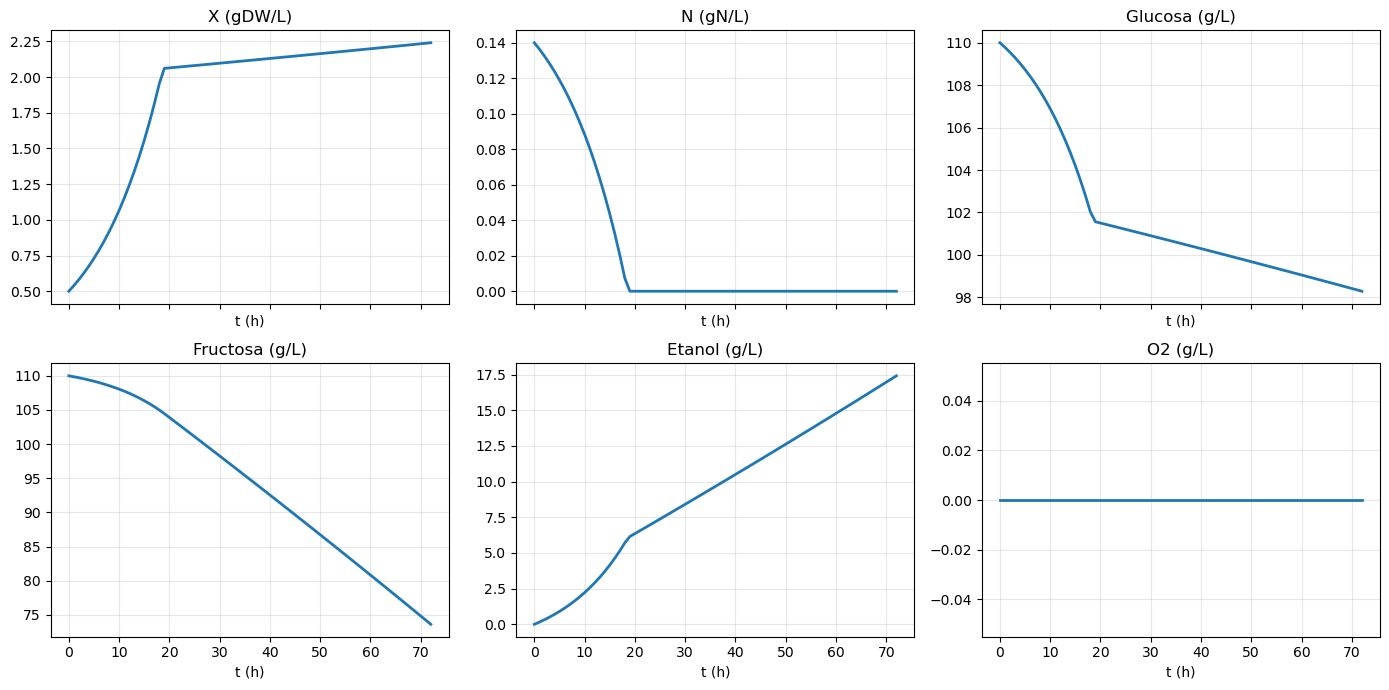

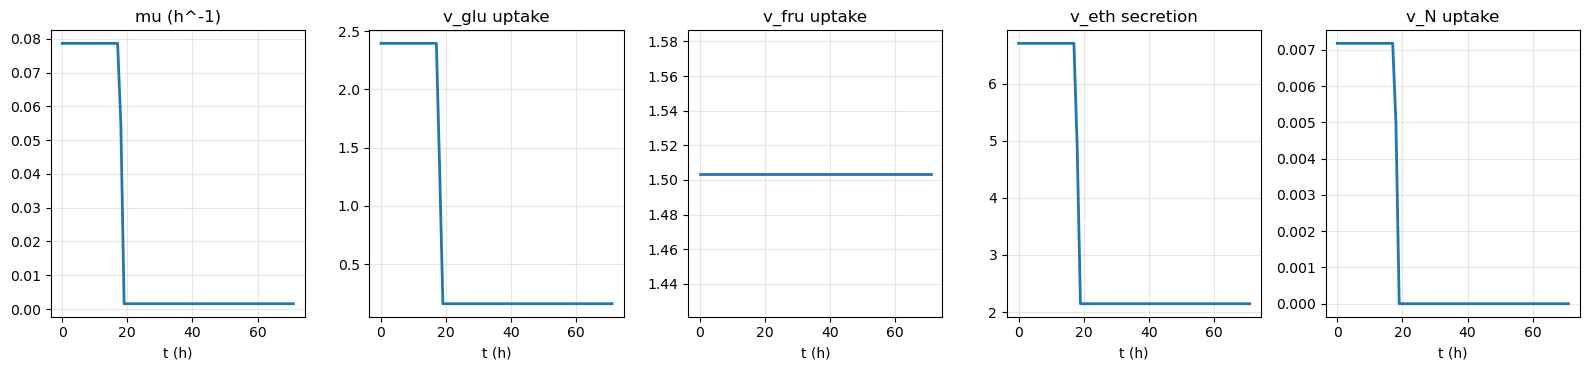

In [9]:
# dFBA con Static Optimization Approach (SOA) usando el modelo actual
import matplotlib.pyplot as plt

print("\n" + "=" * 100)
print("dFBA (SOA) - modelo actual")
print("=" * 100)

# --- Requisitos mínimos ---
required = ["model", "KINETIC_N_SOURCE_IDS", "rxn_by_id"]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(f"Faltan variables en sesión: {missing}")

# IDs clave (usa existentes si ya están definidos)
OBJ_ID = globals().get("OBJ_ID", "r_2111")
GLU_ID = "r_1714"
FRU_ID = "r_1709"
ETH_ID = "r_1761"
O2_ID = "r_1992"

# Pesos moleculares (fallback por si no existen)
MW_GLU = float(globals().get("MW_GLU", 0.180156))
MW_FRU = float(globals().get("MW_FRU", 0.180156))
MW_ETH = float(globals().get("MW_ETH", 0.046070))
MW_N = float(globals().get("MW_N", 0.014007))

# Estado inicial (usa el de tu notebook si ya existe)
X0 = float(globals().get("cX", 0.5))    # gDW/L
N0 = float(globals().get("cN", 0.14))   # gN/L
G0 = float(globals().get("cG", 110.0))  # g/L
F0 = float(globals().get("cF", 110.0))  # g/L
E0 = float(globals().get("cE", 0.0))    # g/L
O20 = float(globals().get("cO2", 0.0))  # g/L

# Horizonte de simulación
DFBA_TH = 72.0   # h
DFBA_DT = 1.0    # h
n_steps = int(round(DFBA_TH / DFBA_DT))
t = np.arange(n_steps + 1, dtype=float) * DFBA_DT

# Límites máximos por biomasa (tomados del snapshot ya calculado en tu notebook)
vmax_glu = float(globals().get("lim_glu", 2.5))
vmax_fru = float(globals().get("lim_fru", 1.5))
vmax_eth = float(globals().get("lim_eth", 8.0))
lim_n_map_ref = globals().get("lim_n_map", {rid: 0.02 for rid in KINETIC_N_SOURCE_IDS})

# Mapa de N-atoms (usa el existente si está en memoria)
N_atoms_map_local = globals().get("N_atoms_map", {rid: 1.0 for rid in KINETIC_N_SOURCE_IDS})

# Fracción por fuente de N (normalizada desde lim_n_map_ref)
sum_ref_n = max(sum(float(lim_n_map_ref.get(rid, 0.0)) for rid in KINETIC_N_SOURCE_IDS), 1e-12)
n_share = {rid: float(lim_n_map_ref.get(rid, 0.0)) / sum_ref_n for rid in KINETIC_N_SOURCE_IDS}

# Historial de estados
Y = np.zeros((n_steps + 1, 6), dtype=float)  # X, N, G, F, E, O2
Y[0, :] = [X0, N0, G0, F0, E0, O20]

# Historial de flujos (por biomasa)
mu_hist = np.zeros(n_steps)
vglu_hist = np.zeros(n_steps)
vfru_hist = np.zeros(n_steps)
veth_hist = np.zeros(n_steps)
vn_hist = np.zeros(n_steps)
status_hist = []

def max_uptake_by_availability(c_sub, X, MW_sub, dt):
    if X <= 1e-12:
        return 0.0
    # v_max para no consumir más de lo disponible en el paso
    return max(0.0, c_sub / (MW_sub * X * dt))

for k in range(n_steps):
    X, N, G, F, E, O2 = np.maximum(Y[k, :], 0.0)

    # Capacidad por disponibilidad del medio
    cap_glu = min(vmax_glu, max_uptake_by_availability(G, X, MW_GLU, DFBA_DT))
    cap_fru = min(vmax_fru, max_uptake_by_availability(F, X, MW_FRU, DFBA_DT))

    # Límite total de N por disponibilidad del pool N
    cap_n_total = 0.0
    if X > 1e-12:
        cap_n_total = max(0.0, N / (MW_N * X * DFBA_DT))

    with model as m:
        rb = {r.id: r for r in m.reactions}

        # Azúcares
        if GLU_ID in rb:
            rb[GLU_ID].lower_bound = max(float(rb[GLU_ID].lower_bound), -cap_glu)
            rb[GLU_ID].upper_bound = min(float(rb[GLU_ID].upper_bound), 0.0)
        if FRU_ID in rb:
            rb[FRU_ID].lower_bound = max(float(rb[FRU_ID].lower_bound), -cap_fru)
            rb[FRU_ID].upper_bound = min(float(rb[FRU_ID].upper_bound), 0.0)

        # N cinético por fuente (distribuido por shares)
        for rid in KINETIC_N_SOURCE_IDS:
            if rid in rb:
                cap_i = cap_n_total * n_share.get(rid, 0.0)
                rb[rid].lower_bound = max(float(rb[rid].lower_bound), -cap_i)
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        # Anaerobiosis fija
        if O2_ID in rb:
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        # Etileno/etanol solo excreción (mantén según tu setup)
        if ETH_ID in rb:
            rb[ETH_ID].upper_bound = min(float(rb[ETH_ID].upper_bound), max(float(rb[ETH_ID].upper_bound), vmax_eth))

        m.objective = OBJ_ID
        m.objective_direction = "max"
        sol = m.optimize()
        status_hist.append(sol.status)

        if sol.status != "optimal":
            # Si no hay óptimo, estado congelado en ese paso
            Y[k + 1, :] = Y[k, :]
            continue

        v_obj = float(sol.fluxes.get(OBJ_ID, 0.0))
        v_glu = float(sol.fluxes.get(GLU_ID, 0.0))
        v_fru = float(sol.fluxes.get(FRU_ID, 0.0))
        v_eth = float(sol.fluxes.get(ETH_ID, 0.0))

        # N uptake efectivo (gN/gDW/h)
        vn_eff = 0.0
        for rid in KINETIC_N_SOURCE_IDS:
            vi = float(sol.fluxes.get(rid, 0.0))
            n_atoms = float(N_atoms_map_local.get(rid, 0.0))
            vn_eff += max(0.0, -vi) * n_atoms * MW_N

    # Guardar flujos
    mu_hist[k] = max(0.0, v_obj)
    vglu_hist[k] = max(0.0, -v_glu)
    vfru_hist[k] = max(0.0, -v_fru)
    veth_hist[k] = max(0.0, v_eth)
    vn_hist[k] = max(0.0, vn_eff)

    # SOA-Euler
    dX = v_obj * X
    dN = -vn_eff * X
    dG = -MW_GLU * max(0.0, -v_glu) * X
    dF = -MW_FRU * max(0.0, -v_fru) * X
    dE =  MW_ETH * max(0.0,  v_eth) * X
    dO2 = 0.0

    Y[k + 1, 0] = max(0.0, X + DFBA_DT * dX)
    Y[k + 1, 1] = max(0.0, N + DFBA_DT * dN)
    Y[k + 1, 2] = max(0.0, G + DFBA_DT * dG)
    Y[k + 1, 3] = max(0.0, F + DFBA_DT * dF)
    Y[k + 1, 4] = max(0.0, E + DFBA_DT * dE)
    Y[k + 1, 5] = max(0.0, O2 + DFBA_DT * dO2)

# --- Resultados ---
X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist = Y.T

print(f"Estado final: X={X_hist[-1]:.4f}, N={N_hist[-1]:.4f}, G={G_hist[-1]:.4f}, F={F_hist[-1]:.4f}, E={E_hist[-1]:.4f}")
print(f"Pasos óptimos: {sum(s=='optimal' for s in status_hist)}/{len(status_hist)}")

# Guardar CSV
out_dfba = OUT_DIR / "dfba_soa_states_cell9.csv"
arr = np.column_stack([t, X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist])
np.savetxt(out_dfba, arr, delimiter=",", header="t_h,X_gDW_L,N_gN_L,G_g_L,F_g_L,E_g_L,O2_g_L", comments="")
print(f"Archivo guardado: {out_dfba}")

# --- Gráficos ---
fig, ax = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
series = [
    (X_hist, "X (gDW/L)"),
    (N_hist, "N (gN/L)"),
    (G_hist, "Glucosa (g/L)"),
    (F_hist, "Fructosa (g/L)"),
    (E_hist, "Etanol (g/L)"),
    (O2_hist, "O2 (g/L)"),
]
for a, (yy, title) in zip(ax.ravel(), series):
    a.plot(t, yy, lw=2)
    a.set_title(title)
    a.grid(alpha=0.3)
    a.set_xlabel("t (h)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 5, figsize=(16, 3.8), sharex=True)
flux_series = [
    (mu_hist, "mu (h^-1)"),
    (vglu_hist, "v_glu uptake"),
    (vfru_hist, "v_fru uptake"),
    (veth_hist, "v_eth secretion"),
    (vn_hist, "v_N uptake"),
]
tt = t[:-1]
for a, (yy, title) in zip(ax, flux_series):
    a.plot(tt, yy, lw=2)
    a.set_title(title)
    a.grid(alpha=0.3)
    a.set_xlabel("t (h)")
plt.tight_layout()
plt.show()

In [10]:
# Diagnóstico específico: etanol=0, sumideros alternativos y experimento etanol forzado
print("\n" + "=" * 100)
print("Diagnóstico dirigido: competencia redox/carbono y desbloqueo de etanol")
print("=" * 100)

OBJ_ID = "r_2111"
ETH_ID = "r_1761"
ATPM_ID = "r_4046"

if OBJ_ID not in rxn_by_id or ETH_ID not in rxn_by_id:
    raise RuntimeError("Faltan r_2111 o r_1761 en el modelo")

# Exchanges estructurales no plausibles como válvula de carbono
LEAK_CLOSE_IDS = {
    "r_4501": "turanose exchange",
    "r_1650": "trehalose exchange",
    "r_4502": "D-glucose 6-phosphate exchange",
    "r_4538": "6-phospho-D-gluconate exchange",
}

# Sumideros alternativos sospechosos (ajuste fisiológico)
ALT_SINK_CAPS = {
    "r_1549": 0.5,  # (R,R)-2,3-butanodiol exchange
    "r_4659": 0.1,  # propanol exchange
    "r_4731": 0.1,  # diethyl-succinate exchange
    "r_4737": 0.1,  # ethyl-pyruvate exchange
    "r_1989": 0.0,  # oxaloacetate exchange (no excreción)
}

# Cierre de excreción de esteroles (permitiendo uptake si aplica)
STEROL_KEYWORDS = ("sterol", "ergosterol", "lanosterol", "zymosterol", "fecosterol", "episterol")
ETH_FORCED_MIN = 1.0
ATPM_STRESS_LB = 1.2

# 1) Referencia: máximo crecimiento sin forzar etanol
with model as m:
    m.objective = OBJ_ID
    m.objective_direction = "max"
    sol_ref_mu = m.optimize()

if sol_ref_mu.status != "optimal":
    raise RuntimeError("No se obtuvo solución óptima de referencia para biomasa")

mu_star = float(sol_ref_mu.objective_value)
v_eth_ref = float(sol_ref_mu.fluxes.get(ETH_ID, np.nan))
print(f"Referencia (sin forzar etanol): mu*={mu_star:.6g}, v_eth={v_eth_ref:.6g}")

def _carbon_atoms(formula):
    if not formula:
        return 0
    import re
    mm = re.search(r"C(?![a-z])(\d*)", formula)
    if not mm:
        return 0
    g = mm.group(1)
    return 1 if g == "" else int(g)

def _apply_leak_closure(m):
    ids = {r.id for r in m.reactions}
    for rid in LEAK_CLOSE_IDS:
        if rid in ids:
            rr = m.reactions.get_by_id(rid)
            rr.lower_bound = 0.0
            rr.upper_bound = 0.0

def _apply_alt_sink_caps(m):
    ids = {r.id for r in m.reactions}
    for rid, ub_cap in ALT_SINK_CAPS.items():
        if rid in ids:
            rr = m.reactions.get_by_id(rid)
            rr.lower_bound = max(0.0, float(rr.lower_bound))
            rr.upper_bound = min(float(rr.upper_bound), float(ub_cap))

def _close_sterol_excretion(m):
    touched = []
    for ex in m.exchanges:
        txt = f"{ex.id} {(ex.name or '')}".lower()
        if any(k in txt for k in STEROL_KEYWORDS):
            old_ub = float(ex.upper_bound)
            ex.upper_bound = min(float(ex.upper_bound), 0.0)
            touched.append((ex.id, ex.name, old_ub, float(ex.upper_bound)))
    return touched

def _solve_case(*, eth_fixed_zero=False, close_leaks=False, cap_alt_sinks=False, close_sterol=False, atpm_lb=None, eth_forced_min=None):
    with model as m:
        ids = {r.id for r in m.reactions}

        if close_leaks:
            _apply_leak_closure(m)

        if cap_alt_sinks:
            _apply_alt_sink_caps(m)

        sterol_touched = []
        if close_sterol:
            sterol_touched = _close_sterol_excretion(m)

        if atpm_lb is not None and ATPM_ID in ids:
            r_atpm = m.reactions.get_by_id(ATPM_ID)
            atpm_lb_val = float(atpm_lb)
            r_atpm.upper_bound = max(float(r_atpm.upper_bound), atpm_lb_val)
            r_atpm.lower_bound = max(float(r_atpm.lower_bound), atpm_lb_val)
        r_eth = m.reactions.get_by_id(ETH_ID)
        if eth_fixed_zero:
            r_eth.lower_bound = 0.0
            r_eth.upper_bound = 0.0
        if eth_forced_min is not None:
            r_eth.lower_bound = max(float(r_eth.lower_bound), float(eth_forced_min))
        m.objective = OBJ_ID
        m.objective_direction = "max"
        sol = m.optimize()
    return sol, sterol_touched

# 2) Casos comparativos
sol_A, ster_A = _solve_case(eth_fixed_zero=True, close_leaks=False, cap_alt_sinks=False, close_sterol=False)
sol_B, ster_B = _solve_case(eth_fixed_zero=True, close_leaks=True,  cap_alt_sinks=False, close_sterol=True)
sol_C, ster_C = _solve_case(eth_fixed_zero=True, close_leaks=True,  cap_alt_sinks=True,  close_sterol=True)

# Sensibilidad ATPM en caso curado + caps
sol_D, ster_D = _solve_case(
    eth_fixed_zero=True,
    close_leaks=True,
    cap_alt_sinks=True,
    close_sterol=True,
    atpm_lb=ATPM_STRESS_LB,
    eth_forced_min=None,
)

# Experimento de desbloqueo: forzar etanol mínimo
sol_E, ster_E = _solve_case(
    eth_fixed_zero=False,
    close_leaks=True,
    cap_alt_sinks=True,
    close_sterol=True,
    atpm_lb=None,
    eth_forced_min=ETH_FORCED_MIN,
)

def _report_case(title, sol_case, sterol_touched):
    print("\n" + "-" * 100)
    print(title)
    print("-" * 100)
    print(f"Esterol exchanges con excreción cerrada: {len(sterol_touched)}")

    if sol_case.status != "optimal":
        print(f"status: {sol_case.status} (sin óptimo)")
        return

    mu_case = float(sol_case.objective_value)
    v_eth = float(sol_case.fluxes.get(ETH_ID, np.nan))
    v_glu = float(sol_case.fluxes.get("r_1714", np.nan)) if "r_1714" in rxn_by_id else np.nan
    v_fru = float(sol_case.fluxes.get("r_1709", np.nan)) if "r_1709" in rxn_by_id else np.nan
    drop_pct = 100.0 * (mu_star - mu_case) / max(mu_star, 1e-12)
    print(f"mu={mu_case:.6g}, v_eth={v_eth:.6g}, caída biomasa={drop_pct:.4f}%")
    print(f"azúcares: v_glu={v_glu:.6g}, v_fru={v_fru:.6g}")

    try:
        rc_eth = float(sol_case.reduced_costs.get(ETH_ID, np.nan))
        print(f"costo reducido r_1761={rc_eth:.6g}")
        if np.isfinite(rc_eth):
            if abs(rc_eth) < 1e-6:
                print("Interpretación RC: presión prácticamente nula por abrir etanol.")
            elif abs(rc_eth) < 1e-2:
                print("Interpretación RC: presión débil por abrir etanol.")
            else:
                print("Interpretación RC: presión relevante por abrir etanol.")
    except Exception:
        pass

    # Exchanges de carbono más activos
    carb_rows = []

    for ex in model.exchanges:
        rid = ex.id
        v = float(sol_case.fluxes.get(rid, 0.0))
        met = next(iter(ex.metabolites.keys()))
        c_atoms = _carbon_atoms(getattr(met, "formula", ""))
        if c_atoms > 0 and abs(v) > 1e-8:
            carb_rows.append((rid, ex.name, v, c_atoms, abs(v) * c_atoms))

    carb_rows.sort(key=lambda x: x[4], reverse=True)
    print("Top exchanges de carbono activos:")

    for rid, name, v, c_atoms, cscore in carb_rows[:12]:
        direction = "uptake" if v < 0 else "secretion"
        print(f"- {name:36s} ({rid}) | v={v: .6g} | C={c_atoms:2d} | {direction:9s} | C*|v|={cscore: .6g}")

    # Flujos clave sospechosos

    key_ids = [
        "r_1714", "r_1709", "r_1761",
        "r_1549", "r_4659", "r_4731", "r_4737", "r_1989", "r_1808", "r_1672",
        "r_2111", "r_1992", "r_4046",
    ]

    print("Flujos clave:")
    for rid in key_ids:
        if rid in rxn_by_id:
            name = rxn_by_id[rid].name
            vv = float(sol_case.fluxes.get(rid, np.nan))
            print(f"- {name:36s} ({rid}) | v={vv: .6g}")

_report_case("Caso A: etanol=0 (sin cerrar leaks)", sol_A, ster_A)
_report_case("Caso B: etanol=0 + cierre de leaks + sin excreción de esteroles", sol_B, ster_B)
_report_case("Caso C: Caso B + caps de sumideros exóticos", sol_C, ster_C)
_report_case("Caso D: Caso C + ATPM más exigente", sol_D, ster_D)
_report_case(f"Caso E: Caso C + etanol forzado (v_eth >= {ETH_FORCED_MIN})", sol_E, ster_E)

print("\nLectura rápida:")
print("- Se restringieron r_4731/r_4737 y se cerró r_1989 para excreción.")
print("- También se cerró excreción de exchanges con nombre de esterol (ub<=0).")
print("- Si E (etanol forzado) derrumba μ o vuelve inviable, revisar estequiometría ADH/transporte de etanol y cofactores del medio.")


Diagnóstico dirigido: competencia redox/carbono y desbloqueo de etanol
Referencia (sin forzar etanol): mu*=0.0786662, v_eth=6.76652


c:\Users\ctorrealba\AppData\Local\anaconda3\envs\Data_Science\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)



----------------------------------------------------------------------------------------------------
Caso A: etanol=0 (sin cerrar leaks)
----------------------------------------------------------------------------------------------------
Esterol exchanges con excreción cerrada: 0
mu=0.0375449, v_eth=0, caída biomasa=52.2732%
azúcares: v_glu=-2.92775, v_fru=-1.5037
costo reducido r_1761=0.0149897
Interpretación RC: presión relevante por abrir etanol.
Top exchanges de carbono activos:
- D-glucose exchange                   (r_1714) | v=-2.92775 | C= 6 | uptake    | C*|v|= 17.5665
- diethyl-succinate exchange           (r_4731) | v= 1.78372 | C= 8 | secretion | C*|v|= 14.2697
- D-fructose exchange                  (r_1709) | v=-1.5037 | C= 6 | uptake    | C*|v|= 9.02218
- (R,R)-2,3-butanediol exchange        (r_1549) | v= 1.60142 | C= 4 | secretion | C*|v|= 6.40568
- carbon dioxide exchange              (r_1672) | v= 5.18133 | C= 1 | secretion | C*|v|= 5.18133
- L-tryptophan exchange    

Ahora seguimos con FBA con Caso C y etanol abierto

In [11]:
# Modelo operativo para simulación: Caso C + etanol liberado (pFBA)
print("\n" + "=" * 100)
print("Construcción del modelo operativo (Caso C + r_1761 abierto, pFBA)")
print("=" * 100)

required_symbols = [
    "model", "OBJ_ID", "ETH_ID", "ATPM_ID", "KINETIC_N_SOURCE_IDS",
    "_apply_leak_closure", "_apply_alt_sink_caps", "_close_sterol_excretion",
    "rxn_by_id",
]
missing_symbols = [s for s in required_symbols if s not in globals()]
if missing_symbols:
    raise RuntimeError(f"Faltan símbolos requeridos en sesión: {missing_symbols}")

model_case_c_open_eth = model.copy()

# Aplicar configuración Caso C
_apply_leak_closure(model_case_c_open_eth)
_apply_alt_sink_caps(model_case_c_open_eth)
ster_case_c_open_eth = _close_sterol_excretion(model_case_c_open_eth)

rxn_case = {r.id: r for r in model_case_c_open_eth.reactions}
if ETH_ID not in rxn_case:
    raise RuntimeError(f"No se encontró {ETH_ID} en el modelo de trabajo")

# Liberar intercambio de etanol (uptake y excreción)
rxn_case[ETH_ID].lower_bound = 0.0
rxn_case[ETH_ID].upper_bound = 1000.0

# Exigir mayor mantenimiento (ATPM fijo)
ATPM_CASE_C = 0.7
if ATPM_ID in rxn_case:
    rxn_case[ATPM_ID].upper_bound = max(float(rxn_case[ATPM_ID].upper_bound), ATPM_CASE_C)
    rxn_case[ATPM_ID].lower_bound = ATPM_CASE_C
    rxn_case[ATPM_ID].upper_bound = ATPM_CASE_C
else:
    print(f"[WARN] No se encontró {ATPM_ID}; no se ajustó ATPM")

# Resolver pFBA con objetivo de biomasa
model_case_c_open_eth.objective = OBJ_ID
model_case_c_open_eth.objective_direction = "max"
sol_case_c_open_eth = cobra.flux_analysis.pfba(model_case_c_open_eth, fraction_of_optimum=1.0)

mu_case = float(sol_case_c_open_eth.fluxes.get(OBJ_ID, np.nan)) if OBJ_ID in rxn_case else np.nan

print(f"Esterol exchanges con excreción cerrada: {len(ster_case_c_open_eth)}")
print(f"Bounds etanol {ETH_ID}: lb={rxn_case[ETH_ID].lower_bound:.3f}, ub={rxn_case[ETH_ID].upper_bound:.3f}")
if ATPM_ID in rxn_case:
    print(f"Bounds ATPM {ATPM_ID}: lb={rxn_case[ATPM_ID].lower_bound:.3f}, ub={rxn_case[ATPM_ID].upper_bound:.3f}")
print(f"pFBA status: {sol_case_c_open_eth.status}")
print(f"Crecimiento (flujo {OBJ_ID}) en pFBA: {mu_case:.6g}")
print(f"Objetivo interno pFBA (min suma de flujos): {sol_case_c_open_eth.objective_value:.6g}")

print("\nFlujos clave (Caso C + etanol abierto, pFBA):")
for label, rid in [
    ("Biomasa", "r_2111"),
    ("Uptake glucosa", "r_1714"),
    ("Uptake fructosa", "r_1709"),
    ("Intercambio etanol", "r_1761"),
    ("Intercambio O2", "r_1992"),
    ("Mantenimiento ATP", "r_4046"),
]:
    if rid in rxn_case:
        v = float(sol_case_c_open_eth.fluxes.get(rid, np.nan))
        print(f"- {label:20s} ({rid}) | {rxn_case[rid].name} | v={v: .6g} | bounds=[{rxn_case[rid].lower_bound: .6g}, {rxn_case[rid].upper_bound: .6g}]")
    else:
        print(f"- {label:20s} ({rid}) | MISSING")

# FVA dirigido, análogo a celdas anteriores
print("\n" + "=" * 100)
print("FVA @99% (Caso C + etanol abierto)")
print("=" * 100)

fva_ids_case_c_open_eth = ["r_2111", "r_1714", "r_1709", "r_1761", "r_1992", "r_4046"] + KINETIC_N_SOURCE_IDS
fva_ids_case_c_open_eth = [rid for rid in fva_ids_case_c_open_eth if rid in rxn_case]

fva_case_c_open_eth_df = cobra.flux_analysis.flux_variability_analysis(
    model_case_c_open_eth,
    reaction_list=fva_ids_case_c_open_eth,
    fraction_of_optimum=0.99,
)

for rid in fva_ids_case_c_open_eth:
    mn = float(fva_case_c_open_eth_df.loc[rid, "minimum"])
    mx = float(fva_case_c_open_eth_df.loc[rid, "maximum"])
    print(f"- {rxn_case[rid].name:40s} ({rid}) | min={mn: .6g}  max={mx: .6g}")

# pFVA (FVA parsimonioso)
print("\n" + "=" * 100)
print("pFVA @99% (pfba_factor=1.0)")
print("=" * 100)

pfva_case_c_open_eth_df = None
try:
    pfva_case_c_open_eth_df = cobra.flux_analysis.flux_variability_analysis(
        model_case_c_open_eth,
        reaction_list=fva_ids_case_c_open_eth,
        fraction_of_optimum=0.99,
        pfba_factor=1.0,
    )

    for rid in fva_ids_case_c_open_eth:
        mn = float(pfva_case_c_open_eth_df.loc[rid, "minimum"])
        mx = float(pfva_case_c_open_eth_df.loc[rid, "maximum"])
        print(f"- {rxn_case[rid].name:40s} ({rid}) | min={mn: .6g}  max={mx: .6g}")
except TypeError:
    print("[WARN] La versión actual de COBRApy no soporta 'pfba_factor' en flux_variability_analysis.")
    print("       pFVA no fue calculado.")

print("\nVariables guardadas:")
print("- model_case_c_open_eth")
print("- sol_case_c_open_eth")
print("- fva_case_c_open_eth_df")
print("- pfva_case_c_open_eth_df")


Construcción del modelo operativo (Caso C + r_1761 abierto, pFBA)
Esterol exchanges con excreción cerrada: 6
Bounds etanol r_1761: lb=0.000, ub=1000.000
Bounds ATPM r_4046: lb=0.700, ub=0.700
pFBA status: optimal
Crecimiento (flujo r_2111) en pFBA: 0.0786662
Objetivo interno pFBA (min suma de flujos): 115.65

Flujos clave (Caso C + etanol abierto, pFBA):
- Biomasa              (r_2111) | growth | v= 0.0786662 | bounds=[ 0,  1000]
- Uptake glucosa       (r_1714) | D-glucose exchange | v=-2.39755 | bounds=[-2.92775,  0]
- Uptake fructosa      (r_1709) | D-fructose exchange | v=-1.5037 | bounds=[-1.5037,  0]
- Intercambio etanol   (r_1761) | ethanol exchange | v= 6.66308 | bounds=[ 0,  1000]
- Intercambio O2       (r_1992) | oxygen exchange | v= 0 | bounds=[ 0,  0]
- Mantenimiento ATP    (r_4046) | non-growth associated maintenance reaction | v= 0.7 | bounds=[ 0.7,  0.7]

FVA @99% (Caso C + etanol abierto)
- growth                                   (r_2111) | min= 0.0778795  max= 0.07866

In [12]:
# Diagnóstico extendido de fuentes de carbono (Caso C + etanol abierto)
print("\n" + "=" * 100)
print("Diagnóstico extendido: ¿por dónde entra carbono en la solución FBA?")
print("=" * 100)

if "model_case_c_open_eth" not in globals() or "sol_case_c_open_eth" not in globals():
    raise RuntimeError("Primero ejecuta la celda de Caso C + etanol abierto")

m_diag = model_case_c_open_eth
sol_diag = sol_case_c_open_eth
rxn_diag = {r.id: r for r in m_diag.reactions}

def _carbon_atoms_from_formula(formula):
    if not formula:
        return 0
    import re
    mm = re.search(r"C(?![a-z])(\d*)", str(formula))
    if not mm:
        return 0
    g = mm.group(1)
    return 1 if g == "" else int(g)

exchange_ids = {r.id for r in m_diag.exchanges}
sink_ids = {r.id for r in m_diag.sinks}
demand_ids = {r.id for r in m_diag.demands}
boundary_ids = exchange_ids | sink_ids | demand_ids

# 1) Medium actual: qué exchanges están habilitados para uptake
print("\n[1] Exchanges con uptake habilitado en medium (bound > 0):")
medium_map = m_diag.medium
medium_open = sorted(medium_map.items(), key=lambda kv: kv[1], reverse=True)
if not medium_open:
    print("- No hay exchanges con uptake habilitado en medium.")
else:
    for rid, ub_up in medium_open[:30]:
        if rid in rxn_diag:
            r = rxn_diag[rid]
            met = next(iter(r.metabolites.keys())) if r.metabolites else None
            c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", "")) if met is not None else 0
            print(f"- {r.name:40s} ({rid}) | medium_bound={ub_up: .6g} | C_atoms={c_atoms}")

# 2) Uptakes de carbono realmente activos en la solución óptima
print("\n[2] Uptakes de carbono activos (exchanges con v < 0):")
carbon_uptake_rows = []
for rid in exchange_ids:
    v = float(sol_diag.fluxes.get(rid, 0.0))
    if v >= -1e-9:
        continue
    r = rxn_diag[rid]
    if not r.metabolites:
        continue
    met = next(iter(r.metabolites.keys()))
    c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", ""))
    if c_atoms <= 0:
        continue
    c_score = (-v) * c_atoms
    carbon_uptake_rows.append((rid, r.name, met.id, getattr(met, "formula", ""), v, c_atoms, c_score, r.lower_bound, r.upper_bound))

carbon_uptake_rows.sort(key=lambda x: x[6], reverse=True)
if not carbon_uptake_rows:
    print("- No hay uptake de compuestos con carbono en el óptimo.")
else:
    total_c = sum(x[6] for x in carbon_uptake_rows)
    print(f"Total C*|v| (uptake activo) = {total_c:.6g}")
    for rid, name, mid, formula, v, c_atoms, c_score, lb, ub in carbon_uptake_rows[:20]:
        print(f"- {name:36s} ({rid}) | met={mid:12s} formula={str(formula):10s} | v={v: .6g} | C={c_atoms:2d} | C*|v|={c_score: .6g} | bounds=[{lb: .6g}, {ub: .6g}]")

# 3) Reacciones de frontera activas con carbono (incluye sink/demand)
print("\n[3] Reacciones de frontera activas con metabolitos carbonados (|v|>1e-9):")
boundary_carbon_rows = []
for rid in boundary_ids:
    v = float(sol_diag.fluxes.get(rid, 0.0))
    if abs(v) <= 1e-9:
        continue
    r = rxn_diag[rid]
    if not r.metabolites:
        continue
    met = next(iter(r.metabolites.keys()))
    c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", ""))
    if c_atoms <= 0:
        continue
    rtype = "exchange" if rid in exchange_ids else ("sink" if rid in sink_ids else "demand")
    boundary_carbon_rows.append((rid, r.name, rtype, met.id, getattr(met, "formula", ""), v, c_atoms, abs(v) * c_atoms, r.lower_bound, r.upper_bound))

boundary_carbon_rows.sort(key=lambda x: x[7], reverse=True)
if not boundary_carbon_rows:
    print("- No se detectaron fronteras activas con carbono.")
else:
    for rid, name, rtype, mid, formula, v, c_atoms, cscore, lb, ub in boundary_carbon_rows[:30]:
        direction = "uptake" if v < 0 else "secretion"
        print(f"- [{rtype:8s}] {name:30s} ({rid}) | met={mid:12s} formula={str(formula):10s} | v={v: .6g} ({direction}) | C={c_atoms:2d} | C*|v|={cscore: .6g} | bounds=[{lb: .6g}, {ub: .6g}]")

# 4) FVA sobre TODOS los exchanges carbonados para detectar vías alternativas
print("\n[4] FVA @99% en exchanges carbonados (potenciales uptakes alternativos)")
carbon_exchange_ids = []
for ex in m_diag.exchanges:
    if not ex.metabolites:
        continue
    met = next(iter(ex.metabolites.keys()))
    c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", ""))
    if c_atoms > 0:
        carbon_exchange_ids.append(ex.id)

if not carbon_exchange_ids:
    print("- No se encontraron exchanges carbonados para analizar.")
else:
    fva_carbon_ex = cobra.flux_analysis.flux_variability_analysis(
        m_diag,
        reaction_list=carbon_exchange_ids,
        fraction_of_optimum=0.99,
    )

    possible_c_uptake = []
    for rid in carbon_exchange_ids:
        mn = float(fva_carbon_ex.loc[rid, "minimum"])
        mx = float(fva_carbon_ex.loc[rid, "maximum"])
        if mn < -1e-9:
            r = rxn_diag[rid]
            met = next(iter(r.metabolites.keys()))
            c_atoms = _carbon_atoms_from_formula(getattr(met, "formula", ""))
            possible_c_uptake.append((rid, r.name, met.id, getattr(met, "formula", ""), mn, mx, c_atoms, r.lower_bound, r.upper_bound))

    possible_c_uptake.sort(key=lambda x: x[4])
    if not possible_c_uptake:
        print("- Ningún exchange carbonado puede tomar flujo negativo al 99% del óptimo.")
    else:
        print("Exchanges carbonados con uptake posible (min < 0):")
        for rid, name, mid, formula, mn, mx, c_atoms, lb, ub in possible_c_uptake[:40]:
            print(f"- {name:36s} ({rid}) | met={mid:12s} formula={str(formula):10s} | FVA[min,max]=[{mn: .6g}, {mx: .6g}] | C={c_atoms:2d} | bounds=[{lb: .6g}, {ub: .6g}]")

# 5) Lectura dirigida para tu caso
print("\n[5] Lectura dirigida:")
v_glu = float(sol_diag.fluxes.get("r_1714", np.nan)) if "r_1714" in rxn_diag else np.nan
v_fru = float(sol_diag.fluxes.get("r_1709", np.nan)) if "r_1709" in rxn_diag else np.nan
print(f"- Glucosa (r_1714): v={v_glu: .6g}")
print(f"- Fructosa (r_1709): v={v_fru: .6g}")
print("- Si glucosa queda en 0 y fructosa < 0, el óptimo actual prioriza fructosa dadas las restricciones vigentes.")
print("- Revisa en [2] y [4] si hay otros exchanges carbonados con uptake activo o factible (min<0).")


Diagnóstico extendido: ¿por dónde entra carbono en la solución FBA?

[1] Exchanges con uptake habilitado en medium (bound > 0):
- ergosterol exchange                      (r_1757) | medium_bound= 1000 | C_atoms=28
- H+ exchange                              (r_1832) | medium_bound= 1000 | C_atoms=0
- lanosterol exchange                      (r_1915) | medium_bound= 1000 | C_atoms=30
- palmitoleate exchange                    (r_1994) | medium_bound= 1000 | C_atoms=16
- phosphate exchange                       (r_2005) | medium_bound= 1000 | C_atoms=0
- sodium exchange                          (r_2049) | medium_bound= 1000 | C_atoms=0
- sulphate exchange                        (r_2060) | medium_bound= 1000 | C_atoms=0
- water exchange                           (r_2100) | medium_bound= 1000 | C_atoms=0
- zymosterol exchange                      (r_2106) | medium_bound= 1000 | C_atoms=27
- 14-demethyllanosterol exchange           (r_2134) | medium_bound= 1000 | C_atoms=29
- ergosta-5,7,22

In [13]:
# Sensibilidad dual (precios sombra y costos reducidos)
print("\n" + "=" * 100)
print("Analisis de sensibilidad dual (COBRA)")
print("=" * 100)

# Reusar solucion vigente; si no existe, optimizar
sol_dual = solution_nb2 if 'solution_nb2' in globals() else model.optimize()
print(f"status: {sol_dual.status}")
print(f"objective: {sol_dual.objective_value:.6g}")

if sol_dual.status != "optimal":
    print("[WARN] Solucion no optima: precios sombra/costos reducidos pueden ser poco confiables.")

# 1) Precios sombra de metabolitos (dual de balance S*v = 0)
shadow = sol_dual.shadow_prices.copy()
shadow = shadow.replace([np.inf, -np.inf], np.nan).dropna()
shadow_nz = shadow[shadow.abs() > 1e-9]
shadow_top = shadow_nz.reindex(shadow_nz.abs().sort_values(ascending=False).index)

print("\nTop metabolitos por |precio sombra| (abs):")
if shadow_top.empty:
    print("- No hay precios sombra significativos sobre el umbral.")
else:
    for mid, sp in shadow_top.head(20).items():
        met = model.metabolites.get_by_id(mid)
        comp = getattr(met, "compartment", "?")
        print(f"- {met.name:42s} ({mid}) [comp={comp}] | shadow={sp: .6g}")

print("\nInterpretacion rapida precio sombra:")
print("- |shadow| alto => metabolito mas 'caro' para sostener el objetivo (cuello potencial).")
print("- shadow < 0 suele indicar que aumentar disponibilidad de ese balance favoreceria el objetivo.")
print("- shadow > 0 suele indicar presion en sentido opuesto del balance.")

# 2) Costos reducidos de reacciones (dual de bounds)
reduced = sol_dual.reduced_costs.copy()
reduced = reduced.replace([np.inf, -np.inf], np.nan).dropna()
reduced_nz = reduced[reduced.abs() > 1e-9]
reduced_top = reduced_nz.reindex(reduced_nz.abs().sort_values(ascending=False).index)

print("\nTop reacciones por |costo reducido| (abs):")
if reduced_top.empty:
    print("- No hay costos reducidos significativos sobre el umbral.")
else:
    for rid, rc in reduced_top.head(20).items():
        rxn = model.reactions.get_by_id(rid)
        v = float(sol_dual.fluxes.get(rid, np.nan))
        at_lb = abs(v - rxn.lower_bound) <= 1e-7
        at_ub = abs(v - rxn.upper_bound) <= 1e-7
        where = "LB" if at_lb else ("UB" if at_ub else "interior")
        print(f"- {rxn.name:42s} ({rid}) | rc={rc: .6g} | v={v: .6g} | activo_en={where}")

# 3) Exchanges activos en cota (suelen ser cuellos de entrada/salida)
print("\nExchanges activos en cota (|v-lb|<tol o |v-ub|<tol):")
active_ex = []
for ex in model.exchanges:
    rid = ex.id
    v = float(sol_dual.fluxes.get(rid, 0.0))
    at_lb = abs(v - ex.lower_bound) <= 1e-7
    at_ub = abs(v - ex.upper_bound) <= 1e-7
    if at_lb or at_ub:
        active_ex.append((rid, ex.name, v, ex.lower_bound, ex.upper_bound, "LB" if at_lb else "UB"))

if not active_ex:
    print("- Ningun exchange detectado en cota activa.")
else:
    active_ex.sort(key=lambda x: abs(x[2]), reverse=True)
    for rid, name, v, lb, ub, side in active_ex[:25]:
        print(f"- {name:38s} ({rid}) | v={v: .6g} | [{lb: .6g}, {ub: .6g}] | cota={side}")

# 4) Semaforo: cruza exchange en cota + |reduced cost|
print("\n" + "=" * 100)
print("Semaforo de cuellos (exchange en cota + |costo reducido|)")
print("=" * 100)

def bottleneck_level(abs_rc):
    if abs_rc >= 10:
        return "ALTO"
    if abs_rc >= 1:
        return "MEDIO"
    return "BAJO"

def is_actionable_exchange(side, lb, ub):
    blocked = abs(lb) <= 1e-12 and abs(ub) <= 1e-12
    if blocked:
        return False, "bloqueada"

    # Uptake cap activo (flujo en LB negativo): candidato biologicamente accionable
    if side == "LB" and lb < -1e-9:
        return True, "uptake_cap"

    # Product/secreted cap activo (flujo en UB acotado): accionable si no esta abierto a 1000
    if side == "UB" and ub > 1e-9 and ub < 999.0:
        return True, "secretion_cap"

    # Casos tipicos no accionables: LB=0 en solo-secrecion, UB=1000 en abierto
    return False, "estructural"

rc_map = reduced.abs().to_dict()
cross_all = []
cross_actionable = []
for rid, name, v, lb, ub, side in active_ex:
    abs_rc = float(rc_map.get(rid, 0.0))
    if abs_rc <= 1e-9:
        continue

    ok, kind = is_actionable_exchange(side, lb, ub)
    row = (abs_rc, rid, name, side, v, lb, ub, bottleneck_level(abs_rc), kind)
    cross_all.append(row)
    if ok:
        cross_actionable.append(row)

if not cross_all:
    print("- No se detectaron exchanges en cota con costo reducido relevante.")
else:
    cross_all.sort(reverse=True, key=lambda x: x[0])
    cross_actionable.sort(reverse=True, key=lambda x: x[0])

    if cross_actionable:
        print("Top 5 cuellos ACCIONABLES:")
        for abs_rc, rid, name, side, v, lb, ub, lvl, kind in cross_actionable[:5]:
            print(f"- [{lvl:5s}] {name:34s} ({rid}) | |rc|={abs_rc: .6g} | cota={side} | v={v: .6g} | [{lb: .6g}, {ub: .6g}] | tipo={kind}")
    else:
        print("- No hay cuellos accionables bajo este filtro (solo estructurales/bloqueados).")

    print("\nTop 5 cuellos GLOBALES (incluye estructurales):")
    for abs_rc, rid, name, side, v, lb, ub, lvl, kind in cross_all[:5]:
        print(f"- [{lvl:5s}] {name:34s} ({rid}) | |rc|={abs_rc: .6g} | cota={side} | v={v: .6g} | [{lb: .6g}, {ub: .6g}] | tipo={kind}")

print("\nSugerencia:")
print("- Prioriza ajustes en cuellos [ALTO] del bloque ACCIONABLE, luego reoptimiza y vuelve a revisar este semaforo.")


Analisis de sensibilidad dual (COBRA)
status: optimal
objective: 0.0786662

Top metabolitos por |precio sombra| (abs):
- P(1),P(4)-bis(5'-adenosyl) tetraphosphate  (s_1282) [comp=c] | shadow=-1.58276
- P(1),P(3)-bis(5'-adenosyl) triphosphate    (s_4317) [comp=c] | shadow=-1.58276
- 5,6,7,8-tetrahydrofolyl-L-glutamic acid    (s_0308) [comp=c] | shadow=-1.26621
- 5-methyltetrahydrofolate                   (s_0322) [comp=c] | shadow=-1.10793
- 5,10-methylenetetrahydrofolate             (s_0306) [comp=c] | shadow=-1.10793
- dihydrofolic acid                          (s_0626) [comp=m] | shadow=-1.10793
- dihydrofolic acid                          (s_0625) [comp=c] | shadow=-1.10793
- THF                                        (s_1487) [comp=c] | shadow=-1.10793
- 5'-S-methyl-5'-thioadenosine               (s_0303) [comp=c] | shadow=-1.10793
- 10-formyl-THF                              (s_0120) [comp=c] | shadow=-1.10793
- 5-formyltetrahydrofolic acid               (s_0319) [comp=c] | shado


dFBA SOA básico con COBRApy (anaeróbico vs aeróbico)
Regla N-depletion: cierre de vitaminas N cuando N <= 1e-06
Exchanges vitaminas-N afectados: ['r_2067', 'r_1671', 'r_1967', 'r_2028', 'r_1548', 'r_2038']

Bloque dFBA: Anaeróbico
Estado final: X=2.0695, N=0.0000, G=60.8021, F=85.3127, E=5.5414, O2=0.000000
O2 inicial: 0.0000 mg/L | Condición anaeróbica fija (r_1992 cerrado)
Archivo guardado: out\dfba_direct_states_anaerobic.csv

Bloque dFBA: Aeróbico (arranque O2=0.8 mg/L)
Estado final: X=2.0695, N=0.0000, G=60.5777, F=85.1882, E=5.3006, O2=0.000000
O2 inicial: 0.8000 mg/L | Transición estimada a anaerobiosis: t≈8.00 h
Archivo guardado: out\dfba_direct_states_aerobic.csv


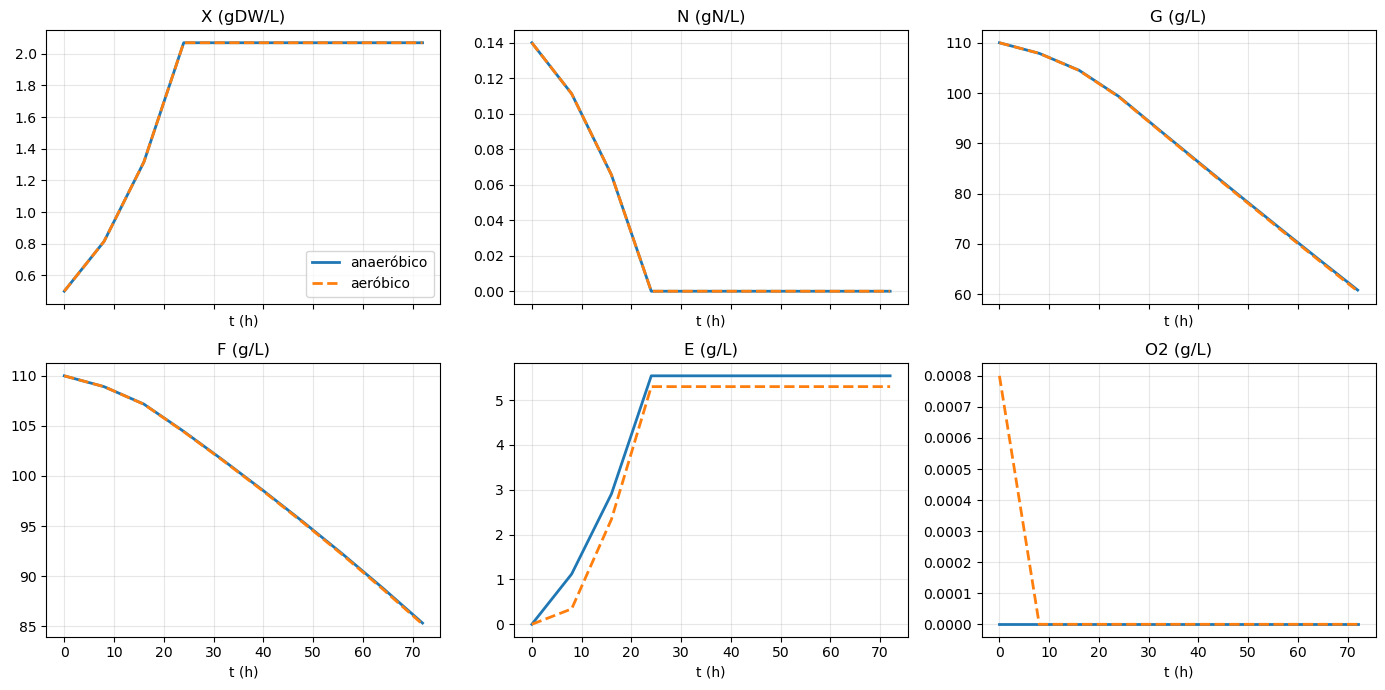

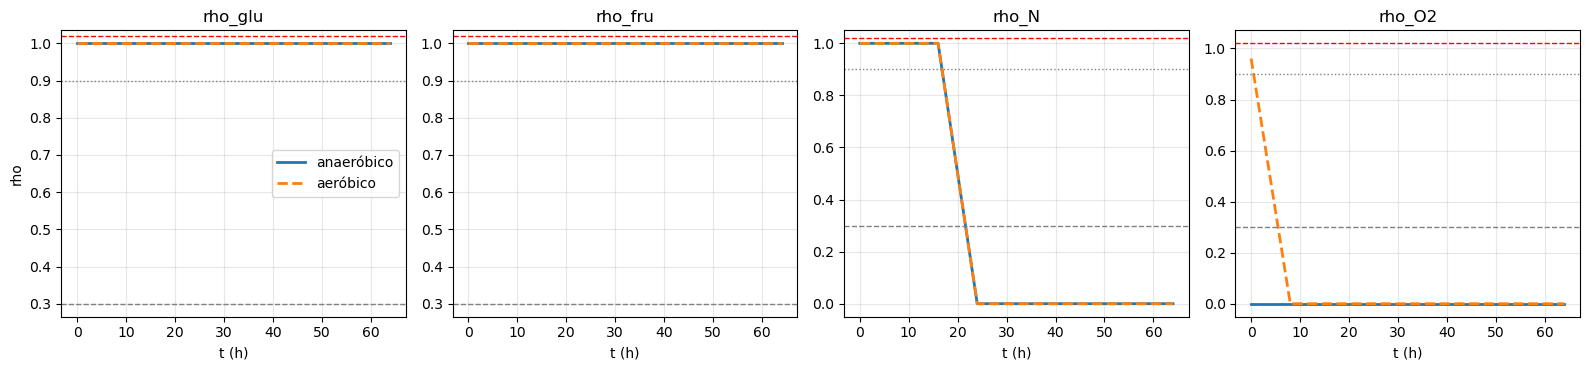

In [14]:
# dFBA SOA básico (dos bloques: anaeróbico y aeróbico)
print("\n" + "=" * 100)
print("dFBA SOA básico con COBRApy (anaeróbico vs aeróbico)")
print("=" * 100)

import matplotlib.pyplot as plt
import re

# Horizonte y paso
DFBA_TH = 72.0
DFBA_DT = 8.0
n_steps = int(round(DFBA_TH / DFBA_DT))
time_grid = np.arange(n_steps + 1, dtype=float) * DFBA_DT

# Escenario aeróbico
O2_INIT_MG_L_AEROBIC = 0.8
O2_INIT_G_L_AEROBIC = O2_INIT_MG_L_AEROBIC / 1000.0
O2_KO_G_L = 0.002
O2_VMAX_UPTAKE = 2.0
O2_DEPLETION_THRESHOLD = 1e-6

# Cierre de uptake nitrogenado al agotarse N
N_DEPLETION_CLOSE_THRESHOLD = 1e-6
VITAMIN_TRACE_IDS = ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"]

def _n_atoms_from_formula(formula):
    if not formula:
        return 0
    mm = re.search(r"N(?![a-z])(\d*)", str(formula))
    if not mm:
        return 0
    gg = mm.group(1)
    return 1 if gg == "" else int(gg)

N_VITAMIN_EX_IDS = []
for rid in VITAMIN_TRACE_IDS:
    if rid in rxn_by_id and rxn_by_id[rid].metabolites:
        met = next(iter(rxn_by_id[rid].metabolites.keys()))
        if _n_atoms_from_formula(getattr(met, "formula", "")) > 0:
            N_VITAMIN_EX_IDS.append(rid)

MW_O2 = 0.031998

# IDs clave
OBJ_ID = "r_2111"
GLU_ID = "r_1714"
FRU_ID = "r_1709"
ETH_ID = "r_1761"
O2_ID = "r_1992"

required_ids = [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID] + KINETIC_N_SOURCE_IDS
missing = [rid for rid in required_ids if rid not in rxn_by_id]
if missing:
    raise RuntimeError(f"Faltan reacciones requeridas para dFBA: {missing}")

base_lb = {rid: float(rxn_by_id[rid].lower_bound) for rid in required_ids}
base_ub = {rid: float(rxn_by_id[rid].upper_bound) for rid in required_ids}

print(f"Regla N-depletion: cierre de vitaminas N cuando N <= {N_DEPLETION_CLOSE_THRESHOLD:g}")
print(f"Exchanges vitaminas-N afectados: {N_VITAMIN_EX_IDS}")

def _kinetic_limits(cX, cN, cG, cF, cE, cO2):
    mu_T  = np.exp(59453.0 * (T_val - 300.0) / (300.0 * R_GAS * T_val))
    Kg_T  = np.exp(46055.0 * (T_val - 293.15) / (293.15 * R_GAS * T_val))
    b_T   = np.exp(11000.0 * (T_val - 296.15) / (296.15 * R_GAS * T_val))
    mrate = MRATE_0 * np.exp(37681.0 * (T_val - 293.30) / (293.30 * R_GAS * T_val))

    mu = MU0_nom * mu_T * (cN / (cN + Kn0_nom * Kg_T + EPS))
    betaG = betaG0_nom * b_T * (cG / (cG + Kg0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))
    betaF = betaF0_nom * b_T * (cF / (cF + Kf0_nom * Kg_T + EPS)) * (Kig0_nom * Kg_T / (cG + Kig0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))

    vx = mu
    vg = mu / YXG_nom + betaG / YEG_nom + mrate * (cG / (cG + cF + EPS))
    vf = mu / YXF_nom + betaF / YEF_nom + mrate * (cF / (cG + cF + EPS))
    vn = mu / YXN_nom
    ve = (betaG + betaF) / MW_ETH

    lim_glu = max(0.0, vg / MW_GLU)
    lim_fru = max(0.0, vf / MW_FRU)
    lim_eth = max(0.0, ve)
    lim_obj = max(0.0, vx)
    lim_n_map = {rid: max(0.0, vn * N_frac_map[rid]) for rid in KINETIC_N_SOURCE_IDS}

    return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map

def _run_dfba_scenario(*, scenario_name, o2_init_g_l, aerobic_mode):
    y0 = np.array([0.5, 0.14, 110.0, 110.0, 0.0, o2_init_g_l], dtype=float)

    def _apply_dynamic_bounds(mtmp, y):
        cX, cN, cG, cF, cE, cO2 = [max(0.0, float(v)) for v in y]
        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits(cX, cN, cG, cF, cE, cO2)

        rb = {r.id: r for r in mtmp.reactions}
        for rid in required_ids:
            rb[rid].lower_bound = base_lb[rid]
            rb[rid].upper_bound = base_ub[rid]

        rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
        rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
        rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
        rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

        for rid in KINETIC_N_SOURCE_IDS:
            Li = float(lim_n_map[rid])
            rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
            rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

        if cN <= N_DEPLETION_CLOSE_THRESHOLD:
            for rid in N_VITAMIN_EX_IDS:
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        if APPLY_PRODUCT_CAPS:
            rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
            rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
        else:
            rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
            rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

        if aerobic_mode:
            lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS))
            lim_o2 = max(0.0, float(lim_o2))
            if cO2 <= O2_DEPLETION_THRESHOLD:
                lim_o2 = 0.0
            rb[O2_ID].lower_bound = -lim_o2
            rb[O2_ID].upper_bound = 0.0
        else:
            lim_o2 = 0.0
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        lim_n_total = sum(lim_n_map[rid] * N_atoms_map[rid] * MW_N for rid in KINETIC_N_SOURCE_IDS)
        return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_total, lim_o2

    Y = np.zeros((n_steps + 1, 6), dtype=float)
    Y[0, :] = y0

    mu_hist = np.zeros(n_steps)
    vglu_hist = np.zeros(n_steps)
    vfru_hist = np.zeros(n_steps)
    veth_hist = np.zeros(n_steps)
    vo2_hist = np.zeros(n_steps)
    vn_eff_hist = np.zeros(n_steps)
    lim_glu_hist = np.zeros(n_steps)
    lim_fru_hist = np.zeros(n_steps)
    lim_n_hist = np.zeros(n_steps)
    lim_o2_hist = np.zeros(n_steps)

    for k in range(n_steps):
        yk = np.maximum(Y[k, :], 0.0)

        with model as mtmp:
            lim_glu, lim_fru, _lim_eth, _lim_obj, lim_n_total, lim_o2 = _apply_dynamic_bounds(mtmp, yk)
            sol = mtmp.optimize()

            if sol.status != "optimal":
                continue

            v_obj = float(sol.fluxes.get(OBJ_ID, 0.0))
            v_glu = float(sol.fluxes.get(GLU_ID, 0.0))
            v_fru = float(sol.fluxes.get(FRU_ID, 0.0))
            v_eth = float(sol.fluxes.get(ETH_ID, 0.0))
            v_o2 = float(sol.fluxes.get(O2_ID, 0.0))

            vn_eff = 0.0
            for rid in KINETIC_N_SOURCE_IDS:
                v_i = float(sol.fluxes.get(rid, 0.0))
                vn_eff += max(0.0, -v_i) * N_atoms_map[rid] * MW_N

        mu_hist[k] = max(0.0, v_obj)
        vglu_hist[k] = max(0.0, -v_glu)
        vfru_hist[k] = max(0.0, -v_fru)
        veth_hist[k] = max(0.0, v_eth)
        vo2_hist[k] = max(0.0, -v_o2)
        vn_eff_hist[k] = max(0.0, vn_eff)
        lim_glu_hist[k] = max(0.0, lim_glu)
        lim_fru_hist[k] = max(0.0, lim_fru)
        lim_n_hist[k] = max(0.0, lim_n_total)
        lim_o2_hist[k] = max(0.0, lim_o2)

        cX = max(0.0, yk[0])
        dX = v_obj * cX
        dN = -vn_eff * cX
        dG = -MW_GLU * max(0.0, -v_glu) * cX
        dF = -MW_FRU * max(0.0, -v_fru) * cX
        dE =  MW_ETH * max(0.0,  v_eth) * cX
        dO2 = -MW_O2  * max(0.0, -v_o2) * cX

        Y[k + 1, 0] = max(0.0, yk[0] + DFBA_DT * dX)
        Y[k + 1, 1] = max(0.0, yk[1] + DFBA_DT * dN)
        Y[k + 1, 2] = max(0.0, yk[2] + DFBA_DT * dG)
        Y[k + 1, 3] = max(0.0, yk[3] + DFBA_DT * dF)
        Y[k + 1, 4] = max(0.0, yk[4] + DFBA_DT * dE)
        Y[k + 1, 5] = max(0.0, yk[5] + DFBA_DT * dO2)

    X_hist = Y[:, 0]
    N_hist = Y[:, 1]
    G_hist = Y[:, 2]
    F_hist = Y[:, 3]
    E_hist = Y[:, 4]
    O2_hist = Y[:, 5]

    EPS_RHO = 1e-12
    rho_glu = vglu_hist / np.maximum(lim_glu_hist, EPS_RHO)
    rho_fru = vfru_hist / np.maximum(lim_fru_hist, EPS_RHO)
    rho_nit = vn_eff_hist / np.maximum(lim_n_hist, EPS_RHO)
    rho_o2 = vo2_hist / np.maximum(lim_o2_hist, EPS_RHO)

    aerobic_steps = np.where(O2_hist[:-1] > O2_DEPLETION_THRESHOLD)[0]
    if aerobic_steps.size > 0:
        t_transition_h = float(time_grid[int(aerobic_steps[-1]) + 1])
    else:
        t_transition_h = 0.0

    print("\n" + "=" * 100)
    print(f"Bloque dFBA: {scenario_name}")
    print("=" * 100)
    print(f"Estado final: X={X_hist[-1]:.4f}, N={N_hist[-1]:.4f}, G={G_hist[-1]:.4f}, F={F_hist[-1]:.4f}, E={E_hist[-1]:.4f}, O2={O2_hist[-1]:.6f}")
    if aerobic_mode:
        print(f"O2 inicial: {o2_init_g_l*1000.0:.4f} mg/L | Transición estimada a anaerobiosis: t≈{t_transition_h:.2f} h")
    else:
        print("O2 inicial: 0.0000 mg/L | Condición anaeróbica fija (r_1992 cerrado)")

    file_suffix = "aerobic" if aerobic_mode else "anaerobic"
    out_file = OUT_DIR / f"dfba_direct_states_{file_suffix}.csv"
    arr_out = np.column_stack([time_grid, X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist])
    np.savetxt(out_file, arr_out, delimiter=",", header="t_h,X_gDW_L,N_gN_L,G_g_L,F_g_L,E_g_L,O2_g_L", comments="")
    print(f"Archivo guardado: {out_file}")

    return {
        "name": scenario_name,
        "X_hist": X_hist,
        "N_hist": N_hist,
        "G_hist": G_hist,
        "F_hist": F_hist,
        "E_hist": E_hist,
        "O2_hist": O2_hist,
        "rho_glu": rho_glu,
        "rho_fru": rho_fru,
        "rho_nit": rho_nit,
        "rho_o2": rho_o2,
    }

# Bloque 1: anaeróbico
res_ana = _run_dfba_scenario(
    scenario_name="Anaeróbico",
    o2_init_g_l=0.0,
    aerobic_mode=False,
)

# Bloque 2: aeróbico (arranque con 0.8 mg/L O2)
res_aer = _run_dfba_scenario(
    scenario_name="Aeróbico (arranque O2=0.8 mg/L)",
    o2_init_g_l=O2_INIT_G_L_AEROBIC,
    aerobic_mode=True,
)

# Comparación gráfica de estados
fig, ax = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
series = [
    ("X_hist", "X (gDW/L)"),
    ("N_hist", "N (gN/L)"),
    ("G_hist", "G (g/L)"),
    ("F_hist", "F (g/L)"),
    ("E_hist", "E (g/L)"),
    ("O2_hist", "O2 (g/L)"),
]
for a, (key, lbl) in zip(ax.ravel(), series):
    a.plot(time_grid, res_ana[key], lw=2, label="anaeróbico")
    a.plot(time_grid, res_aer[key], lw=2, ls="--", label="aeróbico")
    a.set_title(lbl)
    a.grid(alpha=0.3)
    a.set_xlabel("t (h)")
ax.ravel()[0].legend()
plt.tight_layout()
plt.show()

# Comparación gráfica de activación de restricciones
fig, ax = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)
rho_map = [
    ("rho_glu", "rho_glu"),
    ("rho_fru", "rho_fru"),
    ("rho_nit", "rho_N"),
    ("rho_o2", "rho_O2"),
]
t_rho = time_grid[:-1]
for a, (key, title) in zip(ax, rho_map):
    a.plot(t_rho, res_ana[key], lw=2, label="anaeróbico")
    a.plot(t_rho, res_aer[key], lw=2, ls="--", label="aeróbico")
    a.axhline(0.30, color="gray", ls="--", lw=1)
    a.axhline(0.90, color="gray", ls=":", lw=1)
    a.axhline(1.02, color="red", ls="--", lw=1)
    a.set_title(title)
    a.set_xlabel("t (h)")
    a.grid(alpha=0.3)
ax[0].set_ylabel("rho")
ax[0].legend()
plt.tight_layout()
plt.show()


dFBA SOA básico con COBRApy (anaeróbico vs aeróbico) usando pFBA
Regla N-depletion: cierre de vitaminas N cuando N <= 1e-06
Exchanges vitaminas-N afectados: ['r_2067', 'r_1671', 'r_1967', 'r_2028', 'r_1548', 'r_2038']

Bloque dFBA-pFBA: Anaeróbico
Estado final: X=2.0695, N=0.0000, G=101.4370, F=98.2112, E=9.3627, O2=0.000000
O2 inicial: 0.0000 mg/L | Condición anaeróbica fija (r_1992 cerrado)
Archivo guardado: out\dfba_direct_states_anaerobic_pfba.csv

Bloque dFBA-pFBA: Aeróbico (arranque O2=0.8 mg/L)
Estado final: X=2.0695, N=0.0000, G=102.2900, F=98.1969, E=8.8134, O2=0.000000
O2 inicial: 0.8000 mg/L | Transición estimada a anaerobiosis: t≈8.00 h
Archivo guardado: out\dfba_direct_states_aerobic_pfba.csv


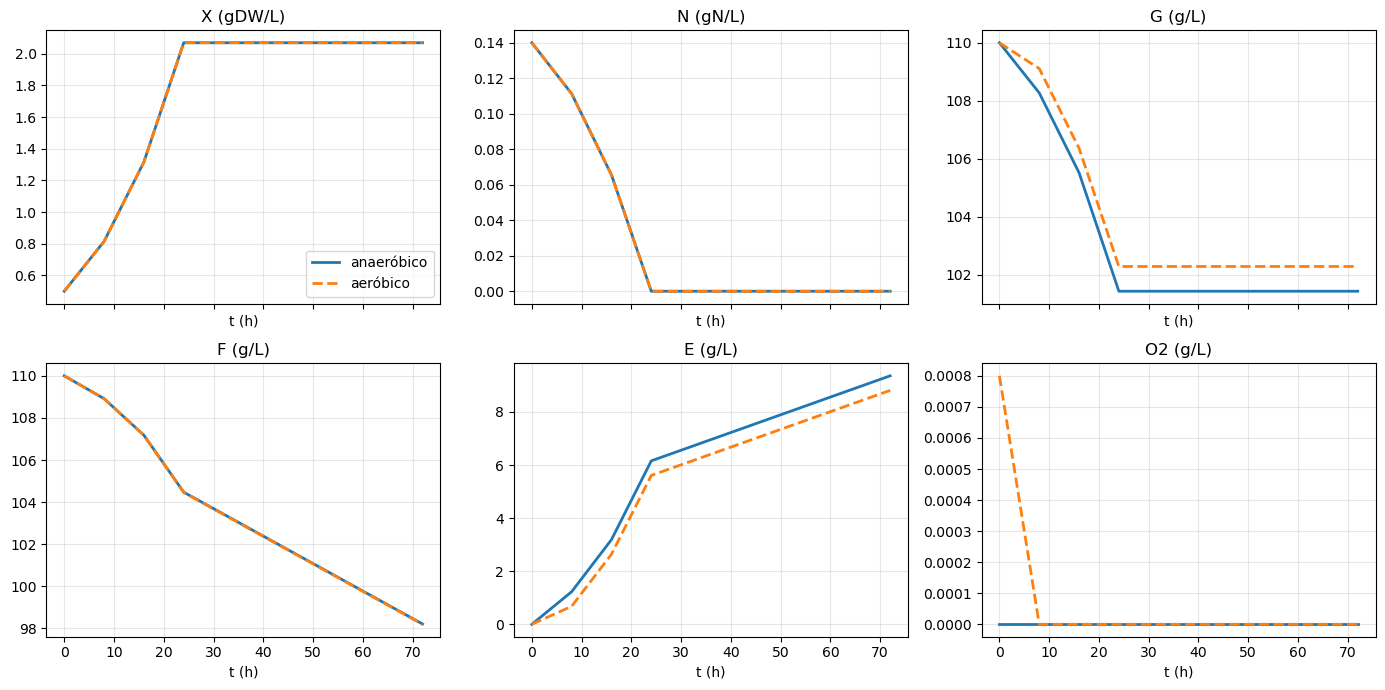

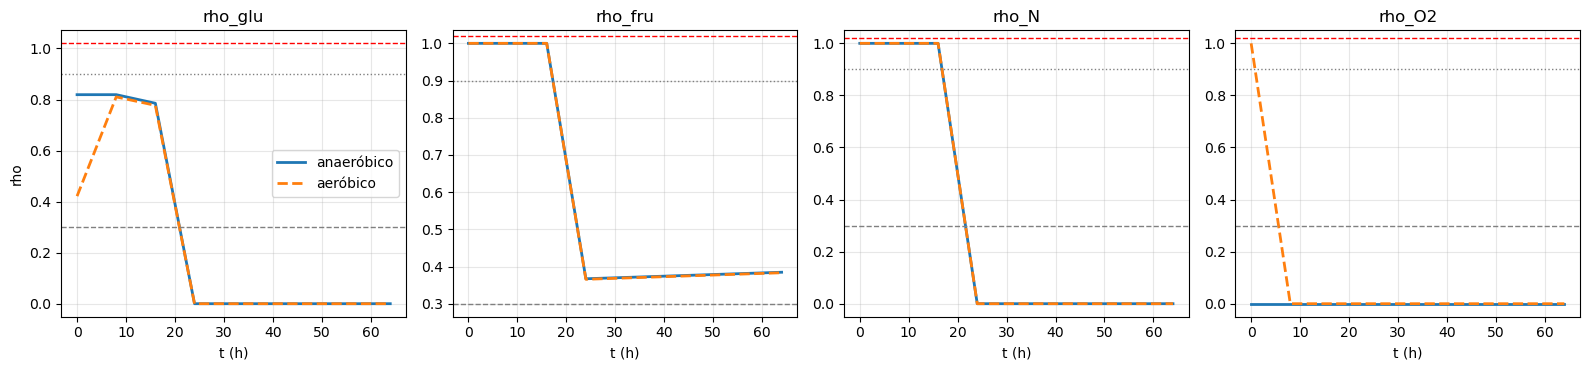

In [15]:
# dFBA SOA básico (dos bloques: anaeróbico y aeróbico) usando pFBA en cada paso
print("\n" + "=" * 100)
print("dFBA SOA básico con COBRApy (anaeróbico vs aeróbico) usando pFBA")
print("=" * 100)

# Horizonte y paso
DFBA_TH = 72.0
DFBA_DT = 8.0
n_steps = int(round(DFBA_TH / DFBA_DT))
time_grid = np.arange(n_steps + 1, dtype=float) * DFBA_DT

# Escenario aeróbico
O2_INIT_MG_L_AEROBIC = 0.8
O2_INIT_G_L_AEROBIC = O2_INIT_MG_L_AEROBIC / 1000.0
O2_KO_G_L = 0.002
O2_VMAX_UPTAKE = 2.0
O2_DEPLETION_THRESHOLD = 1e-6

# Cierre de uptake nitrogenado al agotarse N
N_DEPLETION_CLOSE_THRESHOLD = 1e-6
VITAMIN_TRACE_IDS = ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"]

def _n_atoms_from_formula(formula):
    if not formula:
        return 0
    mm = re.search(r"N(?![a-z])(\d*)", str(formula))
    if not mm:
        return 0
    gg = mm.group(1)
    return 1 if gg == "" else int(gg)

N_VITAMIN_EX_IDS = []
for rid in VITAMIN_TRACE_IDS:
    if rid in rxn_by_id and rxn_by_id[rid].metabolites:
        met = next(iter(rxn_by_id[rid].metabolites.keys()))
        if _n_atoms_from_formula(getattr(met, "formula", "")) > 0:
            N_VITAMIN_EX_IDS.append(rid)

MW_O2 = 0.031998

# IDs clave
OBJ_ID = "r_2111"
GLU_ID = "r_1714"
FRU_ID = "r_1709"
ETH_ID = "r_1761"
O2_ID = "r_1992"

required_ids = [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID] + KINETIC_N_SOURCE_IDS
missing = [rid for rid in required_ids if rid not in rxn_by_id]
if missing:
    raise RuntimeError(f"Faltan reacciones requeridas para dFBA: {missing}")

base_lb = {rid: float(rxn_by_id[rid].lower_bound) for rid in required_ids}
base_ub = {rid: float(rxn_by_id[rid].upper_bound) for rid in required_ids}

print(f"Regla N-depletion: cierre de vitaminas N cuando N <= {N_DEPLETION_CLOSE_THRESHOLD:g}")
print(f"Exchanges vitaminas-N afectados: {N_VITAMIN_EX_IDS}")

def _kinetic_limits(cX, cN, cG, cF, cE, cO2):
    mu_T  = np.exp(59453.0 * (T_val - 300.0) / (300.0 * R_GAS * T_val))
    Kg_T  = np.exp(46055.0 * (T_val - 293.15) / (293.15 * R_GAS * T_val))
    b_T   = np.exp(11000.0 * (T_val - 296.15) / (296.15 * R_GAS * T_val))
    mrate = MRATE_0 * np.exp(37681.0 * (T_val - 293.30) / (293.30 * R_GAS * T_val))

    mu = MU0_nom * mu_T * (cN / (cN + Kn0_nom * Kg_T + EPS))
    betaG = betaG0_nom * b_T * (cG / (cG + Kg0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))
    betaF = betaF0_nom * b_T * (cF / (cF + Kf0_nom * Kg_T + EPS)) * (Kig0_nom * Kg_T / (cG + Kig0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))

    vx = mu
    vg = mu / YXG_nom + betaG / YEG_nom + mrate * (cG / (cG + cF + EPS))
    vf = mu / YXF_nom + betaF / YEF_nom + mrate * (cF / (cG + cF + EPS))
    vn = mu / YXN_nom
    ve = (betaG + betaF) / MW_ETH

    lim_glu = max(0.0, vg / MW_GLU)
    lim_fru = max(0.0, vf / MW_FRU)
    lim_eth = max(0.0, ve)
    lim_obj = max(0.0, vx)
    lim_n_map = {rid: max(0.0, vn * N_frac_map[rid]) for rid in KINETIC_N_SOURCE_IDS}

    return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map

def _run_dfba_scenario(*, scenario_name, o2_init_g_l, aerobic_mode):
    y0 = np.array([0.5, 0.14, 110.0, 110.0, 0.0, o2_init_g_l], dtype=float)

    def _apply_dynamic_bounds(mtmp, y):
        cX, cN, cG, cF, cE, cO2 = [max(0.0, float(v)) for v in y]
        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits(cX, cN, cG, cF, cE, cO2)

        rb = {r.id: r for r in mtmp.reactions}
        for rid in required_ids:
            rb[rid].lower_bound = base_lb[rid]
            rb[rid].upper_bound = base_ub[rid]

        rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
        rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
        rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
        rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

        for rid in KINETIC_N_SOURCE_IDS:
            Li = float(lim_n_map[rid])
            rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
            rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

        if cN <= N_DEPLETION_CLOSE_THRESHOLD:
            for rid in N_VITAMIN_EX_IDS:
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        if APPLY_PRODUCT_CAPS:
            rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
            rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
        else:
            rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
            rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

        if aerobic_mode:
            lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS))
            lim_o2 = max(0.0, float(lim_o2))
            if cO2 <= O2_DEPLETION_THRESHOLD:
                lim_o2 = 0.0
            rb[O2_ID].lower_bound = -lim_o2
            rb[O2_ID].upper_bound = 0.0
        else:
            lim_o2 = 0.0
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        lim_n_total = sum(lim_n_map[rid] * N_atoms_map[rid] * MW_N for rid in KINETIC_N_SOURCE_IDS)
        return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_total, lim_o2

    Y = np.zeros((n_steps + 1, 6), dtype=float)
    Y[0, :] = y0

    mu_hist = np.zeros(n_steps)
    vglu_hist = np.zeros(n_steps)
    vfru_hist = np.zeros(n_steps)
    veth_hist = np.zeros(n_steps)
    vo2_hist = np.zeros(n_steps)
    vn_eff_hist = np.zeros(n_steps)
    lim_glu_hist = np.zeros(n_steps)
    lim_fru_hist = np.zeros(n_steps)
    lim_n_hist = np.zeros(n_steps)
    lim_o2_hist = np.zeros(n_steps)

    for k in range(n_steps):
        yk = np.maximum(Y[k, :], 0.0)

        with model as mtmp:
            lim_glu, lim_fru, _lim_eth, _lim_obj, lim_n_total, lim_o2 = _apply_dynamic_bounds(mtmp, yk)

            mtmp.objective = OBJ_ID
            mtmp.objective_direction = "max"
            try:
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
            except Exception:
                continue

            if getattr(sol, "status", "optimal") != "optimal":
                continue

            v_obj = float(sol.fluxes.get(OBJ_ID, 0.0))
            v_glu = float(sol.fluxes.get(GLU_ID, 0.0))
            v_fru = float(sol.fluxes.get(FRU_ID, 0.0))
            v_eth = float(sol.fluxes.get(ETH_ID, 0.0))
            v_o2 = float(sol.fluxes.get(O2_ID, 0.0))

            vn_eff = 0.0
            for rid in KINETIC_N_SOURCE_IDS:
                v_i = float(sol.fluxes.get(rid, 0.0))
                vn_eff += max(0.0, -v_i) * N_atoms_map[rid] * MW_N

        mu_hist[k] = max(0.0, v_obj)
        vglu_hist[k] = max(0.0, -v_glu)
        vfru_hist[k] = max(0.0, -v_fru)
        veth_hist[k] = max(0.0, v_eth)
        vo2_hist[k] = max(0.0, -v_o2)
        vn_eff_hist[k] = max(0.0, vn_eff)
        lim_glu_hist[k] = max(0.0, lim_glu)
        lim_fru_hist[k] = max(0.0, lim_fru)
        lim_n_hist[k] = max(0.0, lim_n_total)
        lim_o2_hist[k] = max(0.0, lim_o2)

        cX = max(0.0, yk[0])
        dX = v_obj * cX
        dN = -vn_eff * cX
        dG = -MW_GLU * max(0.0, -v_glu) * cX
        dF = -MW_FRU * max(0.0, -v_fru) * cX
        dE =  MW_ETH * max(0.0,  v_eth) * cX
        dO2 = -MW_O2  * max(0.0, -v_o2) * cX

        Y[k + 1, 0] = max(0.0, yk[0] + DFBA_DT * dX)
        Y[k + 1, 1] = max(0.0, yk[1] + DFBA_DT * dN)
        Y[k + 1, 2] = max(0.0, yk[2] + DFBA_DT * dG)
        Y[k + 1, 3] = max(0.0, yk[3] + DFBA_DT * dF)
        Y[k + 1, 4] = max(0.0, yk[4] + DFBA_DT * dE)
        Y[k + 1, 5] = max(0.0, yk[5] + DFBA_DT * dO2)

    X_hist = Y[:, 0]
    N_hist = Y[:, 1]
    G_hist = Y[:, 2]
    F_hist = Y[:, 3]
    E_hist = Y[:, 4]
    O2_hist = Y[:, 5]

    EPS_RHO = 1e-12
    rho_glu = vglu_hist / np.maximum(lim_glu_hist, EPS_RHO)
    rho_fru = vfru_hist / np.maximum(lim_fru_hist, EPS_RHO)
    rho_nit = vn_eff_hist / np.maximum(lim_n_hist, EPS_RHO)
    rho_o2 = vo2_hist / np.maximum(lim_o2_hist, EPS_RHO)

    aerobic_steps = np.where(O2_hist[:-1] > O2_DEPLETION_THRESHOLD)[0]
    if aerobic_steps.size > 0:
        t_transition_h = float(time_grid[int(aerobic_steps[-1]) + 1])
    else:
        t_transition_h = 0.0

    print("\n" + "=" * 100)
    print(f"Bloque dFBA-pFBA: {scenario_name}")
    print("=" * 100)
    print(f"Estado final: X={X_hist[-1]:.4f}, N={N_hist[-1]:.4f}, G={G_hist[-1]:.4f}, F={F_hist[-1]:.4f}, E={E_hist[-1]:.4f}, O2={O2_hist[-1]:.6f}")
    if aerobic_mode:
        print(f"O2 inicial: {o2_init_g_l*1000.0:.4f} mg/L | Transición estimada a anaerobiosis: t≈{t_transition_h:.2f} h")
    else:
        print("O2 inicial: 0.0000 mg/L | Condición anaeróbica fija (r_1992 cerrado)")

    file_suffix = "aerobic_pfba" if aerobic_mode else "anaerobic_pfba"
    out_file = OUT_DIR / f"dfba_direct_states_{file_suffix}.csv"
    arr_out = np.column_stack([time_grid, X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist])
    np.savetxt(out_file, arr_out, delimiter=",", header="t_h,X_gDW_L,N_gN_L,G_g_L,F_g_L,E_g_L,O2_g_L", comments="")
    print(f"Archivo guardado: {out_file}")

    return {
        "name": scenario_name,
        "X_hist": X_hist,
        "N_hist": N_hist,
        "G_hist": G_hist,
        "F_hist": F_hist,
        "E_hist": E_hist,
        "O2_hist": O2_hist,
        "rho_glu": rho_glu,
        "rho_fru": rho_fru,
        "rho_nit": rho_nit,
        "rho_o2": rho_o2,
    }

# Bloque 1: anaeróbico
res_ana = _run_dfba_scenario(
    scenario_name="Anaeróbico",
    o2_init_g_l=0.0,
    aerobic_mode=False,
)

# Bloque 2: aeróbico
res_aer = _run_dfba_scenario(
    scenario_name="Aeróbico (arranque O2=0.8 mg/L)",
    o2_init_g_l=O2_INIT_G_L_AEROBIC,
    aerobic_mode=True,
)

# Comparación gráfica de estados
fig, ax = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
series = [
    ("X_hist", "X (gDW/L)"),
    ("N_hist", "N (gN/L)"),
    ("G_hist", "G (g/L)"),
    ("F_hist", "F (g/L)"),
    ("E_hist", "E (g/L)"),
    ("O2_hist", "O2 (g/L)"),
]
for a, (key, lbl) in zip(ax.ravel(), series):
    a.plot(time_grid, res_ana[key], lw=2, label="anaeróbico")
    a.plot(time_grid, res_aer[key], lw=2, ls="--", label="aeróbico")
    a.set_title(lbl)
    a.grid(alpha=0.3)
    a.set_xlabel("t (h)")
ax.ravel()[0].legend()
plt.tight_layout()
plt.show()

# Comparación gráfica de activación de restricciones
fig, ax = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)
rho_map = [
    ("rho_glu", "rho_glu"),
    ("rho_fru", "rho_fru"),
    ("rho_nit", "rho_N"),
    ("rho_o2", "rho_O2"),
]
t_rho = time_grid[:-1]
for a, (key, title) in zip(ax, rho_map):
    a.plot(t_rho, res_ana[key], lw=2, label="anaeróbico")
    a.plot(t_rho, res_aer[key], lw=2, ls="--", label="aeróbico")
    a.axhline(0.30, color="gray", ls="--", lw=1)
    a.axhline(0.90, color="gray", ls=":", lw=1)
    a.axhline(1.02, color="red", ls="--", lw=1)
    a.set_title(title)
    a.set_xlabel("t (h)")
    a.grid(alpha=0.3)
ax[0].set_ylabel("rho")
ax[0].legend()
plt.tight_layout()
plt.show()


dFBA SOA con pFBA y cambio de objetivo por agotamiento de N
Regla N-depletion: N <= 1e-06 -> objetivo ATPM
ATPM no-growth bounds: [0.7, 1000.0]
Biomasa no-growth bounds: [0, 0]
Exchanges vitaminas-N afectados: ['r_2067', 'r_1671', 'r_1967', 'r_2028', 'r_1548', 'r_2038']

Bloque dFBA-pFBA: Anaeróbico
Estado final: X=2.0695, N=0.0000, G=68.5125, F=88.6025, E=31.1161, O2=0.000000
Pasos objetivo BIOMASS=3, ATPM=6
O2 inicial: 0.0000 mg/L | Condición anaeróbica fija (r_1992 cerrado)
Archivo guardado: out\dfba_direct_states_anaerobic_pfba_atpm_switch.csv

Bloque dFBA-pFBA: Aeróbico (arranque O2=0.8 mg/L)
Estado final: X=2.0695, N=0.0000, G=69.1101, F=88.5559, E=30.7140, O2=0.000000
Pasos objetivo BIOMASS=3, ATPM=6
O2 inicial: 0.8000 mg/L | Transición estimada a anaerobiosis: t≈8.00 h
Archivo guardado: out\dfba_direct_states_aerobic_pfba_atpm_switch.csv


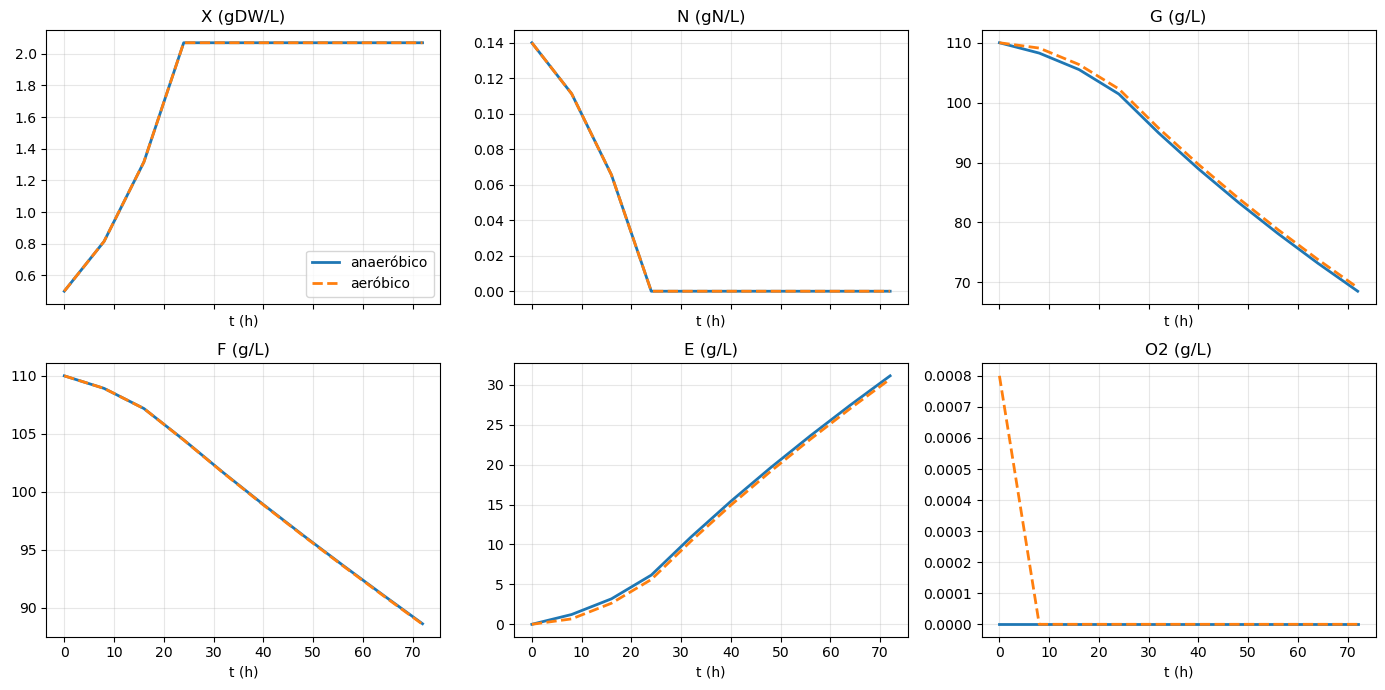

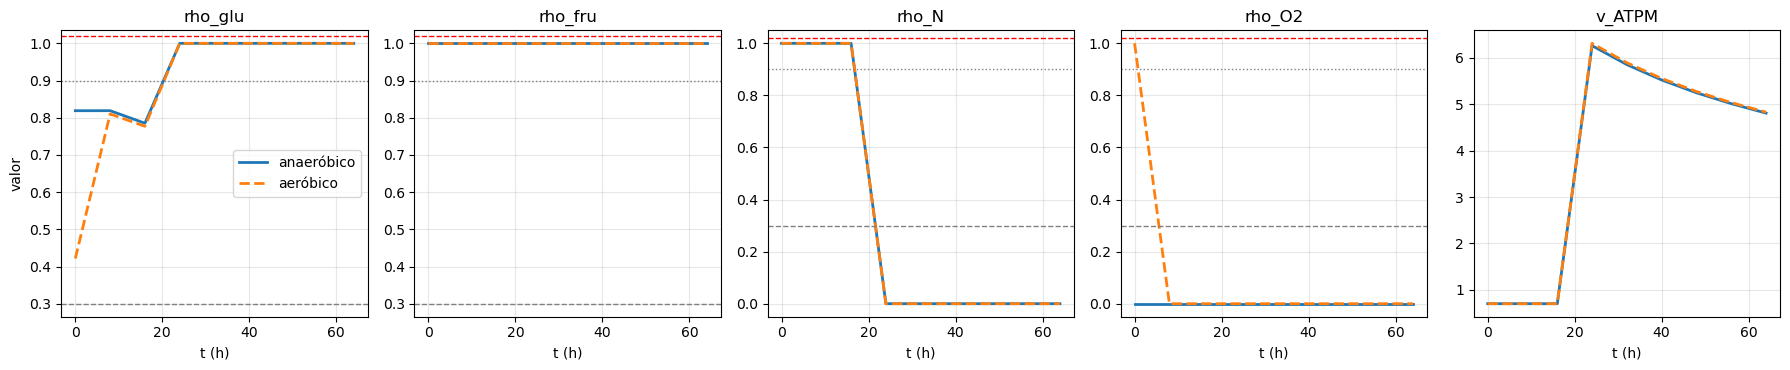

In [16]:
# dFBA SOA básico (dos bloques: anaeróbico y aeróbico) usando pFBA
# con cambio de objetivo al agotarse N:
# 1) ATPM: lb=0.7, ub=1000
# 2) Biomasa fija en 0
# 3) Objetivo = maximizar ATPM
print("\n" + "=" * 100)
print("dFBA SOA con pFBA y cambio de objetivo por agotamiento de N")
print("=" * 100)

DFBA_TH = 72.0
DFBA_DT = 8.0
n_steps = int(round(DFBA_TH / DFBA_DT))
time_grid = np.arange(n_steps + 1, dtype=float) * DFBA_DT

O2_INIT_MG_L_AEROBIC = 0.8
O2_INIT_G_L_AEROBIC = O2_INIT_MG_L_AEROBIC / 1000.0
O2_KO_G_L = 0.002
O2_VMAX_UPTAKE = 2.0
O2_DEPLETION_THRESHOLD = 1e-6

N_DEPLETION_CLOSE_THRESHOLD = 1e-6
VITAMIN_TRACE_IDS = ["r_2067", "r_1671", "r_1967", "r_2028", "r_1548", "r_2038", "r_1947"]

OBJ_ID = "r_2111"
GLU_ID = "r_1714"
FRU_ID = "r_1709"
ETH_ID = "r_1761"
O2_ID = "r_1992"
ATPM_ID = "r_4046"

ATPM_LB_NO_GROWTH = 0.7
ATPM_UB_NO_GROWTH = 1000.0

def _n_atoms_from_formula(formula):
    if not formula:
        return 0
    mm = re.search(r"N(?![a-z])(\d*)", str(formula))
    if not mm:
        return 0
    gg = mm.group(1)
    return 1 if gg == "" else int(gg)

N_VITAMIN_EX_IDS = []
for rid in VITAMIN_TRACE_IDS:
    if rid in rxn_by_id and rxn_by_id[rid].metabolites:
        met = next(iter(rxn_by_id[rid].metabolites.keys()))
        if _n_atoms_from_formula(getattr(met, "formula", "")) > 0:
            N_VITAMIN_EX_IDS.append(rid)

MW_O2 = 0.031998

required_ids = [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID, ATPM_ID] + KINETIC_N_SOURCE_IDS
missing = [rid for rid in required_ids if rid not in rxn_by_id]
if missing:
    raise RuntimeError(f"Faltan reacciones requeridas para dFBA: {missing}")

base_lb = {rid: float(rxn_by_id[rid].lower_bound) for rid in required_ids}
base_ub = {rid: float(rxn_by_id[rid].upper_bound) for rid in required_ids}

print(f"Regla N-depletion: N <= {N_DEPLETION_CLOSE_THRESHOLD:g} -> objetivo ATPM")
print(f"ATPM no-growth bounds: [{ATPM_LB_NO_GROWTH}, {ATPM_UB_NO_GROWTH}]")
print(f"Biomasa no-growth bounds: [0, 0]")
print(f"Exchanges vitaminas-N afectados: {N_VITAMIN_EX_IDS}")

def _kinetic_limits(cX, cN, cG, cF, cE, cO2):
    mu_T  = np.exp(59453.0 * (T_val - 300.0) / (300.0 * R_GAS * T_val))
    Kg_T  = np.exp(46055.0 * (T_val - 293.15) / (293.15 * R_GAS * T_val))
    b_T   = np.exp(11000.0 * (T_val - 296.15) / (296.15 * R_GAS * T_val))
    mrate = MRATE_0 * np.exp(37681.0 * (T_val - 293.30) / (293.30 * R_GAS * T_val))

    mu = MU0_nom * mu_T * (cN / (cN + Kn0_nom * Kg_T + EPS))
    betaG = betaG0_nom * b_T * (cG / (cG + Kg0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))
    betaF = betaF0_nom * b_T * (cF / (cF + Kf0_nom * Kg_T + EPS)) * (Kig0_nom * Kg_T / (cG + Kig0_nom * Kg_T + EPS)) * (Kie0_nom * Kg_T / (cE + Kie0_nom * Kg_T + EPS))

    vx = mu
    vg = mu / YXG_nom + betaG / YEG_nom + mrate * (cG / (cG + cF + EPS))
    vf = mu / YXF_nom + betaF / YEF_nom + mrate * (cF / (cG + cF + EPS))
    vn = mu / YXN_nom
    ve = (betaG + betaF) / MW_ETH

    lim_glu = max(0.0, vg / MW_GLU)
    lim_fru = max(0.0, vf / MW_FRU)
    lim_eth = max(0.0, ve)
    lim_obj = max(0.0, vx)
    lim_n_map = {rid: max(0.0, vn * N_frac_map[rid]) for rid in KINETIC_N_SOURCE_IDS}

    return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map

def _run_dfba_scenario(*, scenario_name, o2_init_g_l, aerobic_mode):
    y0 = np.array([0.5, 0.14, 110.0, 110.0, 0.0, o2_init_g_l], dtype=float)

    def _apply_dynamic_bounds(mtmp, y):
        cX, cN, cG, cF, cE, cO2 = [max(0.0, float(v)) for v in y]
        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits(cX, cN, cG, cF, cE, cO2)

        rb = {r.id: r for r in mtmp.reactions}
        for rid in required_ids:
            rb[rid].lower_bound = base_lb[rid]
            rb[rid].upper_bound = base_ub[rid]

        rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
        rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
        rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
        rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

        for rid in KINETIC_N_SOURCE_IDS:
            Li = float(lim_n_map[rid])
            rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
            rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

        if cN <= N_DEPLETION_CLOSE_THRESHOLD:
            for rid in N_VITAMIN_EX_IDS:
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        if APPLY_PRODUCT_CAPS:
            rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
            rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
        else:
            rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
            rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

        if aerobic_mode:
            lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS))
            lim_o2 = max(0.0, float(lim_o2))
            if cO2 <= O2_DEPLETION_THRESHOLD:
                lim_o2 = 0.0
            rb[O2_ID].lower_bound = -lim_o2
            rb[O2_ID].upper_bound = 0.0
        else:
            lim_o2 = 0.0
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        lim_n_total = sum(lim_n_map[rid] * N_atoms_map[rid] * MW_N for rid in KINETIC_N_SOURCE_IDS)
        return lim_glu, lim_fru, lim_eth, lim_obj, lim_n_total, lim_o2, rb

    Y = np.zeros((n_steps + 1, 6), dtype=float)
    Y[0, :] = y0

    mu_hist = np.zeros(n_steps)
    vglu_hist = np.zeros(n_steps)
    vfru_hist = np.zeros(n_steps)
    veth_hist = np.zeros(n_steps)
    vo2_hist = np.zeros(n_steps)
    vn_eff_hist = np.zeros(n_steps)
    vatpm_hist = np.zeros(n_steps)
    lim_glu_hist = np.zeros(n_steps)
    lim_fru_hist = np.zeros(n_steps)
    lim_n_hist = np.zeros(n_steps)
    lim_o2_hist = np.zeros(n_steps)
    mode_hist = []

    for k in range(n_steps):
        yk = np.maximum(Y[k, :], 0.0)
        cN = float(yk[1])

        with model as mtmp:
            lim_glu, lim_fru, _lim_eth, _lim_obj, lim_n_total, lim_o2, rb = _apply_dynamic_bounds(mtmp, yk)

            if cN <= N_DEPLETION_CLOSE_THRESHOLD:
                rb[ATPM_ID].lower_bound = ATPM_LB_NO_GROWTH
                rb[ATPM_ID].upper_bound = ATPM_UB_NO_GROWTH
                rb[OBJ_ID].lower_bound = 0.0
                rb[OBJ_ID].upper_bound = 0.0
                mtmp.objective = ATPM_ID
                mode_hist.append("ATPM")
            else:
                mtmp.objective = OBJ_ID
                mode_hist.append("BIOMASS")

            mtmp.objective_direction = "max"
            try:
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
            except Exception:
                mode_hist[-1] = "FAIL"
                continue

            if getattr(sol, "status", "optimal") != "optimal":
                mode_hist[-1] = "NO_OPT"
                continue

            v_obj = float(sol.fluxes.get(OBJ_ID, 0.0))
            v_glu = float(sol.fluxes.get(GLU_ID, 0.0))
            v_fru = float(sol.fluxes.get(FRU_ID, 0.0))
            v_eth = float(sol.fluxes.get(ETH_ID, 0.0))
            v_o2 = float(sol.fluxes.get(O2_ID, 0.0))
            v_atpm = float(sol.fluxes.get(ATPM_ID, 0.0))

            vn_eff = 0.0
            for rid in KINETIC_N_SOURCE_IDS:
                v_i = float(sol.fluxes.get(rid, 0.0))
                vn_eff += max(0.0, -v_i) * N_atoms_map[rid] * MW_N

        mu_hist[k] = max(0.0, v_obj)
        vglu_hist[k] = max(0.0, -v_glu)
        vfru_hist[k] = max(0.0, -v_fru)
        veth_hist[k] = max(0.0, v_eth)
        vo2_hist[k] = max(0.0, -v_o2)
        vn_eff_hist[k] = max(0.0, vn_eff)
        vatpm_hist[k] = max(0.0, v_atpm)
        lim_glu_hist[k] = max(0.0, lim_glu)
        lim_fru_hist[k] = max(0.0, lim_fru)
        lim_n_hist[k] = max(0.0, lim_n_total)
        lim_o2_hist[k] = max(0.0, lim_o2)

        cX = max(0.0, yk[0])
        dX = v_obj * cX
        dN = -vn_eff * cX
        dG = -MW_GLU * max(0.0, -v_glu) * cX
        dF = -MW_FRU * max(0.0, -v_fru) * cX
        dE =  MW_ETH * max(0.0,  v_eth) * cX
        dO2 = -MW_O2  * max(0.0, -v_o2) * cX

        Y[k + 1, 0] = max(0.0, yk[0] + DFBA_DT * dX)
        Y[k + 1, 1] = max(0.0, yk[1] + DFBA_DT * dN)
        Y[k + 1, 2] = max(0.0, yk[2] + DFBA_DT * dG)
        Y[k + 1, 3] = max(0.0, yk[3] + DFBA_DT * dF)
        Y[k + 1, 4] = max(0.0, yk[4] + DFBA_DT * dE)
        Y[k + 1, 5] = max(0.0, yk[5] + DFBA_DT * dO2)

    X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist = Y.T

    EPS_RHO = 1e-12
    rho_glu = vglu_hist / np.maximum(lim_glu_hist, EPS_RHO)
    rho_fru = vfru_hist / np.maximum(lim_fru_hist, EPS_RHO)
    rho_nit = vn_eff_hist / np.maximum(lim_n_hist, EPS_RHO)
    rho_o2 = vo2_hist / np.maximum(lim_o2_hist, EPS_RHO)

    atpm_steps = sum(m == "ATPM" for m in mode_hist)
    biomass_steps = sum(m == "BIOMASS" for m in mode_hist)

    aerobic_steps = np.where(O2_hist[:-1] > O2_DEPLETION_THRESHOLD)[0]
    if aerobic_steps.size > 0:
        t_transition_h = float(time_grid[int(aerobic_steps[-1]) + 1])
    else:
        t_transition_h = 0.0

    print("\n" + "=" * 100)
    print(f"Bloque dFBA-pFBA: {scenario_name}")
    print("=" * 100)
    print(f"Estado final: X={X_hist[-1]:.4f}, N={N_hist[-1]:.4f}, G={G_hist[-1]:.4f}, F={F_hist[-1]:.4f}, E={E_hist[-1]:.4f}, O2={O2_hist[-1]:.6f}")
    print(f"Pasos objetivo BIOMASS={biomass_steps}, ATPM={atpm_steps}")
    if aerobic_mode:
        print(f"O2 inicial: {o2_init_g_l*1000.0:.4f} mg/L | Transición estimada a anaerobiosis: t≈{t_transition_h:.2f} h")
    else:
        print("O2 inicial: 0.0000 mg/L | Condición anaeróbica fija (r_1992 cerrado)")

    file_suffix = "aerobic_pfba_atpm_switch" if aerobic_mode else "anaerobic_pfba_atpm_switch"
    out_file = OUT_DIR / f"dfba_direct_states_{file_suffix}.csv"
    arr_out = np.column_stack([time_grid, X_hist, N_hist, G_hist, F_hist, E_hist, O2_hist])
    np.savetxt(out_file, arr_out, delimiter=",", header="t_h,X_gDW_L,N_gN_L,G_g_L,F_g_L,E_g_L,O2_g_L", comments="")
    print(f"Archivo guardado: {out_file}")

    return {
        "name": scenario_name,
        "X_hist": X_hist,
        "N_hist": N_hist,
        "G_hist": G_hist,
        "F_hist": F_hist,
        "E_hist": E_hist,
        "O2_hist": O2_hist,
        "rho_glu": rho_glu,
        "rho_fru": rho_fru,
        "rho_nit": rho_nit,
        "rho_o2": rho_o2,
        "vatpm_hist": vatpm_hist,
        "mode_hist": mode_hist,
    }

res_ana = _run_dfba_scenario(
    scenario_name="Anaeróbico",
    o2_init_g_l=0.0,
    aerobic_mode=False,
)

res_aer = _run_dfba_scenario(
    scenario_name="Aeróbico (arranque O2=0.8 mg/L)",
    o2_init_g_l=O2_INIT_G_L_AEROBIC,
    aerobic_mode=True,
)

fig, ax = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
series = [
    ("X_hist", "X (gDW/L)"),
    ("N_hist", "N (gN/L)"),
    ("G_hist", "G (g/L)"),
    ("F_hist", "F (g/L)"),
    ("E_hist", "E (g/L)"),
    ("O2_hist", "O2 (g/L)"),
]
for a, (key, lbl) in zip(ax.ravel(), series):
    a.plot(time_grid, res_ana[key], lw=2, label="anaeróbico")
    a.plot(time_grid, res_aer[key], lw=2, ls="--", label="aeróbico")
    a.set_title(lbl)
    a.grid(alpha=0.3)
    a.set_xlabel("t (h)")
ax.ravel()[0].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 5, figsize=(18, 3.8), sharex=True)
rho_map = [
    ("rho_glu", "rho_glu"),
    ("rho_fru", "rho_fru"),
    ("rho_nit", "rho_N"),
    ("rho_o2", "rho_O2"),
    ("vatpm_hist", "v_ATPM"),
]
t_rho = time_grid[:-1]
for a, (key, title) in zip(ax, rho_map):
    a.plot(t_rho, res_ana[key], lw=2, label="anaeróbico")
    a.plot(t_rho, res_aer[key], lw=2, ls="--", label="aeróbico")
    if key.startswith("rho_"):
        a.axhline(0.30, color="gray", ls="--", lw=1)
        a.axhline(0.90, color="gray", ls=":", lw=1)
        a.axhline(1.02, color="red", ls="--", lw=1)
    a.set_title(title)
    a.set_xlabel("t (h)")
    a.grid(alpha=0.3)
ax[0].set_ylabel("valor")
ax[0].legend()
plt.tight_layout()
plt.show()

Versión con pFBA y turnover


dFBA SOA + pFBA con protein-turnover + aromas

[Indicadores globales]


,scenario,dfba_dt_h,n_dfba_steps,t_stationary_h,X_final_gDW_L,Prot_final_g_L,N0_total_gN_L,N0_ammonia_gN_L,AA0_each_mmol_L,N_total_depletion_threshold_gN_L,K_AA_uptake_growth_h_inv,AA_alpha_static,AA_uptake_growth_mean_mmol_gDW_h,turnover_uptake_mean_stat
0,Anaeróbico + turnover,1.0,72,53.0,2.104696,0.333635,0.14,0.07,0.9995,0.001,0.08,0.2,0.093866,5.649145e-17



[Flujos relevantes en el tiempo]


,t_h,mode,mu_h_inv,v_glu_uptake_mmol_gDW_h,v_fru_uptake_mmol_gDW_h,v_eth_prod_mmol_gDW_h,v_o2_uptake_mmol_gDW_h,v_N_uptake_gN_gDW_h,v_ATPM_mmol_gDW_h,v_Prot_mmol_gDW_h,...,v_turnover_met_mmol_gDW_h,v_uptake_tyr_mmol_gDW_h,v_release_tyr_mmol_L_h,v_turnover_internal_tyr_mmol_L_h,v_turnover_tyr_mmol_gDW_h,v_pea_prod_mmol_gDW_h,v_isoamyl_prod_mmol_gDW_h,v_isobutanol_prod_mmol_gDW_h,v_methionol_prod_mmol_gDW_h,v_tyrosol_prod_mmol_gDW_h
0,0.0,BIOMASS,0.096123,2.887534,1.463485,7.833577,0.0,0.003054,0.700000,0.096123,...,0.000000,2.481273e-02,0.0,0.000000,0.000000,0.145136,0.0,0.097978,0.0,0.013550
1,1.0,BIOMASS,0.095797,2.877522,1.459931,7.809452,0.0,0.003043,0.700000,0.095797,...,0.000000,1.001851e-01,0.0,0.000000,0.000000,0.119490,0.0,0.072492,0.0,0.088961
2,2.0,BIOMASS,0.095439,2.866571,1.455995,7.806318,0.0,0.003517,0.700000,0.095439,...,0.000000,1.241747e-01,0.0,0.000000,0.000000,0.098012,0.0,0.051189,0.0,0.112993
3,3.0,BIOMASS,0.094931,2.854216,1.451269,7.767611,0.0,0.003903,0.700000,0.094931,...,0.000000,1.042876e-01,0.0,0.000000,0.000000,0.080042,0.0,0.033469,0.0,0.093165
4,4.0,BIOMASS,0.094264,2.840336,1.445647,7.733118,0.0,0.003875,0.700000,0.094264,...,0.000000,8.762617e-02,0.0,0.000000,0.000000,0.065024,0.0,0.018778,0.0,0.076582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,67.0,TURNOVER_ATPM,0.000000,1.857569,0.855668,5.426473,0.0,0.000000,5.426473,0.000000,...,0.001137,8.287180e-18,0.0,0.002392,0.001137,0.000000,0.0,0.000000,0.0,0.000000
68,68.0,TURNOVER_ATPM,0.000000,1.842747,0.852876,5.391246,0.0,0.000000,5.391246,0.000000,...,0.001097,1.801840e-17,0.0,0.002308,0.001097,0.000000,0.0,0.000000,0.0,0.000000
69,69.0,TURNOVER_ATPM,0.000000,1.828216,0.850163,5.356758,0.0,0.000000,5.356758,0.000000,...,0.001058,8.287180e-18,0.0,0.002228,0.001058,0.000000,0.0,0.000000,0.0,0.000000
70,70.0,TURNOVER_ATPM,0.000000,1.813967,0.847525,5.322985,0.0,0.000000,5.322985,0.000000,...,0.001021,0.000000e+00,0.0,0.002150,0.001021,0.000000,0.0,0.000000,0.0,0.000000



[Solución de v en el tiempo]


,t_h,mode,mu_mmol_gDW_h,v_glu_mmol_gDW_h,v_fru_mmol_gDW_h,v_eth_mmol_gDW_h,v_o2_mmol_gDW_h,v_ATPM_mmol_gDW_h,v_Prot_mmol_gDW_h,v_phe_mmol_gDW_h,v_leu_mmol_gDW_h,v_val_mmol_gDW_h,v_met_mmol_gDW_h,v_tyr_mmol_gDW_h,v_pea_mmol_gDW_h,v_isoamyl_mmol_gDW_h,v_isobutanol_mmol_gDW_h,v_methionol_mmol_gDW_h,v_tyrosol_mmol_gDW_h
0,0.0,BIOMASS,0.096123,-2.887534,-1.463485,7.833577,0.0,0.700000,0.096123,-0.159920,-1.599200e-01,-1.599200e-01,-4.157076e-02,-2.481273e-02,0.145136,0.0,0.097978,0.0,0.013550
1,1.0,BIOMASS,0.095797,-2.877522,-1.459931,7.809452,0.0,0.700000,0.095797,-0.134224,-1.342244e-01,-1.342244e-01,-4.142983e-02,-1.001851e-01,0.119490,0.0,0.072492,0.0,0.088961
2,2.0,BIOMASS,0.095439,-2.866571,-1.455995,7.806318,0.0,0.700000,0.095439,-0.112691,-1.126909e-01,-1.126909e-01,-4.127484e-02,-1.241747e-01,0.098012,0.0,0.051189,0.0,0.112993
3,3.0,BIOMASS,0.094931,-2.854216,-1.451269,7.767611,0.0,0.700000,0.094931,-0.094643,-9.464301e-02,-9.464301e-02,-3.071182e-02,-1.042876e-01,0.080042,0.0,0.033469,0.0,0.093165
4,4.0,BIOMASS,0.094264,-2.840336,-1.445647,7.733118,0.0,0.700000,0.094264,-0.079522,-7.952243e-02,-7.952243e-02,-2.399454e-02,-8.762617e-02,0.065024,0.0,0.018778,0.0,0.076582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,67.0,TURNOVER_ATPM,0.000000,-1.857569,-0.855668,5.426473,0.0,5.426473,0.000000,0.000000,-1.676893e-31,-4.143590e-18,3.225333e-31,-8.287180e-18,0.000000,0.0,0.000000,0.0,0.000000
68,68.0,TURNOVER_ATPM,0.000000,-1.842747,-0.852876,5.391246,0.0,5.391246,0.000000,0.000000,-6.097791e-32,-9.009198e-18,4.779327e-33,-1.801840e-17,0.000000,0.0,0.000000,0.0,0.000000
69,69.0,TURNOVER_ATPM,0.000000,-1.828216,-0.850163,5.356758,0.0,5.356758,0.000000,0.000000,-1.676893e-31,-4.143590e-18,3.225333e-31,-8.287180e-18,0.000000,0.0,0.000000,0.0,0.000000
70,70.0,TURNOVER_ATPM,0.000000,-1.813967,-0.847525,5.322985,0.0,5.322985,0.000000,0.000000,5.512422e-16,-6.713165e-17,1.259320e-15,0.000000e+00,0.000000,0.0,0.000000,0.0,0.000000


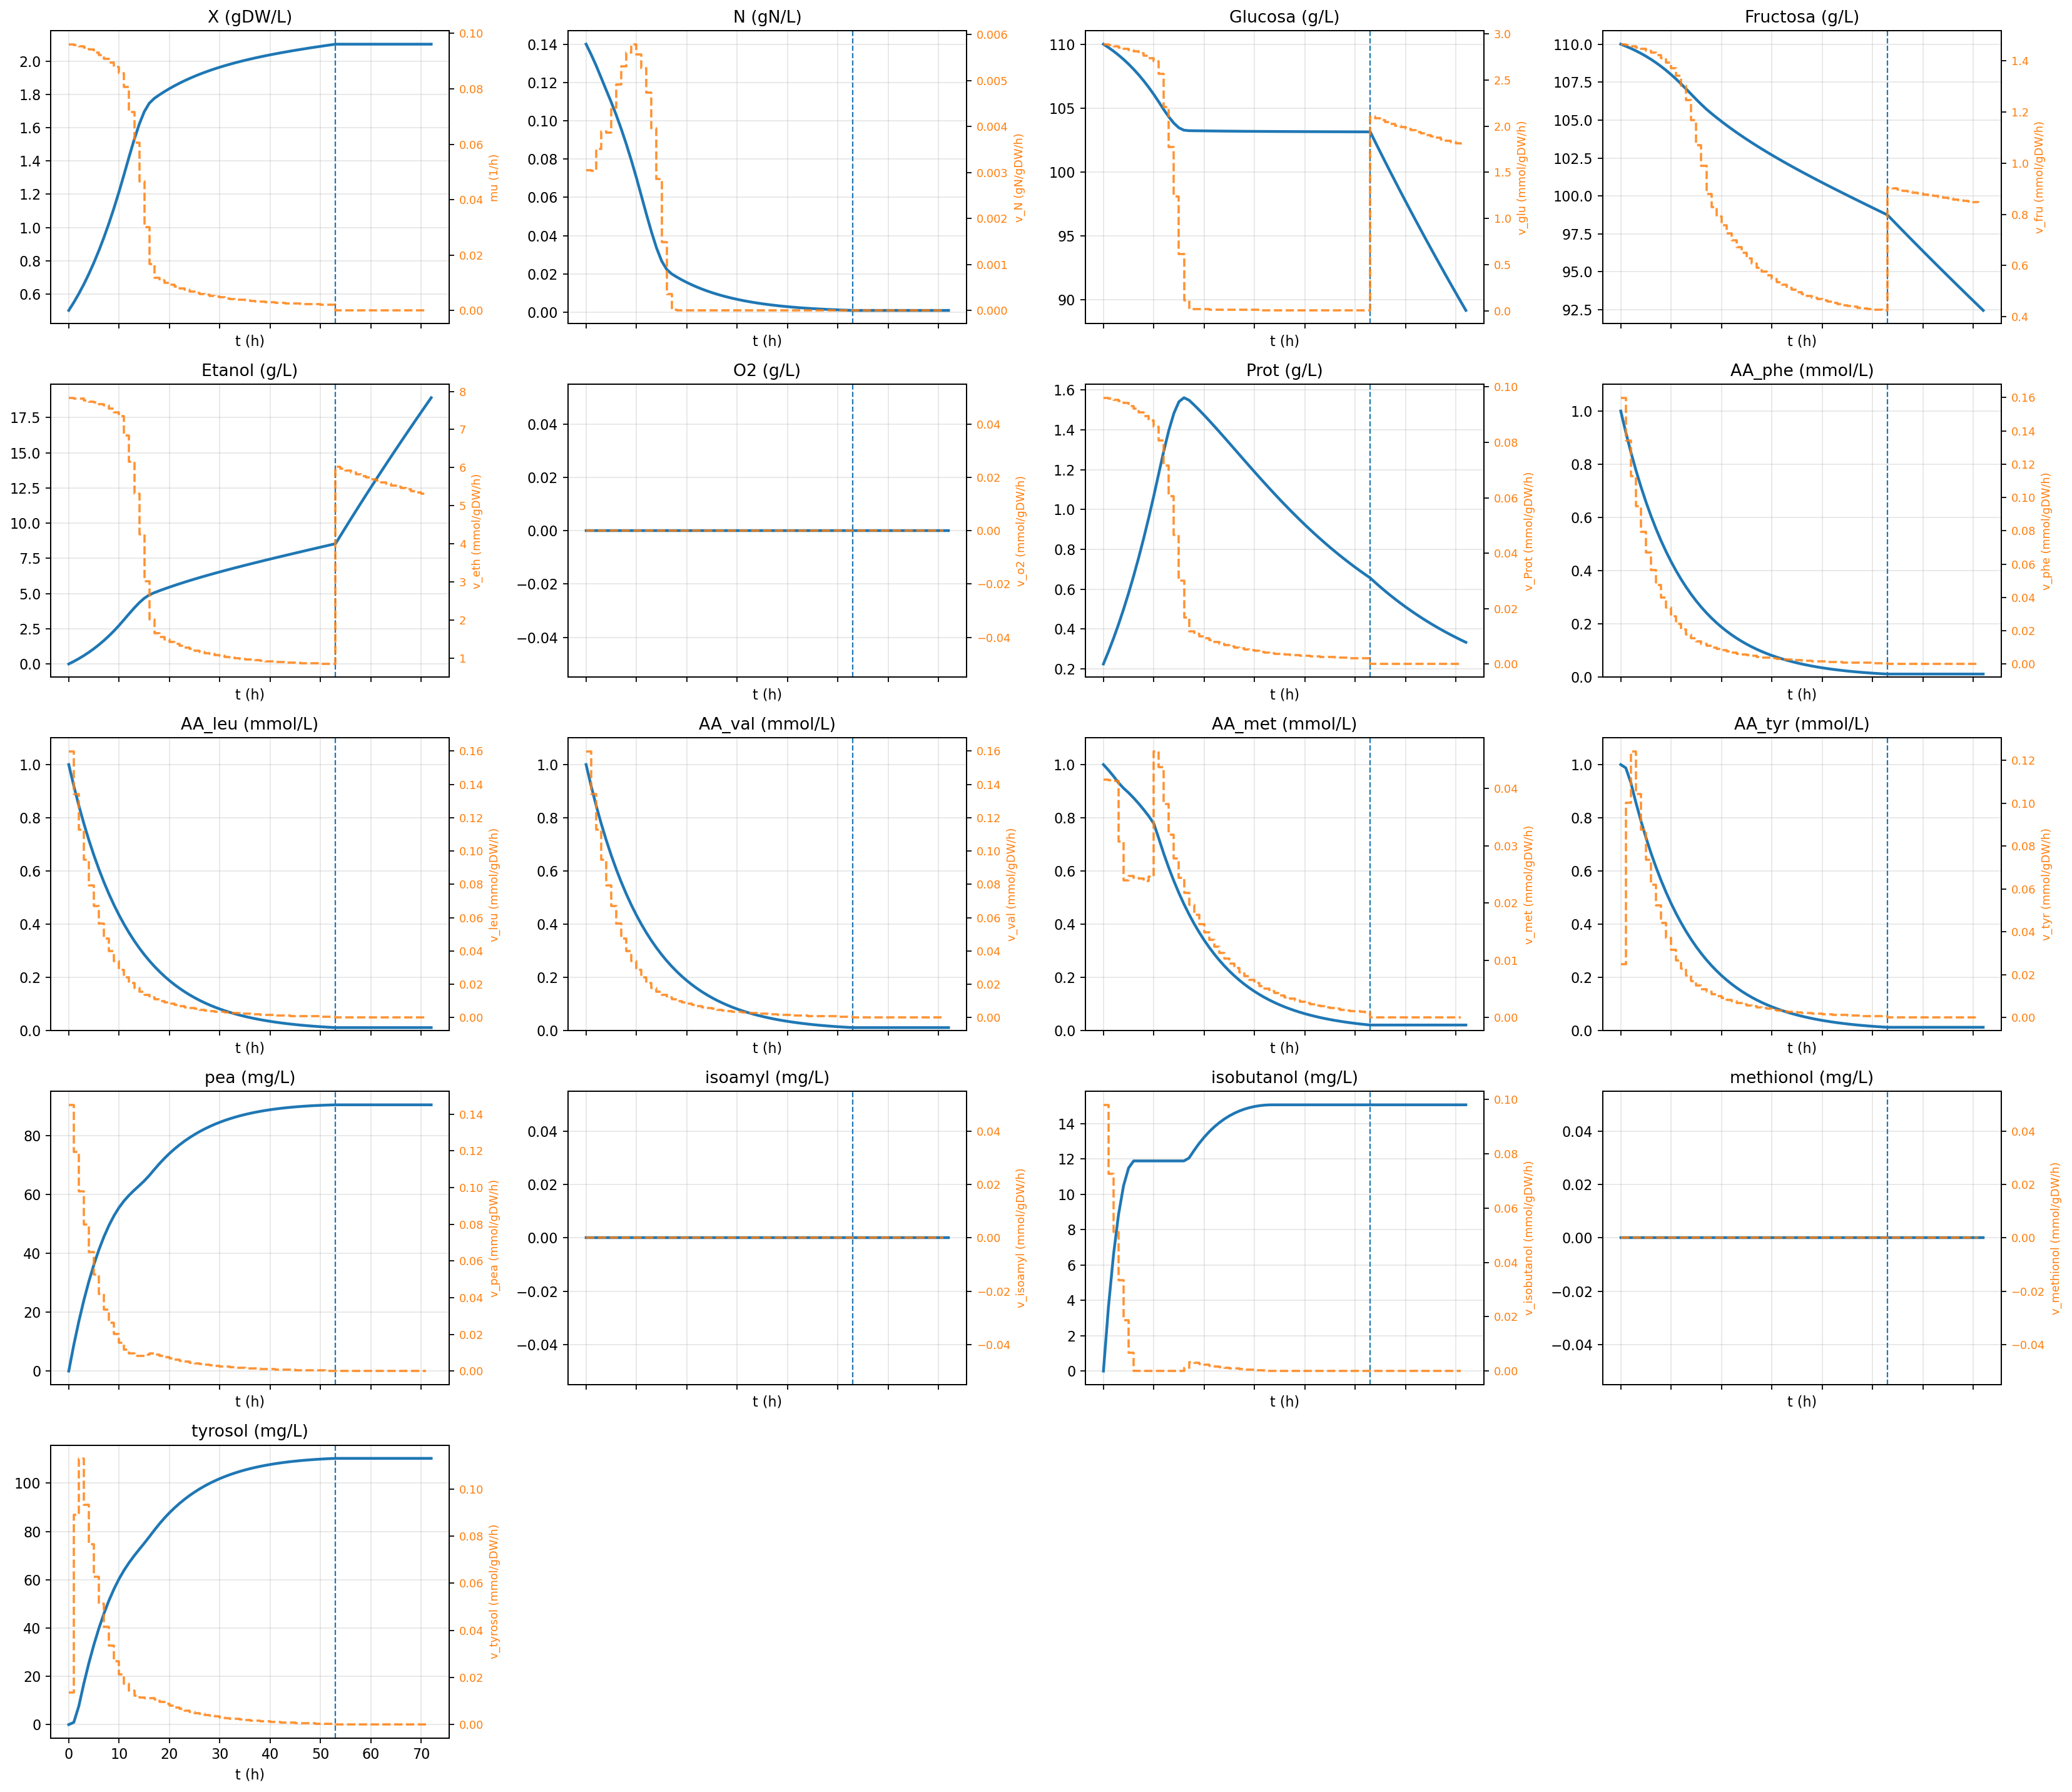

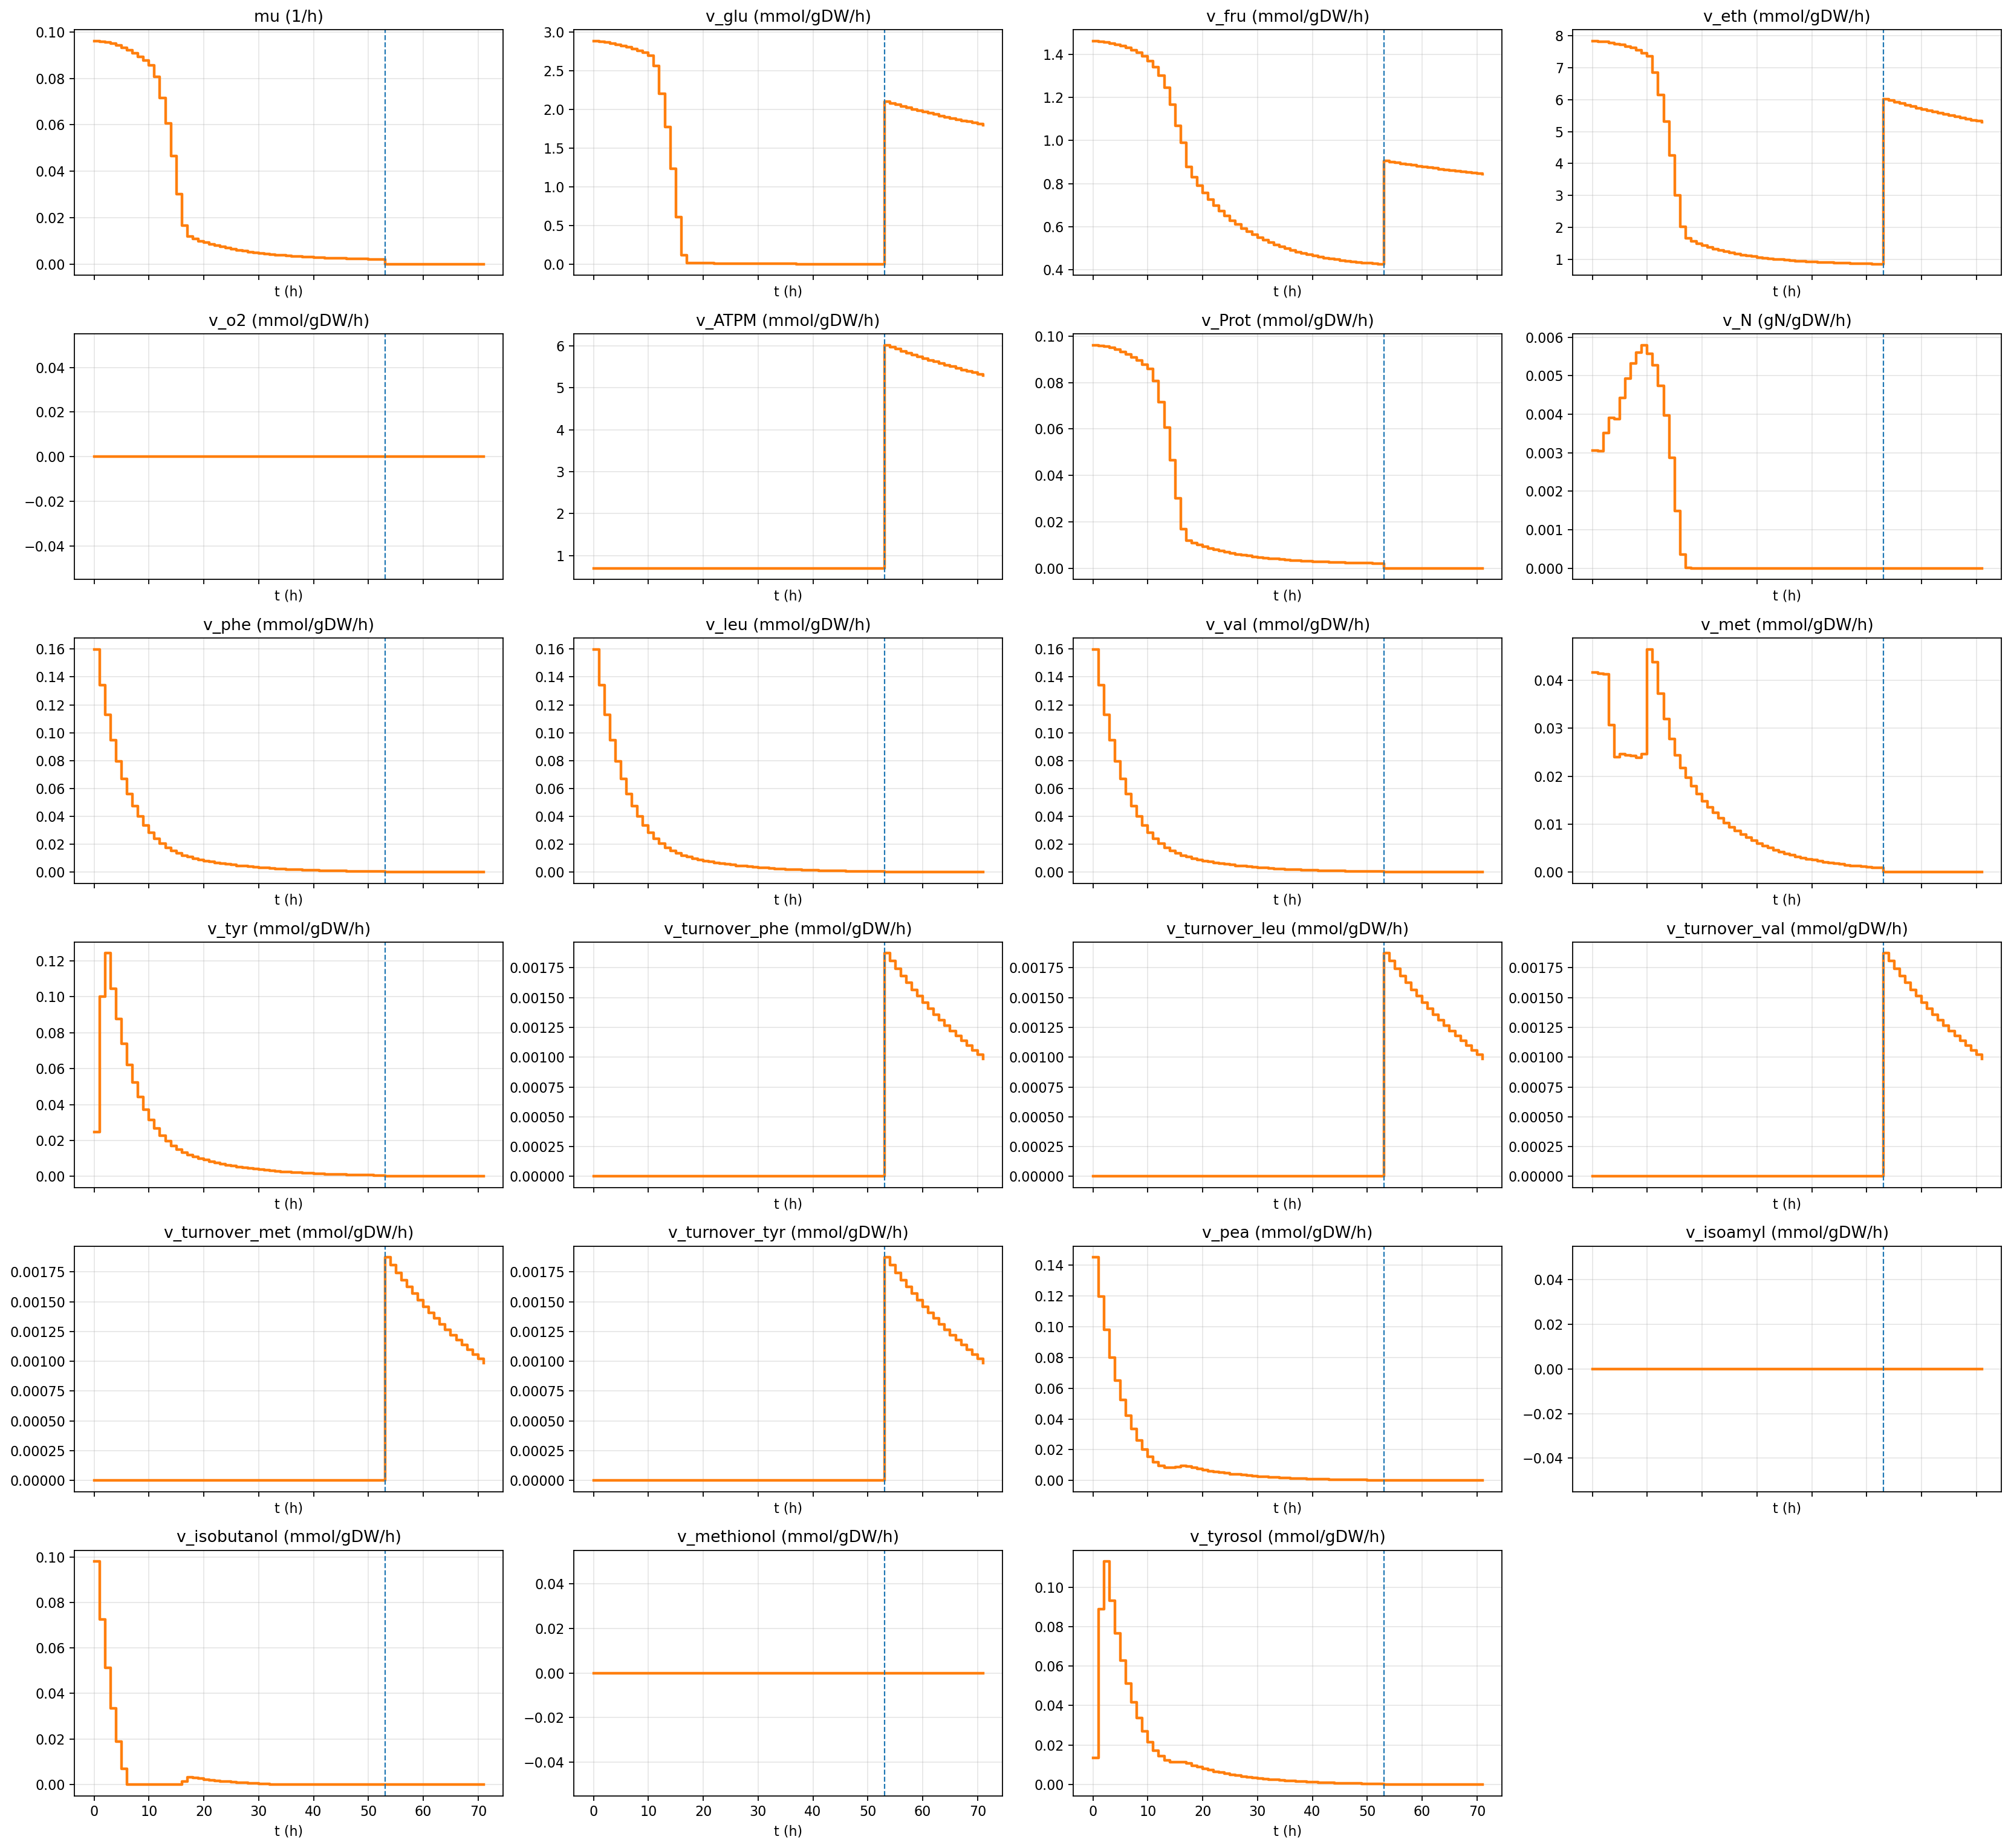

In [17]:
# ======================================================================================
# dFBA SOA + pFBA con protein-turnover y tracking de aromas fermentativos
# ======================================================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cobra

print("\n" + "=" * 100)
print("dFBA SOA + pFBA con protein-turnover + aromas")
print("=" * 100)

required_symbols = [
    "model", "rxn_by_id", "required_ids", "base_lb", "base_ub",
    "KINETIC_N_SOURCE_IDS", "N_VITAMIN_EX_IDS", "N_atoms_map",
    "OBJ_ID", "GLU_ID", "FRU_ID", "ETH_ID", "O2_ID", "ATPM_ID",
    "ATPM_LB_NO_GROWTH", "ATPM_UB_NO_GROWTH",
    "_kinetic_limits", "DFBA_DT", "time_grid",
    "N_DEPLETION_CLOSE_THRESHOLD", "O2_DEPLETION_THRESHOLD",
    "O2_VMAX_UPTAKE", "O2_KO_G_L",
    "MW_GLU", "MW_FRU", "MW_ETH", "MW_N", "MW_O2",
    "OUT_DIR", "APPLY_PRODUCT_CAPS", "EPS",
]
missing_symbols = [s for s in required_symbols if s not in globals()]
if missing_symbols:
    raise RuntimeError(f"Faltan símbolos requeridos: {missing_symbols}")


def _rxn_search_text(rxn):
    met_names = " ".join(getattr(m, "name", "") for m in rxn.metabolites)
    return f"{rxn.id} {rxn.name} {met_names}".lower()


def _is_exchange_like(rxn):
    nm = (rxn.name or "").lower()
    return ("exchange" in nm) or (len(rxn.metabolites) == 1)


def _find_candidates(keyword_sets, exchange_preferred=True):
    found = []
    for rxn in model.reactions:
        txt = _rxn_search_text(rxn)
        for kws in keyword_sets:
            if all(str(k).lower() in txt for k in kws):
                score = 0
                if exchange_preferred and _is_exchange_like(rxn):
                    score -= 10
                score += len(rxn.metabolites)
                found.append((score, rxn.id, rxn.name))
                break
    return sorted(set(found))


def _pick_first(keyword_sets, manual_id=None, exchange_preferred=True):
    if manual_id is not None:
        if manual_id not in {r.id for r in model.reactions}:
            raise RuntimeError(f"Manual ID no encontrado: {manual_id}")
        return manual_id, [(0, manual_id, model.reactions.get_by_id(manual_id).name)]
    cands = _find_candidates(keyword_sets, exchange_preferred=exchange_preferred)
    rid = cands[0][1] if cands else None
    return rid, cands


MANUAL_PROT_RXN_ID = "r_4047"
MANUAL_AA_EX_IDS = {"phe": None, "leu": None, "val": None, "met": None, "tyr": None}
MANUAL_AROMA_EX_IDS = {"pea": None, "isoamyl": None, "isobutanol": None, "methionol": None, "tyrosol": None}

PROT_SEARCH = [["protein", "exchange"], ["protein", "production"], ["protein"]]
AA_SEARCH = {
    "phe": [["phenylalanine", "exchange"], ["l-phenylalanine"], ["phenylalanine"]],
    "leu": [["leucine", "exchange"], ["l-leucine"], ["leucine"]],
    "val": [["valine", "exchange"], ["l-valine"], ["valine"]],
    "met": [["methionine", "exchange"], ["l-methionine"], ["methionine"]],
    "tyr": [["tyrosine", "exchange"], ["l-tyrosine"], ["tyrosine"]],
}
AROMA_SEARCH = {
    "pea": [["2-phenylethanol", "exchange"], ["phenylethanol", "exchange"], ["pea", "exchange"]],
    "isoamyl": [["isoamyl alcohol", "exchange"], ["3-methyl-1-butanol", "exchange"], ["isoamyl"]],
    "isobutanol": [["isobutanol", "exchange"], ["2-methyl-1-propanol", "exchange"], ["isobutanol"]],
    "methionol": [["methionol", "exchange"], ["3-methylthio-1-propanol", "exchange"], ["methionol"]],
    "tyrosol": [["tyrosol", "exchange"], ["tyrosol"]],
}

PROT_RXN_ID, prot_cands = _pick_first(PROT_SEARCH, manual_id=MANUAL_PROT_RXN_ID, exchange_preferred=True)
AA_EX_IDS, AROMA_EX_IDS = {}, {}
for k, qs in AA_SEARCH.items():
    AA_EX_IDS[k], _ = _pick_first(qs, manual_id=MANUAL_AA_EX_IDS.get(k), exchange_preferred=True)
for k, qs in AROMA_SEARCH.items():
    AROMA_EX_IDS[k], _ = _pick_first(qs, manual_id=MANUAL_AROMA_EX_IDS.get(k), exchange_preferred=True)

found_precursors = {k: v for k, v in AA_EX_IDS.items() if v is not None}
found_aromas = {k: v for k, v in AROMA_EX_IDS.items() if v is not None}
if PROT_RXN_ID is None or len(found_precursors) < 3:
    raise RuntimeError("Revisa mapeo PROT/AA en MANUAL_*_IDS")

# ---------------------------
# Parámetros
# ---------------------------
PROT_CONTENT = 0.45
K_DEATH = 0.005
TURNOVER_LAMBDA = 0.03
VPROT_FLOOR_FRAC = 0.90
XA_FRACTION = 1.0
N_AMMONIA_FRACTION = 0.50  # fracción de N macroscópico inicial como N amoniacal
N_TOTAL_DEPLETION_THRESHOLD = 1e-3

# NUEVO: cinética de uptake en crecimiento (misma k para todos)
K_AA_UPTAKE_GROWTH = 0.08  # 1/h
BIOMASS_LOCK_FRAC = 0.999  # lock de biomasa para fase B en crecimiento
AA_UPTAKE_WEIGHT = 1.0

# Refinamiento temporal del dFBA
DFBA_DT_FINE = min(float(DFBA_DT), 1.0)
TIME_GRID_FINE = np.arange(float(time_grid[0]), float(time_grid[-1]) + 0.5 * DFBA_DT_FINE, DFBA_DT_FINE)

AA_ALPHA_TOTAL = 1.0
AA_ALPHA_STATIC = AA_ALPHA_TOTAL / max(1, len(found_precursors))
AA_ALPHA = {k: AA_ALPHA_STATIC for k in found_precursors.keys()}

AA_MW = {
    "phe": 0.16519,
    "leu": 0.13117,
    "val": 0.11715,
    "met": 0.14921,
    "tyr": 0.18119,
}
AROMA_MW = {
    "pea": 0.12217,
    "isoamyl": 0.08815,
    "isobutanol": 0.07412,
    "methionol": 0.10619,
    "tyrosol": 0.13816,
}

TRACKED_RXN_IDS = list(dict.fromkeys(
    list(required_ids)
    + [PROT_RXN_ID]
    + [rid for rid in AA_EX_IDS.values() if rid is not None]
    + [rid for rid in AROMA_EX_IDS.values() if rid is not None]
) )
base_lb_turn, base_ub_turn = {}, {}
for rid in TRACKED_RXN_IDS:
    rxn = model.reactions.get_by_id(rid)
    base_lb_turn[rid] = float(rxn.lower_bound)
    base_ub_turn[rid] = float(rxn.upper_bound)


def _run_dfba_turnover_aroma(*, scenario_name="Anaeróbico-turnover", aerobic_mode=False, o2_init_g_l=0.0, dfba_dt=DFBA_DT_FINE, time_grid_local=TIME_GRID_FINE):
    aroma_keys = list(found_aromas.keys())
    aa_keys = list(found_precursors.keys())
    n_aroma = len(aroma_keys)
    n_aa = len(aa_keys)
    dt = float(dfba_dt)
    tt = np.asarray(time_grid_local, dtype=float)

    # Partición de N inicial: 50% amoniacal + 50% en AA (uniforme entre AA_i)
    N0_total = float(globals().get("N0", 0.14))
    N0_ammonia = N0_total * N_AMMONIA_FRACTION
    N0_from_aa = max(0.0, N0_total - N0_ammonia)
    aa0_each_mmol_L = (N0_from_aa / MW_N) / max(1, n_aa)

    # Estados: [X,N,G,F,E,O2,Prot,AA_i...,aromas...]
    Y = np.zeros((len(tt), 7 + n_aa + n_aroma), dtype=float)
    Y[0, 0] = 0.5
    Y[0, 1] = N0_ammonia
    Y[0, 2] = 110.0
    Y[0, 3] = 110.0
    Y[0, 4] = 0.0
    Y[0, 5] = o2_init_g_l
    Y[0, 6] = Y[0, 0] * PROT_CONTENT
    for idx in range(n_aa):
        Y[0, 7 + idx] = aa0_each_mmol_L

    n_steps = len(tt) - 1
    mu_hist = np.zeros(n_steps)
    vglu_hist, vfru_hist, veth_hist = np.zeros(n_steps), np.zeros(n_steps), np.zeros(n_steps)
    vo2_hist, vn_eff_hist = np.zeros(n_steps), np.zeros(n_steps)
    vatpm_hist, vprot_hist, vprot_star_hist = np.zeros(n_steps), np.zeros(n_steps), np.zeros(n_steps)
    turn_cap_hist, turn_uptake_hist = np.zeros(n_steps), np.zeros(n_steps)
    mode_hist = []

    aroma_flux_hist = {k: np.zeros(n_steps) for k in aroma_keys}
    precursor_uptake_hist = {k: np.zeros(n_steps) for k in aa_keys}
    precursor_net_flux_hist = {k: np.zeros(n_steps) for k in aa_keys}
    aa_release_hist = {k: np.zeros(n_steps) for k in aa_keys}
    aa_turnover_internal_hist = {k: np.zeros(n_steps) for k in aa_keys}

    interest_rxn_ids = [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID, ATPM_ID, PROT_RXN_ID] + list(found_precursors.values()) + list(found_aromas.values())
    interest_rxn_ids = list(dict.fromkeys(interest_rxn_ids))
    v_interest_hist = {rid: np.zeros(n_steps) for rid in interest_rxn_ids}

    def _apply_bounds_turnover(mtmp, y):
        cX, cN_free, cG, cF, cE, cO2, cProt = [max(0.0, float(v)) for v in y[:7]]
        aa_state = {aa_key: max(0.0, float(y[7 + idx])) for idx, aa_key in enumerate(aa_keys)}
        aa_n_total = MW_N * float(sum(aa_state.values()))
        cN_total = cN_free + aa_n_total

        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits(cX, cN_free, cG, cF, cE, cO2)
        rb = {r.id: r for r in mtmp.reactions}

        for rid in TRACKED_RXN_IDS:
            rb[rid].lower_bound = base_lb_turn[rid]
            rb[rid].upper_bound = base_ub_turn[rid]

        rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
        rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
        rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
        rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

        for rid in KINETIC_N_SOURCE_IDS:
            Li = float(lim_n_map[rid])
            rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
            rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

        if APPLY_PRODUCT_CAPS:
            rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
            rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
        else:
            rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
            rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

        if aerobic_mode:
            lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS))
            lim_o2 = max(0.0, float(lim_o2))
            if cO2 <= O2_DEPLETION_THRESHOLD:
                lim_o2 = 0.0
            rb[O2_ID].lower_bound = -lim_o2
            rb[O2_ID].upper_bound = 0.0
        else:
            rb[O2_ID].lower_bound = 0.0
            rb[O2_ID].upper_bound = 0.0

        turnover_caps = {k: 0.0 for k in aa_keys}

        if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
            for aa_key, rid in found_precursors.items():
                q_i = K_AA_UPTAKE_GROWTH * aa_state[aa_key] / max(cX, EPS)
                q_i = max(0.0, float(q_i))
                rb[rid].lower_bound = -q_i
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)
                turnover_caps[aa_key] = q_i
            qturn_total = float(sum(turnover_caps.values()))
        else:
            for rid in KINETIC_N_SOURCE_IDS:
                rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)
            for rid in N_VITAMIN_EX_IDS:
                if rid in rb:
                    rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                    rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

            XA = max(EPS, XA_FRACTION * cX)
            for aa_key, rid in found_precursors.items():
                q_i = TURNOVER_LAMBDA * cProt * AA_ALPHA[aa_key] / XA
                q_i = max(0.0, float(q_i))
                rb[rid].lower_bound = -q_i
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)
                turnover_caps[aa_key] = q_i
            qturn_total = float(sum(turnover_caps.values()))

        return rb, turnover_caps, qturn_total, cN_total

    for k in range(n_steps):
        yk = np.maximum(Y[k, :], 0.0)
        cX, cN, cG, cF, cE, cO2, cProt = yk[:7]

        with model as mtmp:
            rb, turnover_caps, qturn_total, cN_total = _apply_bounds_turnover(mtmp, yk)

            if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
                mode_hist.append("BIOMASS")
                try:
                    mtmp.objective = OBJ_ID
                    mtmp.objective_direction = "max"
                    sol_mu = mtmp.optimize()
                except Exception:
                    mode_hist[-1] = "FAIL"
                    continue
                if getattr(sol_mu, "status", "") != "optimal":
                    mode_hist[-1] = "NO_OPT"
                    continue

                mu_star = max(0.0, float(sol_mu.fluxes.get(OBJ_ID, 0.0)))
                rb[OBJ_ID].lower_bound = max(float(rb[OBJ_ID].lower_bound), BIOMASS_LOCK_FRAC * mu_star)

                uptake_obj = {mtmp.reactions.get_by_id(rid): -AA_UPTAKE_WEIGHT for rid in found_precursors.values()}
                mtmp.objective = uptake_obj
                mtmp.objective_direction = "max"
                try:
                    sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
                except Exception:
                    mode_hist[-1] = "FAIL"
                    continue
                vprot_star = 0.0
            else:
                rb[OBJ_ID].lower_bound = 0.0
                rb[OBJ_ID].upper_bound = 0.0

                vprot_star = 0.0
                try:
                    mtmp.objective = PROT_RXN_ID
                    mtmp.objective_direction = "max"
                    sol_prot = mtmp.optimize()
                    if getattr(sol_prot, "status", "") == "optimal":
                        vprot_star = max(0.0, float(sol_prot.fluxes.get(PROT_RXN_ID, 0.0)))
                except Exception:
                    vprot_star = 0.0

                if vprot_star > 1e-10:
                    rb[PROT_RXN_ID].lower_bound = max(float(rb[PROT_RXN_ID].lower_bound), VPROT_FLOOR_FRAC * vprot_star)

                rb[ATPM_ID].lower_bound = ATPM_LB_NO_GROWTH
                rb[ATPM_ID].upper_bound = ATPM_UB_NO_GROWTH

                mtmp.objective = ATPM_ID
                mtmp.objective_direction = "max"
                mode_hist.append("TURNOVER_ATPM")

                try:
                    sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
                except Exception:
                    mode_hist[-1] = "FAIL"
                    continue

            if getattr(sol, "status", "optimal") != "optimal":
                mode_hist[-1] = "NO_OPT"
                continue

            v_obj = float(sol.fluxes.get(OBJ_ID, 0.0))
            v_glu = float(sol.fluxes.get(GLU_ID, 0.0))
            v_fru = float(sol.fluxes.get(FRU_ID, 0.0))
            v_eth = float(sol.fluxes.get(ETH_ID, 0.0))
            v_o2 = float(sol.fluxes.get(O2_ID, 0.0))
            v_atpm = float(sol.fluxes.get(ATPM_ID, 0.0))
            v_prot = float(sol.fluxes.get(PROT_RXN_ID, 0.0))

            if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
                vn_eff = 0.0
                for rid in KINETIC_N_SOURCE_IDS:
                    v_i = float(sol.fluxes.get(rid, 0.0))
                    vn_eff += max(0.0, -v_i) * N_atoms_map[rid] * MW_N
            else:
                vn_eff = 0.0

            turn_uptake = 0.0
            for aa_key, rid in found_precursors.items():
                v_i = float(sol.fluxes.get(rid, 0.0))
                q_i = max(0.0, -v_i)
                precursor_uptake_hist[aa_key][k] = q_i
                precursor_net_flux_hist[aa_key][k] = v_i
                aa_turnover_internal_hist[aa_key][k] = TURNOVER_LAMBDA * cProt * AA_ALPHA[aa_key] if cN_total <= N_TOTAL_DEPLETION_THRESHOLD else 0.0
                aa_release_hist[aa_key][k] = 0.0
                turn_uptake += q_i

            for akey in aroma_keys:
                rid = found_aromas[akey]
                v_a = float(sol.fluxes.get(rid, 0.0))
                aroma_flux_hist[akey][k] = max(0.0, v_a)

            for rid in interest_rxn_ids:
                v_interest_hist[rid][k] = float(sol.fluxes.get(rid, 0.0))

        mu_hist[k] = max(0.0, v_obj)
        vglu_hist[k] = max(0.0, -v_glu)
        vfru_hist[k] = max(0.0, -v_fru)
        veth_hist[k] = max(0.0, v_eth)
        vo2_hist[k] = max(0.0, -v_o2)
        vn_eff_hist[k] = max(0.0, vn_eff)
        vatpm_hist[k] = max(0.0, v_atpm)
        vprot_hist[k] = max(0.0, v_prot)
        vprot_star_hist[k] = max(0.0, vprot_star)
        turn_cap_hist[k] = max(0.0, qturn_total)
        turn_uptake_hist[k] = max(0.0, turn_uptake)

        dX = v_obj * cX if mode_hist[-1] == "BIOMASS" else 0.0
        dN = -vn_eff * cX if mode_hist[-1] == "BIOMASS" else 0.0
        dG = -MW_GLU * max(0.0, -v_glu) * cX
        dF = -MW_FRU * max(0.0, -v_fru) * cX
        dE = MW_ETH * max(0.0, v_eth) * cX
        dO2 = -MW_O2 * max(0.0, -v_o2) * cX

        Xv = cX
        Xa = XA_FRACTION * cX
        dProt = (
            max(0.0, v_obj) * Xv * PROT_CONTENT
            - cProt * K_DEATH
            + Xa * max(0.0, v_prot)
            - TURNOVER_LAMBDA * cProt
        )

        Y[k + 1, 0] = max(0.0, cX + dt * dX)
        Y[k + 1, 1] = max(0.0, cN + dt * dN)
        Y[k + 1, 2] = max(0.0, cG + dt * dG)
        Y[k + 1, 3] = max(0.0, cF + dt * dF)
        Y[k + 1, 4] = max(0.0, cE + dt * dE)
        Y[k + 1, 5] = max(0.0, cO2 + dt * dO2)
        Y[k + 1, 6] = max(0.0, cProt + dt * dProt)

        aa_start = 7
        for j, aa_key in enumerate(aa_keys, start=aa_start):
            v_aa_i = precursor_net_flux_hist[aa_key][k]
            rel_aa_i = aa_release_hist[aa_key][k]
            dAA_i = cX * v_aa_i + rel_aa_i if mode_hist[-1] == "BIOMASS" else 0.0
            Y[k + 1, j] = max(0.0, Y[k, j] + dt * dAA_i)

        aroma_start = 7 + n_aa
        for j, akey in enumerate(aroma_keys, start=aroma_start):
            mw = AROMA_MW[akey]
            v_a = aroma_flux_hist[akey][k]
            dA = mw * v_a * cX
            Y[k + 1, j] = max(0.0, Y[k, j] + dt * dA)

    X_hist, N_free_hist, G_hist, F_hist, E_hist, O2_hist, Prot_hist = Y[:, 0], Y[:, 1], Y[:, 2], Y[:, 3], Y[:, 4], Y[:, 5], Y[:, 6]
    aa_conc_hist = {aa_key: Y[:, 7 + idx] for idx, aa_key in enumerate(aa_keys)}
    aa_conc_hist_g = {aa_key: aa_conc_hist[aa_key] * AA_MW[aa_key] for aa_key in aa_keys}
    aa_n_hist = MW_N * np.sum(np.column_stack([aa_conc_hist[aa_key] for aa_key in aa_keys]), axis=1)
    N_hist = N_free_hist + aa_n_hist
    aroma_conc_hist = {akey: Y[:, 7 + n_aa + j] for j, akey in enumerate(aroma_keys)}
    aroma_conc_hist_mg = {akey: 1000.0 * aroma_conc_hist[akey] for akey in aroma_keys}

    stationary_mask = np.array([m == "TURNOVER_ATPM" for m in mode_hist], dtype=bool)
    t_stationary = float(tt[np.argmax(stationary_mask)]) if stationary_mask.any() else np.nan

    states_df = pd.DataFrame({
        "t_h": tt,
        "X_gDW_L": X_hist,
        "N_gN_L": N_hist,
        "N_free_gN_L": N_free_hist,
        "N_from_AA_gN_L": aa_n_hist,
        "G_g_L": G_hist,
        "F_g_L": F_hist,
        "E_g_L": E_hist,
        "O2_g_L": O2_hist,
        "Prot_g_L": Prot_hist,
    })
    for aa_key in aa_keys:
        states_df[f"AA_{aa_key}_mmol_L"] = aa_conc_hist[aa_key]
        states_df[f"AA_{aa_key}_g_L"] = aa_conc_hist_g[aa_key]
    for akey in aroma_keys:
        states_df[f"{akey}_g_L"] = aroma_conc_hist[akey]
        states_df[f"{akey}_mg_L"] = aroma_conc_hist_mg[akey]

    flux_df = pd.DataFrame({
        "t_h": tt[:-1],
        "mode": mode_hist,
        "mu_h_inv": mu_hist,
        "v_glu_uptake_mmol_gDW_h": vglu_hist,
        "v_fru_uptake_mmol_gDW_h": vfru_hist,
        "v_eth_prod_mmol_gDW_h": veth_hist,
        "v_o2_uptake_mmol_gDW_h": vo2_hist,
        "v_N_uptake_gN_gDW_h": vn_eff_hist,
        "v_ATPM_mmol_gDW_h": vatpm_hist,
        "v_Prot_mmol_gDW_h": vprot_hist,
        "v_Prot_star_mmol_gDW_h": vprot_star_hist,
        "turnover_cap_total_mmol_gDW_h": turn_cap_hist,
        "turnover_uptake_total_mmol_gDW_h": turn_uptake_hist,
    })
    for aa_key in aa_keys:
        flux_df[f"v_uptake_{aa_key}_mmol_gDW_h"] = precursor_uptake_hist[aa_key]
        flux_df[f"v_release_{aa_key}_mmol_L_h"] = aa_release_hist[aa_key]
        flux_df[f"v_turnover_internal_{aa_key}_mmol_L_h"] = aa_turnover_internal_hist[aa_key]
        flux_df[f"v_turnover_{aa_key}_mmol_gDW_h"] = aa_turnover_internal_hist[aa_key] / np.maximum(X_hist[:-1], EPS)
    for akey in aroma_keys:
        flux_df[f"v_{akey}_prod_mmol_gDW_h"] = aroma_flux_hist[akey]

    rxn_labels = {
        OBJ_ID: "mu",
        GLU_ID: "v_glu",
        FRU_ID: "v_fru",
        ETH_ID: "v_eth",
        O2_ID: "v_o2",
        ATPM_ID: "v_ATPM",
        PROT_RXN_ID: "v_Prot",
    }
    for aa_key, rid in found_precursors.items():
        rxn_labels[rid] = f"v_{aa_key}"
    for akey, rid in found_aromas.items():
        rxn_labels[rid] = f"v_{akey}"

    v_interest_df = pd.DataFrame({"t_h": tt[:-1], "mode": mode_hist})
    for rid in interest_rxn_ids:
        v_interest_df[f"{rxn_labels.get(rid, rid)}_mmol_gDW_h"] = v_interest_hist[rid]

    print("\n[Indicadores globales]")
    display(pd.DataFrame([{
        "scenario": scenario_name,
        "dfba_dt_h": dt,
        "n_dfba_steps": n_steps,
        "t_stationary_h": t_stationary,
        "X_final_gDW_L": float(X_hist[-1]),
        "Prot_final_g_L": float(Prot_hist[-1]),
        "N0_total_gN_L": N0_total,
        "N0_ammonia_gN_L": N0_ammonia,
        "AA0_each_mmol_L": aa0_each_mmol_L,
        "N_total_depletion_threshold_gN_L": N_TOTAL_DEPLETION_THRESHOLD,
        "K_AA_uptake_growth_h_inv": K_AA_UPTAKE_GROWTH,
        "AA_alpha_static": AA_ALPHA_STATIC,
        "AA_uptake_growth_mean_mmol_gDW_h": float(np.mean(turn_uptake_hist[np.array([m == "BIOMASS" for m in mode_hist])])) if any(m == "BIOMASS" for m in mode_hist) else np.nan,
        "turnover_uptake_mean_stat": float(np.mean(turn_uptake_hist[stationary_mask])) if stationary_mask.any() else np.nan,
    }]))
    print("\n[Flujos relevantes en el tiempo]")
    display(flux_df)
    print("\n[Solución de v en el tiempo]")
    display(v_interest_df)

    state_series = [
        ("X (gDW/L)", X_hist, mu_hist, "mu (1/h)"),
        ("N (gN/L)", N_hist, vn_eff_hist, "v_N (gN/gDW/h)"),
        ("Glucosa (g/L)", G_hist, vglu_hist, "v_glu (mmol/gDW/h)"),
        ("Fructosa (g/L)", F_hist, vfru_hist, "v_fru (mmol/gDW/h)"),
        ("Etanol (g/L)", E_hist, veth_hist, "v_eth (mmol/gDW/h)"),
        ("O2 (g/L)", O2_hist, vo2_hist, "v_o2 (mmol/gDW/h)"),
        ("Prot (g/L)", Prot_hist, vprot_hist, "v_Prot (mmol/gDW/h)"),
    ] + [
        (f"AA_{aa_key} (mmol/L)", aa_conc_hist[aa_key], precursor_uptake_hist[aa_key], f"v_{aa_key} (mmol/gDW/h)")
        for aa_key in aa_keys
    ] + [
        (f"{akey} (mg/L)", aroma_conc_hist_mg[akey], aroma_flux_hist[akey], f"v_{akey} (mmol/gDW/h)")
        for akey in aroma_keys
    ]

    ncols, nrows = 4, math.ceil(len(state_series) / 4)
    fig, ax = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows), sharex=True, dpi=160)
    ax = np.atleast_1d(ax).ravel()
    for i, (ttl, yy, vv, vlabel) in enumerate(state_series):
        ax[i].plot(tt, yy, lw=2, color="tab:blue")
        if np.isfinite(t_stationary):
            ax[i].axvline(t_stationary, ls="--", lw=1, color="tab:blue")
        if ttl.startswith("AA_"):
            ymax = max(0.05, 1.10 * float(np.max(yy)))
            ax[i].set_ylim(0.0, ymax)
        ax[i].set_title(ttl)
        ax[i].grid(alpha=0.3)
        ax[i].set_xlabel("t (h)")

        ax2 = ax[i].twinx()
        ax2.step(tt[:-1], vv, where="post", lw=1.6, ls="--", color="tab:orange", alpha=0.85)
        ax2.set_ylabel(vlabel, color="tab:orange", fontsize=8)
        ax2.tick_params(axis="y", labelcolor="tab:orange", labelsize=8)

    for j in range(i + 1, len(ax)):
        ax[j].axis("off")
    plt.tight_layout()
    plt.show()

    flux_plot_series = [
        ("mu (1/h)", mu_hist),
        ("v_glu (mmol/gDW/h)", vglu_hist),
        ("v_fru (mmol/gDW/h)", vfru_hist),
        ("v_eth (mmol/gDW/h)", veth_hist),
        ("v_o2 (mmol/gDW/h)", vo2_hist),
        ("v_ATPM (mmol/gDW/h)", vatpm_hist),
        ("v_Prot (mmol/gDW/h)", vprot_hist),
        ("v_N (gN/gDW/h)", vn_eff_hist),
    ] + [
        (f"v_{aa_key} (mmol/gDW/h)", precursor_uptake_hist[aa_key]) for aa_key in aa_keys
    ] + [
        (f"v_turnover_{aa_key} (mmol/gDW/h)", aa_turnover_internal_hist[aa_key] / np.maximum(X_hist[:-1], EPS)) for aa_key in aa_keys
    ] + [
        (f"v_{akey} (mmol/gDW/h)", aroma_flux_hist[akey]) for akey in aroma_keys
    ]

    ncols_v, nrows_v = 4, math.ceil(len(flux_plot_series) / 4)
    fig_v, ax_v = plt.subplots(nrows_v, ncols_v, figsize=(5.2 * ncols_v, 3.2 * nrows_v), sharex=True, dpi=160)
    ax_v = np.atleast_1d(ax_v).ravel()
    for i, (ttl, vv) in enumerate(flux_plot_series):
        ax_v[i].step(tt[:-1], vv, where="post", lw=2, color="tab:orange")
        if np.isfinite(t_stationary):
            ax_v[i].axvline(t_stationary, ls="--", lw=1, color="tab:blue")
        ax_v[i].set_title(ttl)
        ax_v[i].grid(alpha=0.3)
        ax_v[i].set_xlabel("t (h)")
    for j in range(i + 1, len(ax_v)):
        ax_v[j].axis("off")
    plt.tight_layout()
    plt.show()

    return {
        "states_df": states_df,
        "flux_df": flux_df,
        "Y": Y,
        "mode_hist": mode_hist,
        "found_precursors": found_precursors,
        "found_aromas": found_aromas,
        "PROT_RXN_ID": PROT_RXN_ID,
        "v_interest_df": v_interest_df,
        "time_grid": tt,
        "dfba_dt": dt,
    }

res_turn = _run_dfba_turnover_aroma(
    scenario_name="Anaeróbico + turnover",
    aerobic_mode=False,
    o2_init_g_l=0.0,
)

Versión con FBA con turnover

In [18]:
# # Réplica de la celda anterior usando FBA (sin parsimonia) en lugar de pFBA
# print("\n" + "=" * 100)
# print("dFBA SOA + FBA con protein-turnover + aromas (réplica de salidas)")
# print("=" * 100)

# if "_run_dfba_turnover_aroma" not in globals():
#     raise RuntimeError("No existe _run_dfba_turnover_aroma en sesión. Ejecuta primero la celda anterior.")

# _pfba_backup = cobra.flux_analysis.pfba
# try:
#     # Monkeypatch temporal: donde la función usa pFBA, forzar FBA estándar
#     cobra.flux_analysis.pfba = lambda mtmp, fraction_of_optimum=1.0: mtmp.optimize()

#     res_turn_fba = _run_dfba_turnover_aroma(
#         scenario_name="Anaeróbico + turnover (FBA)",
#         aerobic_mode=False,
#         o2_init_g_l=0.0,
#     )
# finally:
#     cobra.flux_analysis.pfba = _pfba_backup

# # Mismas salidas/objetos principales accesibles como en la versión previa
# res_turn = res_turn_fba
# states_df = res_turn_fba["states_df"]
# flux_df = res_turn_fba["flux_df"]
# v_interest_df = res_turn_fba["v_interest_df"]
# mode_hist = res_turn_fba["mode_hist"]
# Y = res_turn_fba["Y"]

# print("OK: réplica FBA completada.")


dFBA SOA + pFBA con GAM variable + protein-turnover + aromas
Base composition (gDW): Prot=0.5362, Carb=0.4204, RNA=0.0644
GAM at base composition: 53.5046 mmol ATP/gDW

[Anaeróbico + GAM variable]
  Pasos BIOMASS=53, TURNOVER_ATPM=19
  t_stationary ≈ 53.0 h
  X_final=2.1218 gDW/L  |  E_final=18.9740 g/L  |  Prot_final/X=0.1577
  GAM_initial=51.980  →  GAM_final=46.163  mmol ATP/gDW


,t_h,mode,mu_h_inv,v_glu,v_fru,v_eth,v_o2,v_N_uptake,v_ATPM,v_Prot,...,v_turn_val,v_uptake_met,v_turn_met,v_uptake_tyr,v_turn_tyr,v_pea,v_isoamyl,v_isobutanol,v_methionol,v_tyrosol
0,0.0,BIOMASS,0.158718,2.887534,1.463485,6.886238,1.6,0.004881,0.700000,0.158718,...,0.000000,6.544377e-02,0.000000,1.599200e-01,0.000000,1.355080e-01,0.0,0.057641,0.0,0.141324
1,1.0,BIOMASS,0.095769,2.877459,1.459307,7.808087,0.0,0.003036,0.700000,0.095769,...,0.000000,4.141769e-02,0.000000,1.269735e-01,0.000000,1.122434e-01,0.0,0.060303,0.0,0.115753
2,2.0,BIOMASS,0.095388,2.865836,1.455102,7.807213,0.0,0.003914,0.700000,0.095388,...,0.000000,3.225270e-02,0.000000,1.066060e-01,0.000000,9.193462e-02,0.0,0.045499,0.0,0.095430
3,3.0,BIOMASS,0.094752,2.852388,1.449720,7.749999,0.0,0.003888,0.700000,0.094752,...,0.000000,3.065379e-02,0.000000,8.953680e-02,0.000000,7.496329e-02,0.0,0.028782,0.0,0.078435
4,4.0,BIOMASS,0.093869,2.837627,1.443670,7.734029,0.0,0.004094,0.700000,0.093869,...,0.000000,2.484974e-02,0.000000,7.524434e-02,0.000000,6.080651e-02,0.0,0.015010,0.0,0.064246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,67.0,TURNOVER_ATPM,0.000000,1.856595,0.854898,5.422986,0.0,0.000000,5.422986,0.000000,...,0.002400,0.000000e+00,0.002400,0.000000e+00,0.002400,0.000000e+00,0.0,0.000000,0.0,0.000000
68,68.0,TURNOVER_ATPM,0.000000,1.841680,0.852091,5.387541,0.0,0.000000,5.387541,0.000000,...,0.002316,7.141862e-18,0.002316,0.000000e+00,0.002316,2.220433e-32,0.0,0.000000,0.0,0.000000
69,69.0,TURNOVER_ATPM,0.000000,1.827059,0.849363,5.352845,0.0,0.000000,5.352845,0.000000,...,0.002235,0.000000e+00,0.002235,1.786298e-32,0.002235,0.000000e+00,0.0,0.000000,0.0,0.000000
70,70.0,TURNOVER_ATPM,0.000000,1.812724,0.846712,5.318873,0.0,0.000000,5.318873,0.000000,...,0.002156,0.000000e+00,0.002156,0.000000e+00,0.002156,0.000000e+00,0.0,0.000000,0.0,0.000000


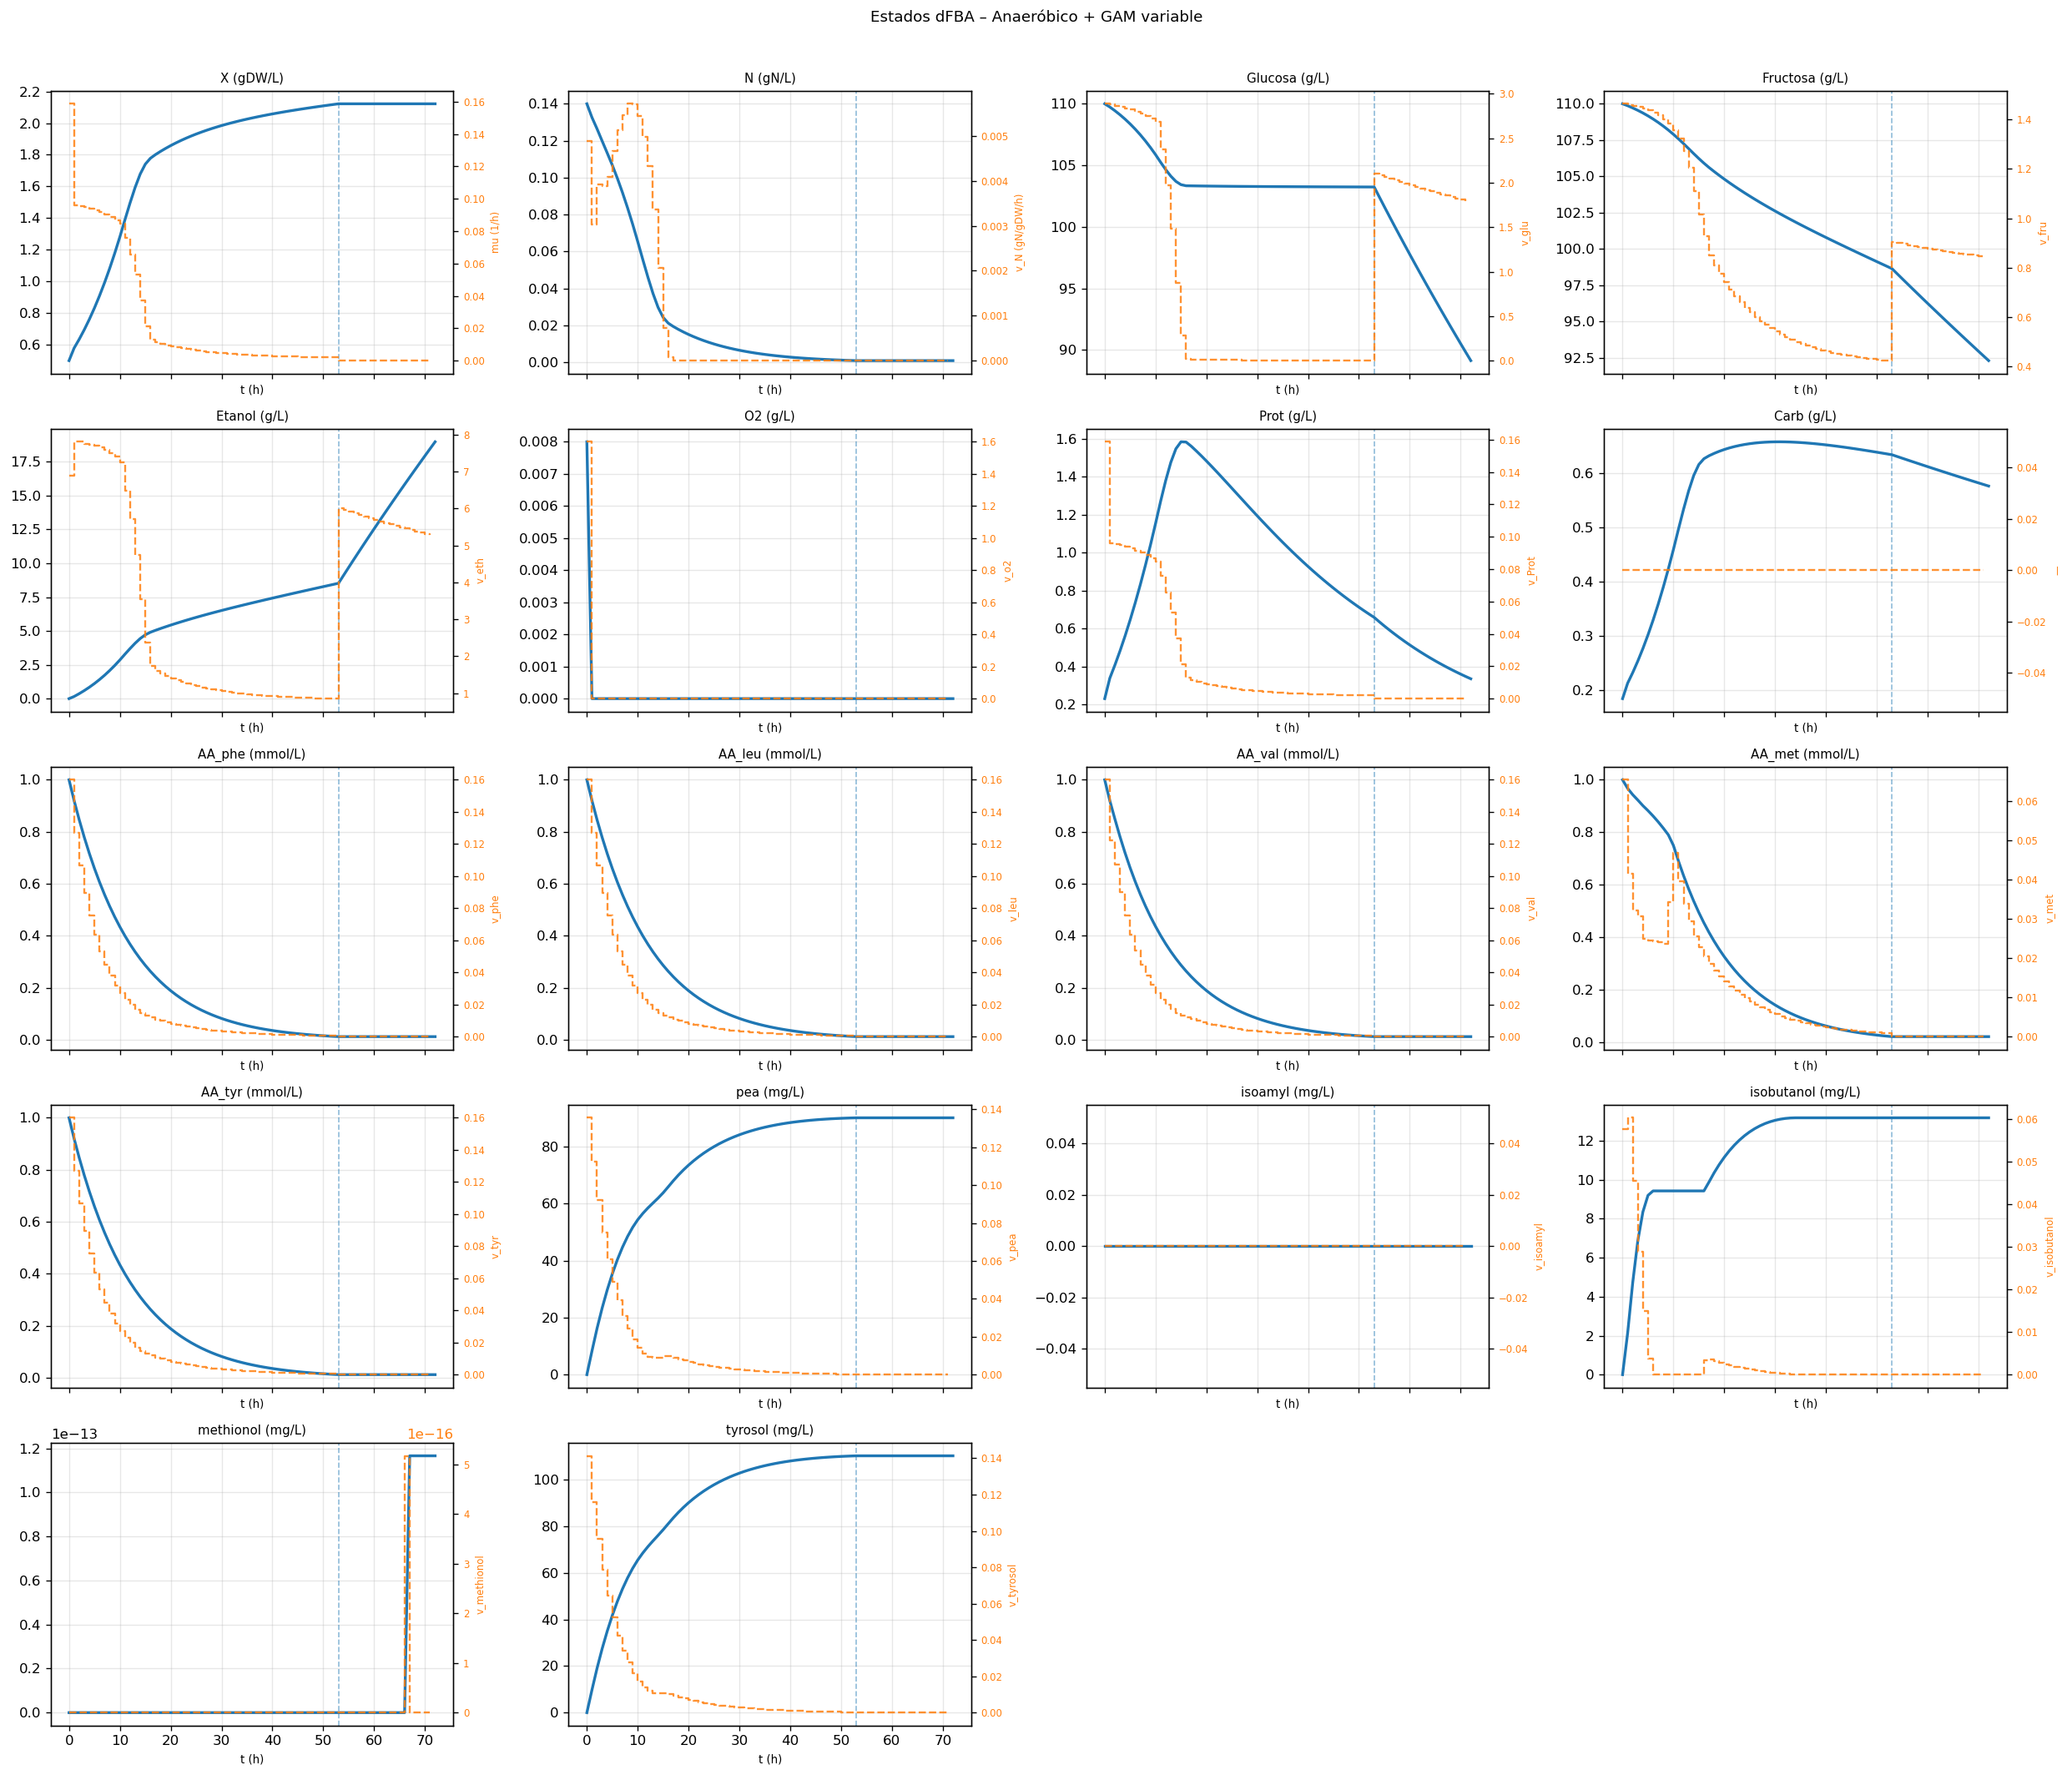

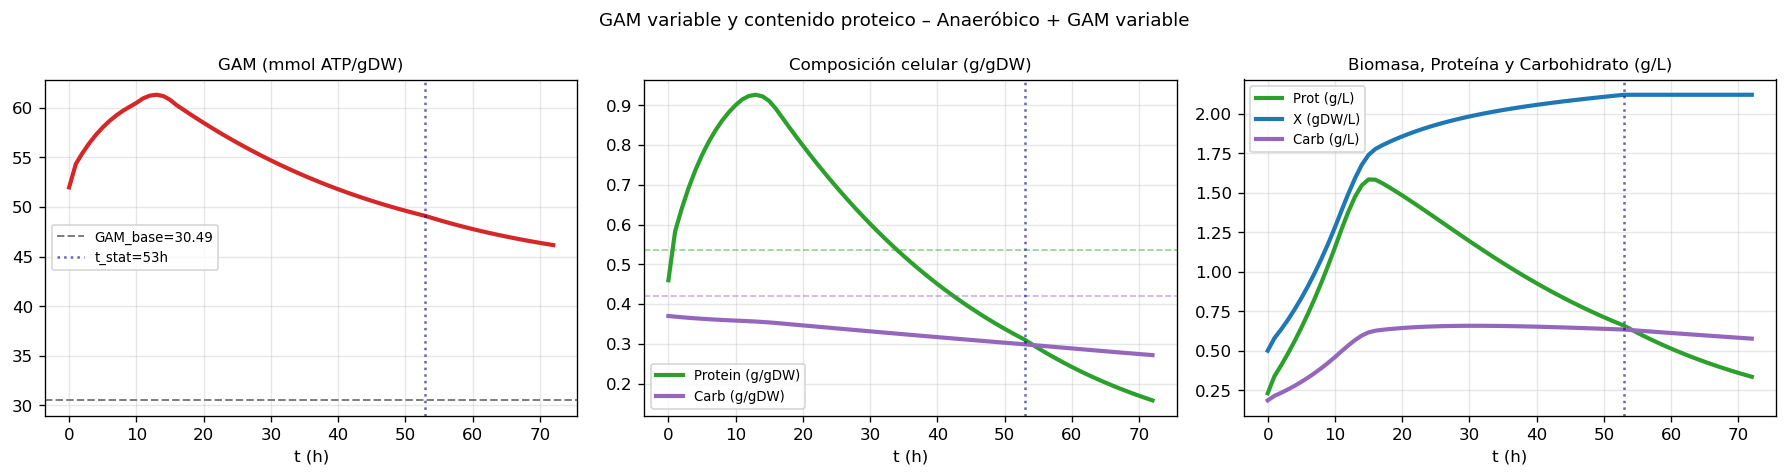

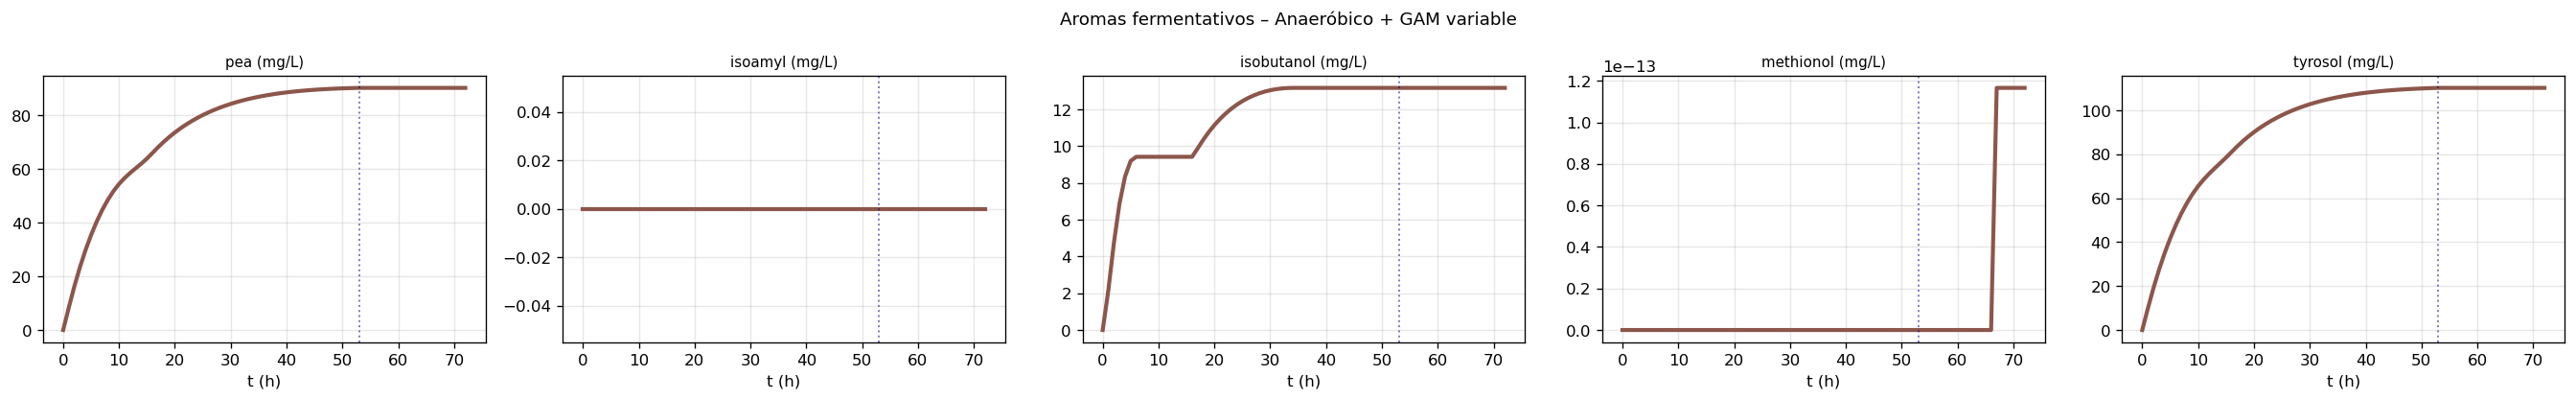

Archivo guardado: out\dfba_vargam_states_aerobic_vargam.csv


In [25]:
import math
import re
import numpy as np
import pandas as pd
import cobra

# ======================================================================================
# dFBA SOA + pFBA con variable GAM (protein-turnover) + aromas
# ======================================================================================
import matplotlib.pyplot as plt

print("\n" + "=" * 100)
print("dFBA SOA + pFBA con GAM variable + protein-turnover + aromas")
print("=" * 100)

# ── Amino acid MW table (g/mol) ────────────────────────────────────────────────
AA_MW_TABLE = {
    's_0404': 89.09,   's_0542': 121.16,  's_0432': 133.11,  's_0748': 147.13,
    's_1314': 165.19,  's_0757': 75.07,   's_0832': 155.15,  's_0847': 131.17,
    's_1099': 146.19,  's_1077': 131.17,  's_1148': 149.21,  's_0430': 132.12,
    's_1379': 115.13,  's_0747': 146.14,  's_0428': 174.20,  's_1428': 105.09,
    's_1491': 119.12,  's_1561': 117.15,  's_1527': 204.23,  's_1533': 181.19,
}
CARB_MW_TABLE = {
    's_0001': 180.16,  's_0004': 180.16,  's_0509': 221.21,
    's_0773': 180.16,  's_1107': 180.16,  's_1520': 342.296,
}
RNA_MW_TABLE = {
    's_0423': 347.2212,  's_0526': 323.1965,
    's_0782': 363.22,    's_1545': 324.1813,
}

# ── Base GAM / NGAM ────────────────────────────────────────────────────────────
GAM_BASE   = 30.49    # mmol ATP/gDW  (base value in yeast-GEM biomass reaction)
NGAM_BASE  = 0.7      # mmol ATP/gDW/h  (already set via ATPM bounds)
RNA_FRAC   = 0.06     # g RNA / gDW  (fixed)

# ── protein content: dynamic variable (g/gDW) ─────────────────────────────────
PROT_CONTENT_0 = 0.46   # initial g protein / gDW  (Nissen 1997 yeast ≈ 0.46)
CARB_CONTENT_0 = 0.37   # initial g carbohydrate / gDW
K_DEATH        = 0.005
TURNOVER_LAMBDA = 0.03
VPROT_FLOOR_FRAC = 0.90
XA_FRACTION    = 1.0
N_AMMONIA_FRACTION = 0.50
N_TOTAL_DEPLETION_THRESHOLD = 1e-3
K_AA_UPTAKE_GROWTH = 0.08
BIOMASS_LOCK_FRAC  = 0.999
AA_UPTAKE_WEIGHT   = 1.0
EPS_LOC            = float(globals().get("EPS", 1e-9))

# ── cell biomass composition constants ──────────────────────────────────────────
GAM_COEFF_P = 16.965   # mmol ATP / (gProtein/gDW)
GAM_COEFF_R = 1.638    # mmol ATP / (gRNA/gDW)
GAM_COEFF_C = 5.210    # mmol ATP / (gCarb/gDW)

# ── helper: find biomass reaction and protein pseudo-rxn ───────────────────────
def _find_biomass_rxn(mdl):
    """Return biomass reaction (r_2111 or fallback)."""
    obj_id = globals().get("OBJ_ID", "r_2111")
    if obj_id in {r.id for r in mdl.reactions}:
        return mdl.reactions.get_by_id(obj_id)
    for r in mdl.reactions:
        if "biomass" in r.name.lower():
            return r
    raise RuntimeError("No se encontró reacción de biomasa.")

def _find_protein_pseudo_rxn(mdl):
    """Return the pseudo-rxn that produces 'protein' (r_4047 or search)."""
    pid = globals().get("PROT_RXN_ID", "r_4047")
    if pid in {r.id for r in mdl.reactions}:
        return mdl.reactions.get_by_id(pid)
    for r in mdl.reactions:
        if "protein" in r.name.lower():
            return r
    return None

def _strip_compartment(met_id):
    """Remove compartment suffix: 's_0404[c]' -> 's_0404'."""
    return re.sub(r'\[.*?\]$', '', met_id)

def _calculate_content(mdl):
    """
    Calculate Ptot (g/gDW), Ctot (g/gDW), Rtot (g/gDW) from current biomass stoichiometry.
    Mirrors Sanchez's calculateContent.
    """
    prot_rxn = _find_protein_pseudo_rxn(mdl)
    if prot_rxn is None:
        return PROT_CONTENT_0, CARB_CONTENT_0, RNA_FRAC

    # Find carbohydrate and RNA pseudo-rxns by metabolite name
    carb_rxn = None
    rna_rxn  = None
    for r in mdl.reactions:
        for m in r.metabolites:
            if m.name.lower() == "carbohydrate" and r.metabolites[m] == 1:
                carb_rxn = r
            if m.name.lower() == "rna" and r.metabolites[m] == 1:
                rna_rxn = r

    Ptot, Ctot, Rtot = 0.0, 0.0, 0.0
    for rxn, table, acc_name in [
        (prot_rxn, AA_MW_TABLE,   "Ptot"),
        (carb_rxn, CARB_MW_TABLE, "Ctot"),
        (rna_rxn,  RNA_MW_TABLE,  "Rtot"),
    ]:
        if rxn is None:
            continue
        for met, coef in rxn.metabolites.items():
            key = _strip_compartment(met.id)
            if key in table and coef != 1.0 and coef < 0:
                mw = table[key]
                val = abs(float(coef)) * mw / 1000.0   # mmol/gDW * g/mmol
                if acc_name == "Ptot":
                    Ptot += val
                elif acc_name == "Ctot":
                    Ctot += val
                else:
                    Rtot += val

    Ptot = Ptot if Ptot > 1e-6 else PROT_CONTENT_0
    Ctot = Ctot if Ctot > 1e-6 else CARB_CONTENT_0
    Rtot = Rtot if Rtot > 1e-6 else RNA_FRAC
    return Ptot, Ctot, Rtot


def _compute_full_gam(P, R, C, Pbase, Rbase, Cbase):
    """
    fullGAM = GAM + 16.965*Pfactor + 1.638*Rfactor + 5.210*Cfactor
    Mirrors Sanchez's changeGAM.
    """
    Pfactor = P / max(Pbase, EPS_LOC)
    Rfactor = R / max(Rbase, EPS_LOC)
    Cfactor = (Cbase + Pbase - P - R) / max(Cbase, EPS_LOC)
    Cfactor = max(0.0, Cfactor)
    full_gam = GAM_BASE + GAM_COEFF_P * Pfactor + GAM_COEFF_R * Rfactor + GAM_COEFF_C * Cfactor
    return float(full_gam)


def _apply_variable_gam(mtmp, full_gam):
    """
    Update stoichiometry of ATP/ADP/H2O/H+/phosphate in the biomass reaction
    to reflect full_gam (mmol/gDW).
    Mirrors the bioRxn update block in changeGAM.
    """
    bio_rxn = _find_biomass_rxn(mtmp)
    targets = {"atp", "adp", "h2o", "h+", "phosphate", "water", "proton"}
    updates = {}
    for met, coef in bio_rxn.metabolites.items():
        nm = met.name.lower()
        if any(t in nm for t in targets):
            updates[met] = float(np.sign(coef)) * round(full_gam, 4) - float(coef)
    if updates:
        bio_rxn.add_metabolites(updates)


# ── Get base composition once from the original model ───────────────────────────
Pbase_global, Cbase_global, Rbase_global = _calculate_content(model)
print(f"Base composition (gDW): Prot={Pbase_global:.4f}, Carb={Cbase_global:.4f}, RNA={Rbase_global:.4f}")
gam_base_check = _compute_full_gam(Pbase_global, Rbase_global, Cbase_global,
                                    Pbase_global, Rbase_global, Cbase_global)
print(f"GAM at base composition: {gam_base_check:.4f} mmol ATP/gDW")

# ── Re-use mappings from cell 19 if available ───────────────────────────────────
_found_precursors = globals().get("found_precursors", {})
_found_aromas     = globals().get("found_aromas", {})
_PROT_RXN_ID      = globals().get("PROT_RXN_ID", "r_4047")
_AA_MW            = globals().get("AA_MW", {"phe":0.16519,"leu":0.13117,"val":0.11715,"met":0.14921,"tyr":0.18119})
_AROMA_MW         = globals().get("AROMA_MW", {"pea":0.12217,"isoamyl":0.08815,"isobutanol":0.07412,"methionol":0.10619,"tyrosol":0.13816})
_N_atoms_map      = globals().get("N_atoms_map", {rid: 1.0 for rid in KINETIC_N_SOURCE_IDS})
_N_frac_map       = globals().get("N_frac_map", {rid: 0.02 for rid in KINETIC_N_SOURCE_IDS})

if not _found_precursors:
    raise RuntimeError("'found_precursors' not found. Run cell 19 first.")

aa_keys   = list(_found_precursors.keys())
aroma_keys = list(_found_aromas.keys())

AA_ALPHA_STATIC = float(globals().get("AA_ALPHA_STATIC", 1.0 / max(1, len(aa_keys))))
AA_ALPHA        = {k: AA_ALPHA_STATIC for k in aa_keys}

# Build tracked IDs
_required_ids = list(dict.fromkeys(
    [OBJ_ID, GLU_ID, FRU_ID, ETH_ID, O2_ID, ATPM_ID, _PROT_RXN_ID]
    + list(_found_precursors.values())
    + list(_found_aromas.values())
    + list(KINETIC_N_SOURCE_IDS)
))
_required_ids = [rid for rid in _required_ids if rid in rxn_by_id]

_base_lb = {rid: float(rxn_by_id[rid].lower_bound) for rid in _required_ids}
_base_ub = {rid: float(rxn_by_id[rid].upper_bound) for rid in _required_ids}

# ── Kinetic limits (reuse existing function if available) ───────────────────────
_kinetic_limits_fn = globals().get("_kinetic_limits")
if _kinetic_limits_fn is None:
    raise RuntimeError("'_kinetic_limits' not found. Run cell 15/17/19 first.")

N_VITAMIN_EX_IDS_LOC = globals().get("N_VITAMIN_EX_IDS", [])

# ── dFBA with variable GAM ────────────────────────────────────────────────────
def _run_dfba_variable_gam(
    *,
    scenario_name="Anaeróbico + GAM variable",
    aerobic_mode=False,
    o2_init_g_l=0.0,
    dfba_dt=1.0,
    t_end=72.0,
):
    dt   = float(dfba_dt)
    tt   = np.arange(0.0, t_end + 0.5 * dt, dt)
    n_st = len(tt) - 1

    N0_total   = float(globals().get("N0", 0.14))
    N0_ammonia = N0_total * N_AMMONIA_FRACTION
    N0_from_aa = max(0.0, N0_total - N0_ammonia)
    aa0_each   = (N0_from_aa / MW_N) / max(1, len(aa_keys))

    # State vector: [X, N_free, G, F, E, O2, Prot, Carb, AA_i..., Aroma_j...]
    n_aa    = len(aa_keys)
    n_aroma = len(aroma_keys)
    n_state = 8 + n_aa + n_aroma
    Y = np.zeros((len(tt), n_state), dtype=float)
    Y[0, 0] = 0.5
    Y[0, 1] = N0_ammonia
    Y[0, 2] = 110.0
    Y[0, 3] = 110.0
    Y[0, 4] = 0.0
    Y[0, 5] = o2_init_g_l
    Y[0, 6] = Y[0, 0] * PROT_CONTENT_0    # Prot [g/L]
    Y[0, 7] = Y[0, 0] * CARB_CONTENT_0    # Carb [g/L]
    for j in range(n_aa):
        Y[0, 8 + j] = aa0_each

    # Flux histories
    mu_h         = np.zeros(n_st)
    vglu_h       = np.zeros(n_st)
    vfru_h       = np.zeros(n_st)
    veth_h       = np.zeros(n_st)
    vo2_h        = np.zeros(n_st)
    vn_h         = np.zeros(n_st)
    vatpm_h      = np.zeros(n_st)
    vprot_h      = np.zeros(n_st)
    gam_h        = np.zeros(n_st)
    p_frac_h     = np.zeros(n_st)   # g protein / gDW
    c_frac_h     = np.zeros(n_st)   # g carb / gDW
    aroma_fh     = {k: np.zeros(n_st) for k in aroma_keys}
    aa_uptake_h  = {k: np.zeros(n_st) for k in aa_keys}
    aa_turn_h    = {k: np.zeros(n_st) for k in aa_keys}
    mode_h       = []

    for k in range(n_st):
        yk = np.maximum(Y[k, :], 0.0)
        cX, cN_free, cG, cF, cE, cO2, cProt, cCarb = yk[:8]
        aa_state = {ak: float(yk[8 + j]) for j, ak in enumerate(aa_keys)}

        aa_n_sum = MW_N * sum(aa_state.values())
        cN_total = cN_free + aa_n_sum

        # Dynamic protein / carb fractions
        P_frac = cProt / max(cX, EPS_LOC)   # g/gDW
        C_frac = cCarb / max(cX, EPS_LOC)
        R_frac = RNA_FRAC

        full_gam = _compute_full_gam(P_frac, R_frac, C_frac,
                                      Pbase_global, Rbase_global, Cbase_global)
        gam_h[k]    = full_gam
        p_frac_h[k] = P_frac
        c_frac_h[k] = C_frac

        lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits_fn(
            cX, cN_free, cG, cF, cE, cO2)

        with model as mtmp:
            rb = {r.id: r for r in mtmp.reactions}

            # Reset bounds
            for rid in _required_ids:
                rb[rid].lower_bound = _base_lb[rid]
                rb[rid].upper_bound = _base_ub[rid]

            # Sugars
            if GLU_ID in rb:
                rb[GLU_ID].lower_bound = max(rb[GLU_ID].lower_bound, -lim_glu)
                rb[GLU_ID].upper_bound = min(rb[GLU_ID].upper_bound, 0.0)
            if FRU_ID in rb:
                rb[FRU_ID].lower_bound = max(rb[FRU_ID].lower_bound, -lim_fru)
                rb[FRU_ID].upper_bound = min(rb[FRU_ID].upper_bound, 0.0)

            # N kinetic
            for rid in KINETIC_N_SOURCE_IDS:
                if rid in rb:
                    Li = float(lim_n_map.get(rid, 0.0))
                    rb[rid].lower_bound = max(rb[rid].lower_bound, -Li)
                    rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)

            # Vitamins/N depletion
            if cN_total <= N_TOTAL_DEPLETION_THRESHOLD:
                for rid in N_VITAMIN_EX_IDS_LOC:
                    if rid in rb:
                        rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                        rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

            # O2
            if aerobic_mode:
                lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS_LOC))
                lim_o2 = 0.0 if cO2 <= O2_DEPLETION_THRESHOLD else max(0.0, lim_o2)
                rb[O2_ID].lower_bound = -lim_o2
                rb[O2_ID].upper_bound = 0.0
            else:
                rb[O2_ID].lower_bound = 0.0
                rb[O2_ID].upper_bound = 0.0

            # Product caps
            if APPLY_PRODUCT_CAPS:
                rb[ETH_ID].upper_bound = min(rb[ETH_ID].upper_bound, lim_eth)
                rb[OBJ_ID].upper_bound = min(rb[OBJ_ID].upper_bound, lim_obj)
            else:
                rb[ETH_ID].upper_bound = max(rb[ETH_ID].upper_bound, 1000.0)
                rb[OBJ_ID].upper_bound = max(rb[OBJ_ID].upper_bound, 1000.0)

            # Apply variable GAM to biomass stoichiometry
            _apply_variable_gam(mtmp, full_gam)

            # AA uptake caps
            turnover_caps = {}
            if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
                for ak, rid in _found_precursors.items():
                    if rid in rb:
                        q_i = K_AA_UPTAKE_GROWTH * aa_state[ak] / max(cX, EPS_LOC)
                        q_i = max(0.0, q_i)
                        rb[rid].lower_bound = -q_i
                        rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)
                        turnover_caps[ak] = q_i
            else:
                for rid in KINETIC_N_SOURCE_IDS:
                    if rid in rb:
                        rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                        rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)
                Xa = XA_FRACTION * cX
                for ak, rid in _found_precursors.items():
                    if rid in rb:
                        q_i = TURNOVER_LAMBDA * cProt * AA_ALPHA[ak] / max(Xa, EPS_LOC)
                        q_i = max(0.0, q_i)
                        rb[rid].lower_bound = -q_i
                        rb[rid].upper_bound = min(rb[rid].upper_bound, 0.0)
                        turnover_caps[ak] = q_i

            # Phase switch
            if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
                mode_h.append("BIOMASS")
                mtmp.objective = OBJ_ID
                mtmp.objective_direction = "max"
                sol_mu = mtmp.optimize()
                if getattr(sol_mu, "status", "") != "optimal":
                    mode_h[-1] = "NO_OPT"; continue
                mu_star = max(0.0, float(sol_mu.fluxes.get(OBJ_ID, 0.0)))
                rb[OBJ_ID].lower_bound = max(float(rb[OBJ_ID].lower_bound),
                                              BIOMASS_LOCK_FRAC * mu_star)

                # Secondary obj: maximise AA uptake
                uptake_obj = {mtmp.reactions.get_by_id(rid): -AA_UPTAKE_WEIGHT
                              for rid in _found_precursors.values() if rid in rb}
                mtmp.objective = uptake_obj
                mtmp.objective_direction = "max"
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
                if getattr(sol, "status", "") != "optimal":
                    mode_h[-1] = "NO_OPT"; continue
            else:
                mode_h.append("TURNOVER_ATPM")
                rb[OBJ_ID].lower_bound = 0.0
                rb[OBJ_ID].upper_bound = 0.0
                rb[ATPM_ID].lower_bound = max(float(rb[ATPM_ID].lower_bound),
                                               ATPM_LB_NO_GROWTH)
                rb[ATPM_ID].upper_bound = ATPM_UB_NO_GROWTH
                mtmp.objective = ATPM_ID
                mtmp.objective_direction = "max"
                sol = cobra.flux_analysis.pfba(mtmp, fraction_of_optimum=1.0)
                if getattr(sol, "status", "") != "optimal":
                    mode_h[-1] = "NO_OPT"; continue

            v_obj  = float(sol.fluxes.get(OBJ_ID,   0.0))
            v_glu  = float(sol.fluxes.get(GLU_ID,   0.0))
            v_fru  = float(sol.fluxes.get(FRU_ID,   0.0))
            v_eth  = float(sol.fluxes.get(ETH_ID,   0.0))
            v_o2   = float(sol.fluxes.get(O2_ID,    0.0))
            v_atpm = float(sol.fluxes.get(ATPM_ID,  0.0))
            v_prot = float(sol.fluxes.get(_PROT_RXN_ID, 0.0))

            if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
                vn_eff = 0.0
                for rid in KINETIC_N_SOURCE_IDS:
                    if rid in _base_lb:
                        vi_ = float(sol.fluxes.get(rid, 0.0))
                        vn_eff += max(0.0, -vi_) * _N_atoms_map.get(rid, 1.0) * MW_N
            else:
                vn_eff = 0.0

            for j, ak in enumerate(aa_keys):
                rid = _found_precursors[ak]
                v_aa = float(sol.fluxes.get(rid, 0.0))
                aa_uptake_h[ak][k] = max(0.0, -v_aa)
                aa_turn_h[ak][k]   = (TURNOVER_LAMBDA * cProt * AA_ALPHA[ak]
                                       if mode_h[-1] == "TURNOVER_ATPM" else 0.0)

            for ak in aroma_keys:
                rid = _found_aromas[ak]
                aroma_fh[ak][k] = max(0.0, float(sol.fluxes.get(rid, 0.0)))

        mu_h[k]    = max(0.0, v_obj)
        vglu_h[k]  = max(0.0, -v_glu)
        vfru_h[k]  = max(0.0, -v_fru)
        veth_h[k]  = max(0.0, v_eth)
        vo2_h[k]   = max(0.0, -v_o2)
        vn_h[k]    = max(0.0, vn_eff)
        vatpm_h[k] = max(0.0, v_atpm)
        vprot_h[k] = max(0.0, v_prot)

        # ODE integration (Euler)
        dX    = v_obj * cX if mode_h[-1] == "BIOMASS" else 0.0
        dN    = -vn_eff * cX if mode_h[-1] == "BIOMASS" else 0.0
        dG    = -MW_GLU * max(0.0, -v_glu) * cX
        dF    = -MW_FRU * max(0.0, -v_fru) * cX
        dE    =  MW_ETH * max(0.0,  v_eth) * cX
        dO2   = -MW_O2  * max(0.0, -v_o2)  * cX

        Xa  = XA_FRACTION * cX
        dProt = (
            max(0.0, v_obj) * cX * PROT_CONTENT_0
            - cProt * K_DEATH
            + Xa * max(0.0, v_prot)
            - TURNOVER_LAMBDA * cProt
        )
        # Carb: simple decrease proportional to biomass growth (synthesis - dilution)
        dCarb = max(0.0, v_obj) * cX * CARB_CONTENT_0 - cCarb * K_DEATH

        Y[k+1, 0] = max(0.0, cX    + dt * dX)
        Y[k+1, 1] = max(0.0, cN_free + dt * dN)
        Y[k+1, 2] = max(0.0, cG    + dt * dG)
        Y[k+1, 3] = max(0.0, cF    + dt * dF)
        Y[k+1, 4] = max(0.0, cE    + dt * dE)
        Y[k+1, 5] = max(0.0, cO2   + dt * dO2)
        Y[k+1, 6] = max(0.0, cProt + dt * dProt)
        Y[k+1, 7] = max(0.0, cCarb + dt * dCarb)

        for j, ak in enumerate(aa_keys):
            v_aa_i = float(sol.fluxes.get(_found_precursors[ak], 0.0))
            dAA = cX * v_aa_i if mode_h[-1] == "BIOMASS" else 0.0
            Y[k+1, 8+j] = max(0.0, Y[k, 8+j] + dt * dAA)

        for j, ak in enumerate(aroma_keys):
            mw = _AROMA_MW.get(ak, 0.1)
            dA = mw * aroma_fh[ak][k] * cX
            Y[k+1, 8+n_aa+j] = max(0.0, Y[k, 8+n_aa+j] + dt * dA)

    # Unpack states
    X_h    = Y[:, 0]
    Nf_h   = Y[:, 1]
    G_h    = Y[:, 2]
    F_h    = Y[:, 3]
    E_h    = Y[:, 4]
    O2_h   = Y[:, 5]
    Prot_h = Y[:, 6]
    Carb_h = Y[:, 7]
    aa_conc_h  = {ak: Y[:, 8+j]         for j, ak in enumerate(aa_keys)}
    aroma_conc_h = {ak: Y[:, 8+n_aa+j]  for j, ak in enumerate(aroma_keys)}
    aroma_mg_h   = {ak: 1000.0 * aroma_conc_h[ak] for ak in aroma_keys}

    aa_n_h = MW_N * np.sum(
        np.column_stack([aa_conc_h[ak] for ak in aa_keys]), axis=1)
    N_h    = Nf_h + aa_n_h

    # Protein/carb fraction vs X
    P_frac_h_full = Prot_h / np.maximum(X_h, EPS_LOC)
    C_frac_h_full = Carb_h / np.maximum(X_h, EPS_LOC)

    # GAM at every time point (for plot)
    gam_full = np.array([
        _compute_full_gam(float(P_frac_h_full[i]), RNA_FRAC, float(C_frac_h_full[i]),
                          Pbase_global, Rbase_global, Cbase_global)
        for i in range(len(tt))
    ])

    t_stat = float(tt[np.argmax(np.array([m == "TURNOVER_ATPM" for m in mode_h]))]) \
        if any(m == "TURNOVER_ATPM" for m in mode_h) else np.nan
    biomass_steps   = sum(m == "BIOMASS"       for m in mode_h)
    turnover_steps  = sum(m == "TURNOVER_ATPM" for m in mode_h)

    print(f"\n[{scenario_name}]")
    print(f"  Pasos BIOMASS={biomass_steps}, TURNOVER_ATPM={turnover_steps}")
    print(f"  t_stationary ≈ {t_stat:.1f} h")
    print(f"  X_final={X_h[-1]:.4f} gDW/L  |  E_final={E_h[-1]:.4f} g/L  |  Prot_final/X={P_frac_h_full[-1]:.4f}")
    print(f"  GAM_initial={gam_full[0]:.3f}  →  GAM_final={gam_full[-1]:.3f}  mmol ATP/gDW")

    # ── States DataFrame ──────────────────────────────────────────────────────
    states_df = pd.DataFrame({
        "t_h": tt, "X_gDW_L": X_h, "N_gN_L": N_h, "N_free_gN_L": Nf_h,
        "G_g_L": G_h, "F_g_L": F_h, "E_g_L": E_h, "O2_g_L": O2_h,
        "Prot_g_L": Prot_h, "Carb_g_L": Carb_h,
        "P_frac_gProt_gDW": P_frac_h_full, "C_frac_gCarb_gDW": C_frac_h_full,
        "GAM_mmol_gDW": gam_full,
    })
    for ak in aa_keys:
        states_df[f"AA_{ak}_mmol_L"] = aa_conc_h[ak]
    for ak in aroma_keys:
        states_df[f"{ak}_g_L"]  = aroma_conc_h[ak]
        states_df[f"{ak}_mg_L"] = aroma_mg_h[ak]

    # ── Flux DataFrame ────────────────────────────────────────────────────────
    flux_df = pd.DataFrame({
        "t_h": tt[:-1], "mode": mode_h,
        "mu_h_inv": mu_h, "v_glu": vglu_h, "v_fru": vfru_h,
        "v_eth": veth_h, "v_o2": vo2_h, "v_N_uptake": vn_h,
        "v_ATPM": vatpm_h, "v_Prot": vprot_h, "GAM": gam_h,
    })
    for ak in aa_keys:
        flux_df[f"v_uptake_{ak}"] = aa_uptake_h[ak]
        flux_df[f"v_turn_{ak}"]   = aa_turn_h[ak]
    for ak in aroma_keys:
        flux_df[f"v_{ak}"] = aroma_fh[ak]

    display(flux_df)

    # ═══════════════════════════════════════════════════════════════════════════
    # PLOTS
    # ═══════════════════════════════════════════════════════════════════════════

    # ── 1. Main states ────────────────────────────────────────────────────────
    state_series = [
        ("X (gDW/L)",   X_h,    mu_h,   "mu (1/h)"),
        ("N (gN/L)",    N_h,    vn_h,   "v_N (gN/gDW/h)"),
        ("Glucosa (g/L)", G_h,  vglu_h, "v_glu"),
        ("Fructosa (g/L)", F_h, vfru_h, "v_fru"),
        ("Etanol (g/L)", E_h,   veth_h, "v_eth"),
        ("O2 (g/L)",    O2_h,   vo2_h,  "v_o2"),
        ("Prot (g/L)",  Prot_h, vprot_h,"v_Prot"),
        ("Carb (g/L)",  Carb_h, np.zeros(n_st), "—"),
    ] + [
        (f"AA_{ak} (mmol/L)", aa_conc_h[ak], aa_uptake_h[ak], f"v_{ak}")
        for ak in aa_keys
    ] + [
        (f"{ak} (mg/L)", aroma_mg_h[ak], aroma_fh[ak], f"v_{ak}")
        for ak in aroma_keys
    ]

    ncols, nrows = 4, math.ceil(len(state_series) / 4)
    fig, ax = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 3.5*nrows), sharex=True, dpi=120)
    ax = np.atleast_1d(ax).ravel()
    for i, (ttl, yy_, vv_, vlbl) in enumerate(state_series):
        ax[i].plot(tt, yy_, lw=2, color="tab:blue")
        if np.isfinite(t_stat):
            ax[i].axvline(t_stat, ls="--", lw=1, color="tab:blue", alpha=0.5)
        ax[i].set_title(ttl, fontsize=9)
        ax[i].grid(alpha=0.3)
        ax[i].set_xlabel("t (h)", fontsize=8)
        ax2 = ax[i].twinx()
        ax2.step(tt[:-1], vv_, where="post", lw=1.4, ls="--", color="tab:orange", alpha=0.85)
        ax2.set_ylabel(vlbl, color="tab:orange", fontsize=7)
        ax2.tick_params(axis="y", labelcolor="tab:orange", labelsize=7)
    for j in range(i+1, len(ax)):
        ax[j].axis("off")
    plt.suptitle(f"Estados dFBA – {scenario_name}", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

    # ── 2. GAM evolution ──────────────────────────────────────────────────────
    fig_gam, ax_gam = plt.subplots(1, 3, figsize=(15, 4), dpi=120)

    ax_gam[0].plot(tt, gam_full, lw=2.5, color="tab:red")
    ax_gam[0].axhline(GAM_BASE, ls="--", lw=1.2, color="gray", label=f"GAM_base={GAM_BASE}")
    if np.isfinite(t_stat):
        ax_gam[0].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6, label=f"t_stat={t_stat:.0f}h")
    ax_gam[0].set_title("GAM (mmol ATP/gDW)", fontsize=10)
    ax_gam[0].set_xlabel("t (h)")
    ax_gam[0].legend(fontsize=8)
    ax_gam[0].grid(alpha=0.3)

    ax_gam[1].plot(tt, P_frac_h_full, lw=2.5, color="tab:green", label="Protein (g/gDW)")
    ax_gam[1].plot(tt, C_frac_h_full, lw=2.5, color="tab:purple", label="Carb (g/gDW)")
    ax_gam[1].axhline(Pbase_global, ls="--", lw=1, color="tab:green", alpha=0.5)
    ax_gam[1].axhline(Cbase_global, ls="--", lw=1, color="tab:purple", alpha=0.5)
    if np.isfinite(t_stat):
        ax_gam[1].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6)
    ax_gam[1].set_title("Composición celular (g/gDW)", fontsize=10)
    ax_gam[1].set_xlabel("t (h)")
    ax_gam[1].legend(fontsize=8)
    ax_gam[1].grid(alpha=0.3)

    ax_gam[2].plot(tt, Prot_h, lw=2.5, color="tab:green",  label="Prot (g/L)")
    ax_gam[2].plot(tt, X_h,    lw=2.5, color="tab:blue",   label="X (gDW/L)")
    ax_gam[2].plot(tt, Carb_h, lw=2.5, color="tab:purple", label="Carb (g/L)")
    if np.isfinite(t_stat):
        ax_gam[2].axvline(t_stat, ls=":", lw=1.5, color="navy", alpha=0.6)
    ax_gam[2].set_title("Biomasa, Proteína y Carbohidrato (g/L)", fontsize=10)
    ax_gam[2].set_xlabel("t (h)")
    ax_gam[2].legend(fontsize=8)
    ax_gam[2].grid(alpha=0.3)

    plt.suptitle(f"GAM variable y contenido proteico – {scenario_name}", fontsize=11)
    plt.tight_layout()
    plt.show()

    # ── 3. Aroma profiles ────────────────────────────────────────────────────
    if aroma_keys:
        ncols_a = min(len(aroma_keys), 5)
        nrows_a = math.ceil(len(aroma_keys) / ncols_a)
        fig_a, ax_a = plt.subplots(nrows_a, ncols_a,
                                    figsize=(4.5*ncols_a, 3.5*nrows_a), dpi=120, squeeze=False)
        ax_a = ax_a.ravel()
        for i, ak in enumerate(aroma_keys):
            ax_a[i].plot(tt, aroma_mg_h[ak], lw=2.5, color="tab:brown")
            ax_a[i].set_title(f"{ak} (mg/L)", fontsize=9)
            ax_a[i].set_xlabel("t (h)")
            ax_a[i].grid(alpha=0.3)
            if np.isfinite(t_stat):
                ax_a[i].axvline(t_stat, ls=":", lw=1.2, color="navy", alpha=0.5)
        for j in range(i+1, len(ax_a)):
            ax_a[j].axis("off")
        plt.suptitle(f"Aromas fermentativos – {scenario_name}", fontsize=11)
        plt.tight_layout()
        plt.show()

    # Save CSV
    sfx = "aerobic_vargam" if aerobic_mode else "anaerobic_vargam"
    out_file = OUT_DIR / f"dfba_vargam_states_{sfx}.csv"
    states_df.to_csv(out_file, index=False)
    print(f"Archivo guardado: {out_file}")

    return {
        "states_df":    states_df,
        "flux_df":      flux_df,
        "Y":            Y,
        "mode_h":       mode_h,
        "gam_full":     gam_full,
        "P_frac_full":  P_frac_h_full,
        "C_frac_full":  C_frac_h_full,
        "time_grid_vg": tt,
    }


# ── Run anaerobic scenario ─────────────────────────────────────────────────────
res_vargam_ana = _run_dfba_variable_gam(
    scenario_name="Anaeróbico + GAM variable",
    aerobic_mode=True,
    o2_init_g_l=0.008,
    dfba_dt=1.0,
    t_end=72.0,
)


Réplica dFBA + FVA de aromas en fase lag, exponencial y estacionaria
Aromas objetivo disponibles: 9/9

[Replica + FVA aromas por fases]
  Pasos BIOMASS=53, TURNOVER_ATPM=19
  t_stationary ≈ 53.0 h
  X_final=2.1218 gDW/L  |  E_final=18.9740 g/L  |  Prot_final/X=0.1577
  GAM_initial=51.980  →  GAM_final=46.163  mmol ATP/gDW


,t_h,mode,mu_h_inv,v_glu,v_fru,v_eth,v_o2,v_N_uptake,v_ATPM,v_Prot,...,v_turn_val,v_uptake_met,v_turn_met,v_uptake_tyr,v_turn_tyr,v_pea,v_isoamyl,v_isobutanol,v_methionol,v_tyrosol
0,0.0,BIOMASS,0.158718,2.887534,1.463485,6.886238,1.6,0.004881,0.700000,0.158718,...,0.000000,6.544377e-02,0.000000,1.599200e-01,0.000000,1.355080e-01,0.0,0.057641,0.0,0.141324
1,1.0,BIOMASS,0.095769,2.877459,1.459307,7.808087,0.0,0.003036,0.700000,0.095769,...,0.000000,4.141769e-02,0.000000,1.269735e-01,0.000000,1.122434e-01,0.0,0.060303,0.0,0.115753
2,2.0,BIOMASS,0.095388,2.865836,1.455102,7.807213,0.0,0.003914,0.700000,0.095388,...,0.000000,3.225270e-02,0.000000,1.066060e-01,0.000000,9.193462e-02,0.0,0.045499,0.0,0.095430
3,3.0,BIOMASS,0.094752,2.852388,1.449720,7.749999,0.0,0.003888,0.700000,0.094752,...,0.000000,3.065379e-02,0.000000,8.953680e-02,0.000000,7.496329e-02,0.0,0.028782,0.0,0.078435
4,4.0,BIOMASS,0.093869,2.837627,1.443670,7.734029,0.0,0.004094,0.700000,0.093869,...,0.000000,2.484974e-02,0.000000,7.524434e-02,0.000000,6.080651e-02,0.0,0.015010,0.0,0.064246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,67.0,TURNOVER_ATPM,0.000000,1.856595,0.854898,5.422986,0.0,0.000000,5.422986,0.000000,...,0.002400,0.000000e+00,0.002400,0.000000e+00,0.002400,0.000000e+00,0.0,0.000000,0.0,0.000000
68,68.0,TURNOVER_ATPM,0.000000,1.841680,0.852091,5.387541,0.0,0.000000,5.387541,0.000000,...,0.002316,7.141862e-18,0.002316,0.000000e+00,0.002316,2.220433e-32,0.0,0.000000,0.0,0.000000
69,69.0,TURNOVER_ATPM,0.000000,1.827059,0.849363,5.352845,0.0,0.000000,5.352845,0.000000,...,0.002235,0.000000e+00,0.002235,1.786298e-32,0.002235,0.000000e+00,0.0,0.000000,0.0,0.000000
70,70.0,TURNOVER_ATPM,0.000000,1.812724,0.846712,5.318873,0.0,0.000000,5.318873,0.000000,...,0.002156,0.000000e+00,0.002156,0.000000e+00,0.002156,0.000000e+00,0.0,0.000000,0.0,0.000000


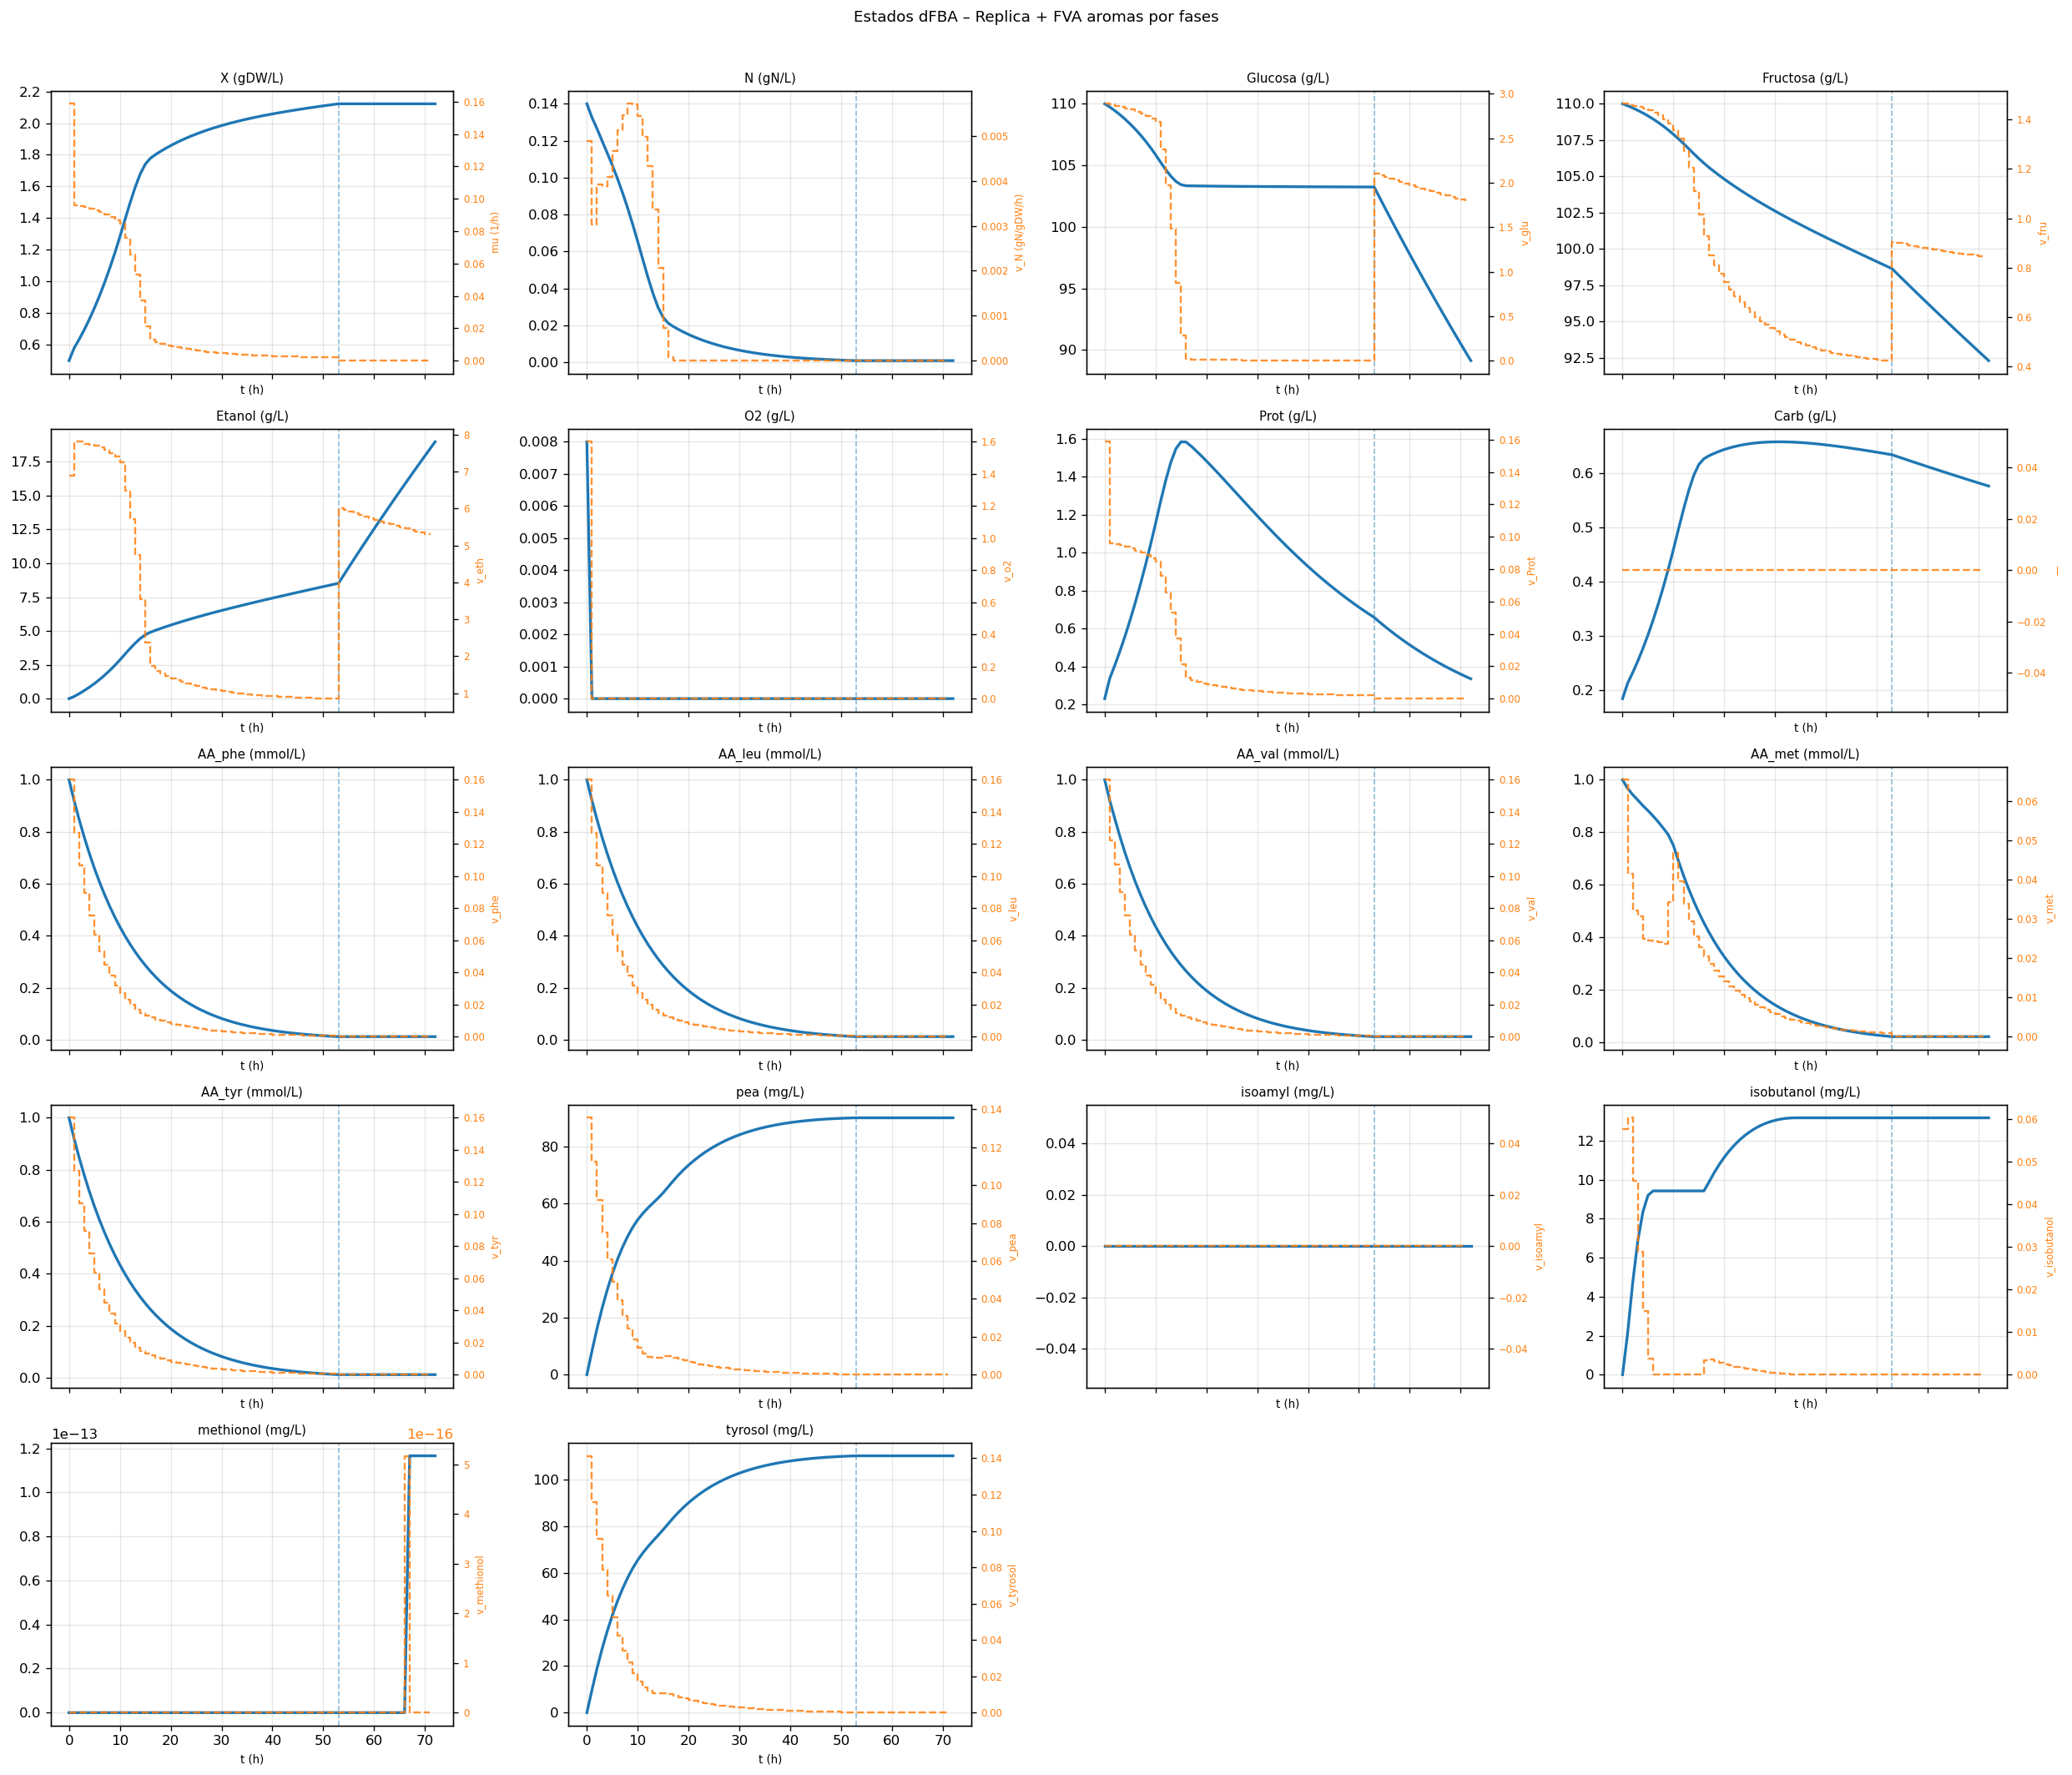

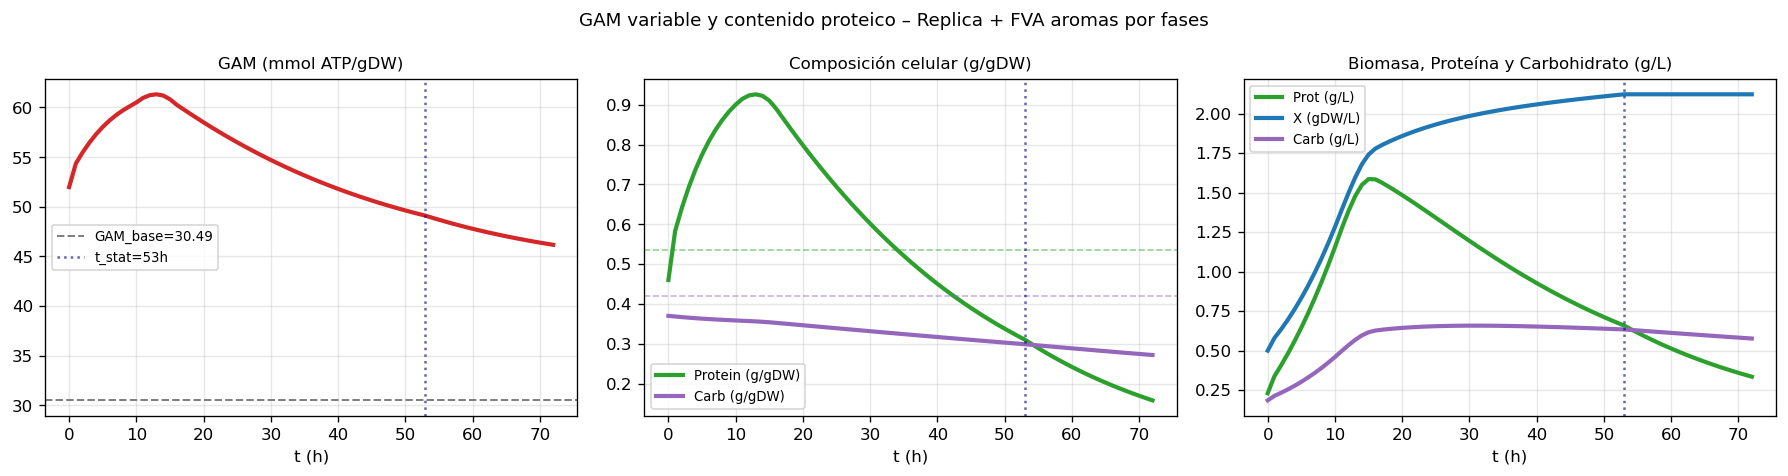

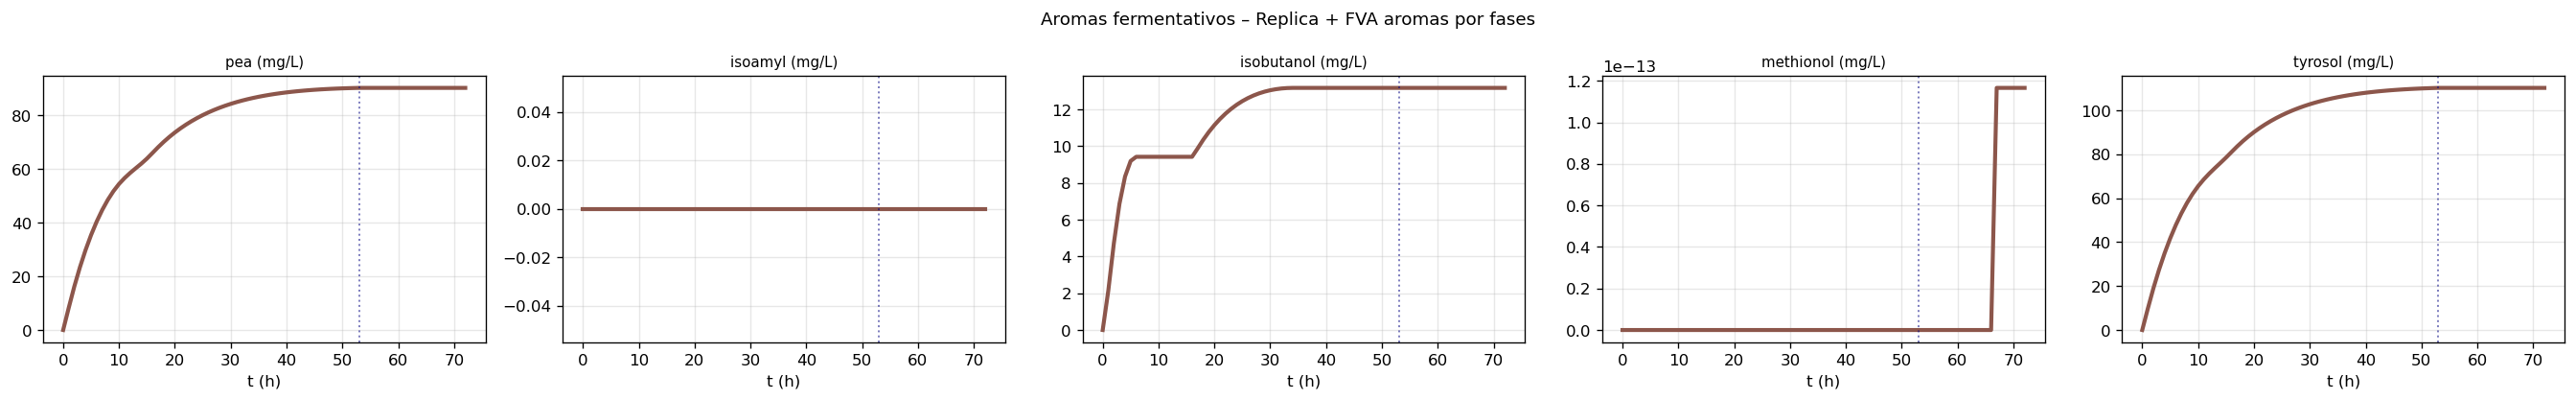

Archivo guardado: out\dfba_vargam_states_aerobic_vargam.csv

Fases seleccionadas:


,fase,t_h,mode,mu_h_inv,X_gDW_L,N_gN_L,E_g_L,O2_g_L
0,lag,0.0,BIOMASS,0.158718,0.500000,0.140000,0.000000,0.008
1,exponencial,0.0,BIOMASS,0.158718,0.500000,0.140000,0.000000,0.008
2,estacionaria,53.0,TURNOVER_ATPM,0.000000,2.121815,0.000966,8.523624,0.000



Concentración macroscópica y v de aromas objetivo:


,rid,label,final_mg_L,max_v_mmol_gDW_h
0,r_1765,ethyl acetate exchange,1.435482e-13,1.288866e-16
1,r_1867,isobutyl acetate exchange,0.000000e+00,0.000000e+00
2,r_1862,isoamyl acetate exchange,0.000000e+00,0.000000e+00
3,r_2000,phenethyl acetate exchange,0.000000e+00,0.000000e+00
4,r_1727,decanoate exchange,0.000000e+00,0.000000e+00
5,r_1984,octanoate exchange,3.314445e-01,4.629000e-03
6,r_4644,ethyl hexanoate exchange,0.000000e+00,0.000000e+00
7,r_4647,hexyl acetate exchange,0.000000e+00,0.000000e+00
8,r_4739,benzyl-acetate exchange,0.000000e+00,0.000000e+00


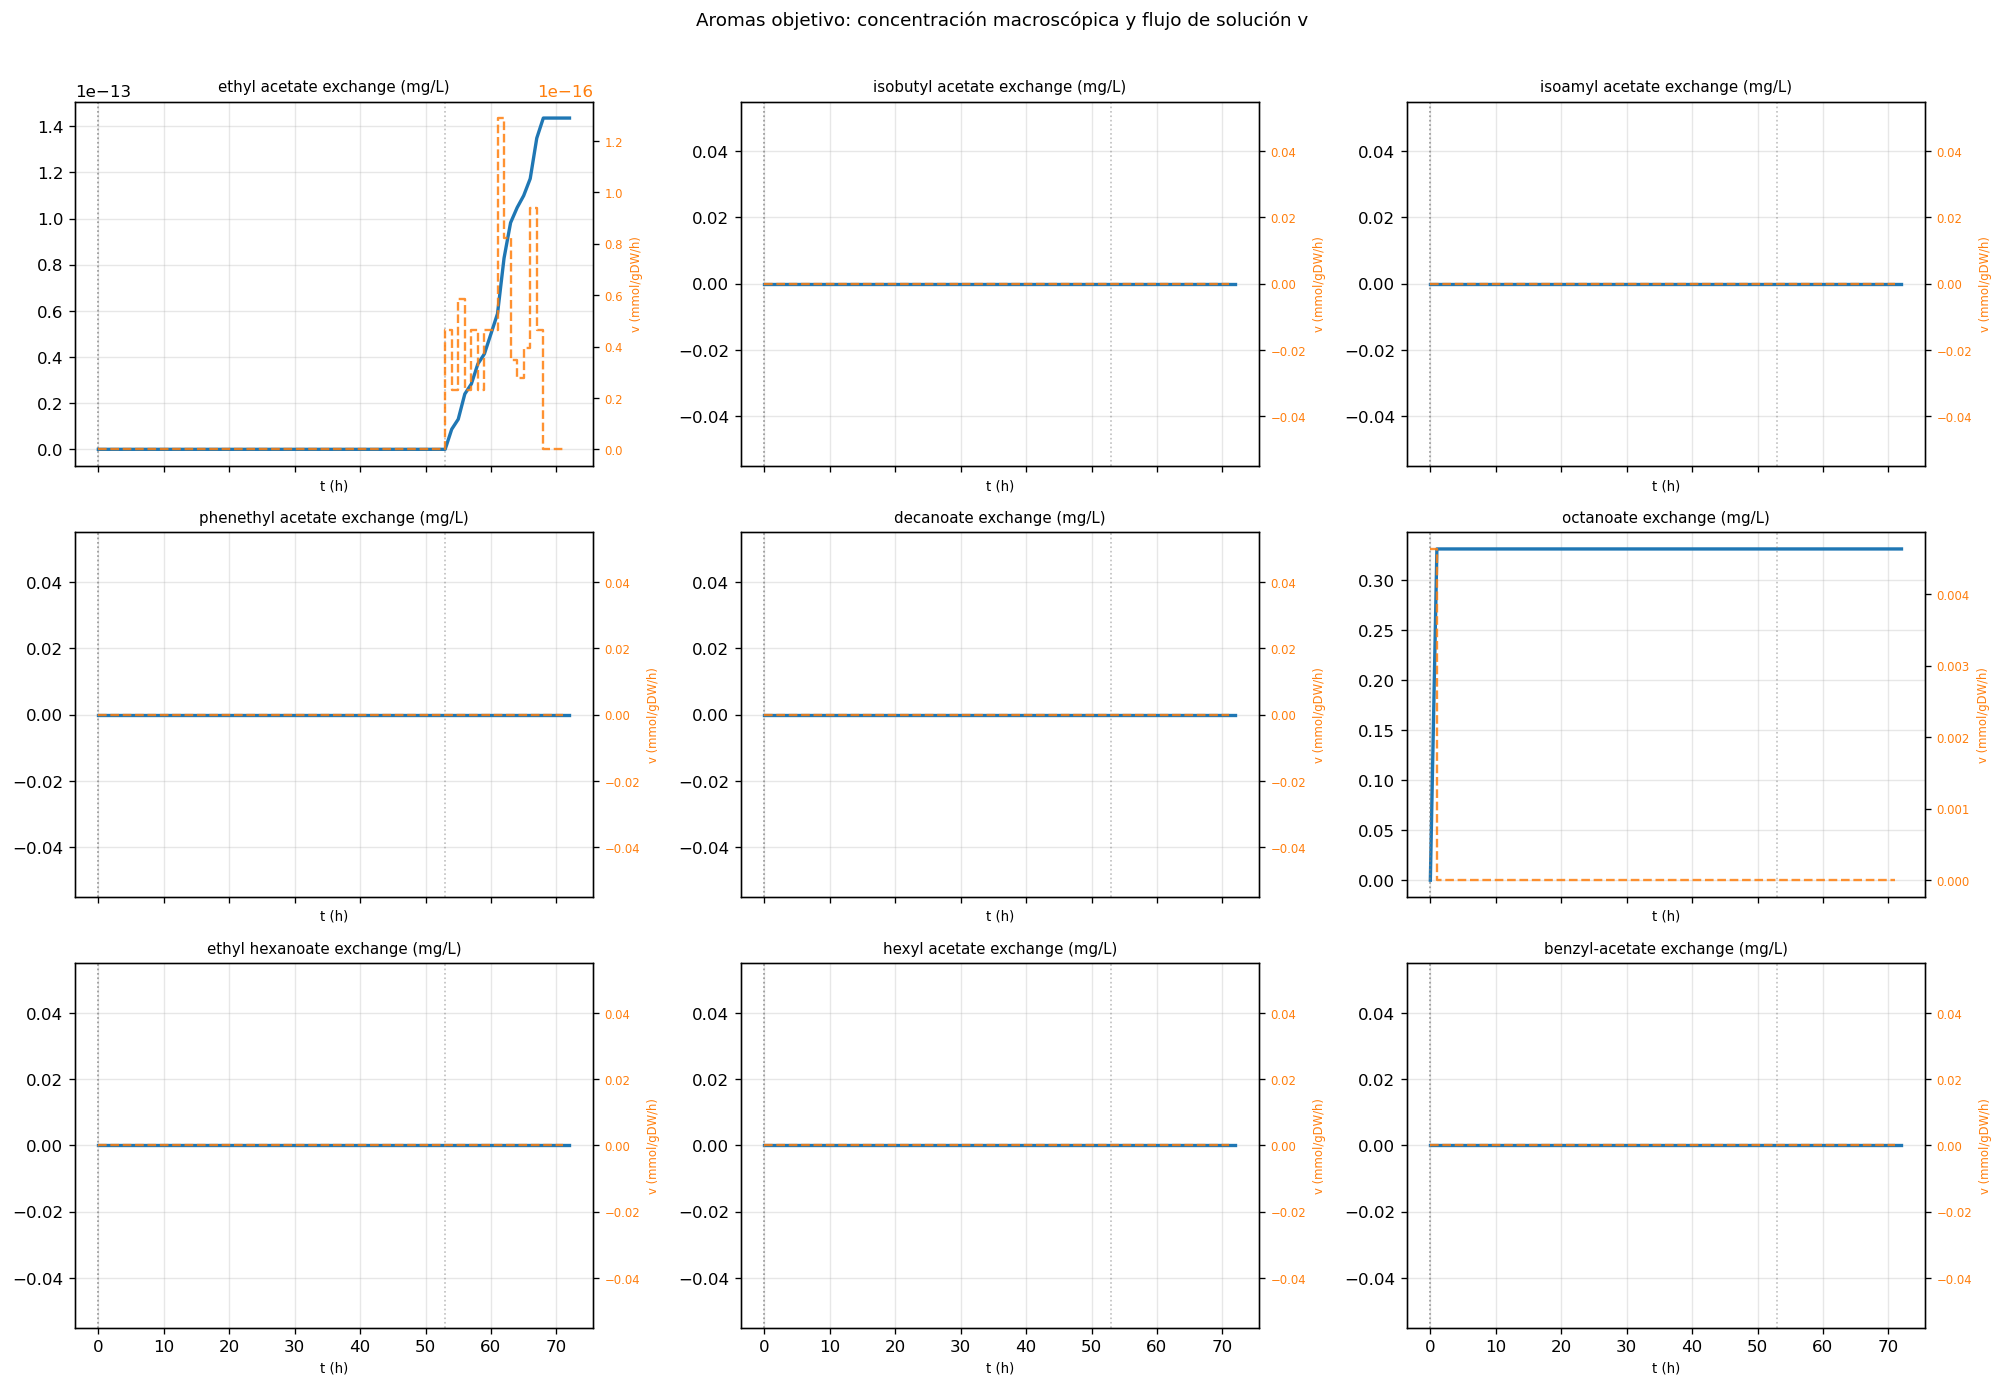


Resumen FVA de aromas por fase:


,fase,t_h,mode,objective_id,objective_value_ref,GAM_mmol_gDW,X_gDW_L,N_gN_L,E_g_L,O2_g_L,rid,label,rxn_name,flux_ref,minimum,maximum,range
0,estacionaria,53.0,TURNOVER_ATPM,r_4046,6.016511,49.100754,2.121815,0.000966,8.523624,0.000,r_1727,decanoate exchange,decanoate exchange,0.000000e+00,0.0,-1.610015e-32,-1.610015e-32
1,estacionaria,53.0,TURNOVER_ATPM,r_4046,6.016511,49.100754,2.121815,0.000966,8.523624,0.000,r_1765,ethyl acetate exchange,ethyl acetate exchange,4.653900e-17,0.0,-3.925408e-15,-3.925408e-15
2,estacionaria,53.0,TURNOVER_ATPM,r_4046,6.016511,49.100754,2.121815,0.000966,8.523624,0.000,r_1862,isoamyl acetate exchange,isoamyl acetate exchange,0.000000e+00,0.0,-1.364128e-15,-1.364128e-15
3,estacionaria,53.0,TURNOVER_ATPM,r_4046,6.016511,49.100754,2.121815,0.000966,8.523624,0.000,r_1867,isobutyl acetate exchange,isobutyl acetate exchange,0.000000e+00,0.0,9.439409e-16,9.439409e-16
4,estacionaria,53.0,TURNOVER_ATPM,r_4046,6.016511,49.100754,2.121815,0.000966,8.523624,0.000,r_1984,octanoate exchange,octanoate exchange,0.000000e+00,0.0,4.726098e-31,4.726098e-31
5,estacionaria,53.0,TURNOVER_ATPM,r_4046,6.016511,49.100754,2.121815,0.000966,8.523624,0.000,r_2000,phenethyl acetate exchange,phenethyl acetate exchange,0.000000e+00,0.0,-2.540766e-15,-2.540766e-15
6,estacionaria,53.0,TURNOVER_ATPM,r_4046,6.016511,49.100754,2.121815,0.000966,8.523624,0.000,r_4644,ethyl hexanoate exchange,ethyl hexanoate exchange,0.000000e+00,0.0,4.383387e-30,4.383387e-30
7,estacionaria,53.0,TURNOVER_ATPM,r_4046,6.016511,49.100754,2.121815,0.000966,8.523624,0.000,r_4647,hexyl acetate exchange,hexyl acetate exchange,0.000000e+00,0.0,0.000000e+00,0.000000e+00
8,estacionaria,53.0,TURNOVER_ATPM,r_4046,6.016511,49.100754,2.121815,0.000966,8.523624,0.000,r_4739,benzyl-acetate exchange,benzyl-acetate exchange,0.000000e+00,0.0,0.000000e+00,0.000000e+00
9,exponencial,0.0,BIOMASS,r_2111,0.158877,51.980262,0.500000,0.140000,0.000000,0.008,r_1727,decanoate exchange,decanoate exchange,0.000000e+00,0.0,4.629000e-03,4.629000e-03



Flujo de referencia por aroma y fase:


fase,estacionaria,exponencial,lag
label,,,
benzyl-acetate exchange,0.000000e+00,0.000000e+00,0.000000e+00
decanoate exchange,0.000000e+00,0.000000e+00,0.000000e+00
ethyl acetate exchange,4.653900e-17,0.000000e+00,0.000000e+00
ethyl hexanoate exchange,0.000000e+00,-8.067461e-17,-8.067461e-17
hexyl acetate exchange,0.000000e+00,0.000000e+00,0.000000e+00
isoamyl acetate exchange,0.000000e+00,0.000000e+00,0.000000e+00
isobutyl acetate exchange,0.000000e+00,0.000000e+00,0.000000e+00
octanoate exchange,0.000000e+00,4.629000e-03,4.629000e-03
phenethyl acetate exchange,0.000000e+00,0.000000e+00,0.000000e+00



FVA mínimo por aroma y fase:


fase,estacionaria,exponencial,lag
label,,,
benzyl-acetate exchange,0.0,0.0,0.0
decanoate exchange,0.0,0.0,0.0
ethyl acetate exchange,0.0,0.0,0.0
ethyl hexanoate exchange,0.0,0.0,0.0
hexyl acetate exchange,0.0,0.0,0.0
isoamyl acetate exchange,0.0,0.0,0.0
isobutyl acetate exchange,0.0,0.0,0.0
octanoate exchange,0.0,0.0,0.0
phenethyl acetate exchange,0.0,0.0,0.0



FVA máximo por aroma y fase:


fase,estacionaria,exponencial,lag
label,,,
benzyl-acetate exchange,0.000000e+00,0.000000e+00,0.000000e+00
decanoate exchange,-1.610015e-32,4.629000e-03,4.629000e-03
ethyl acetate exchange,-3.925408e-15,-4.690773e-14,-4.690773e-14
ethyl hexanoate exchange,4.383387e-30,6.462241e-14,-3.860641e-14
hexyl acetate exchange,0.000000e+00,0.000000e+00,0.000000e+00
isoamyl acetate exchange,-1.364128e-15,-1.876309e-14,-5.942328e-14
isobutyl acetate exchange,9.439409e-16,1.650326e-14,1.650326e-14
octanoate exchange,4.726098e-31,4.629000e-03,4.629000e-03
phenethyl acetate exchange,-2.540766e-15,-3.066123e-14,-9.406110e-15


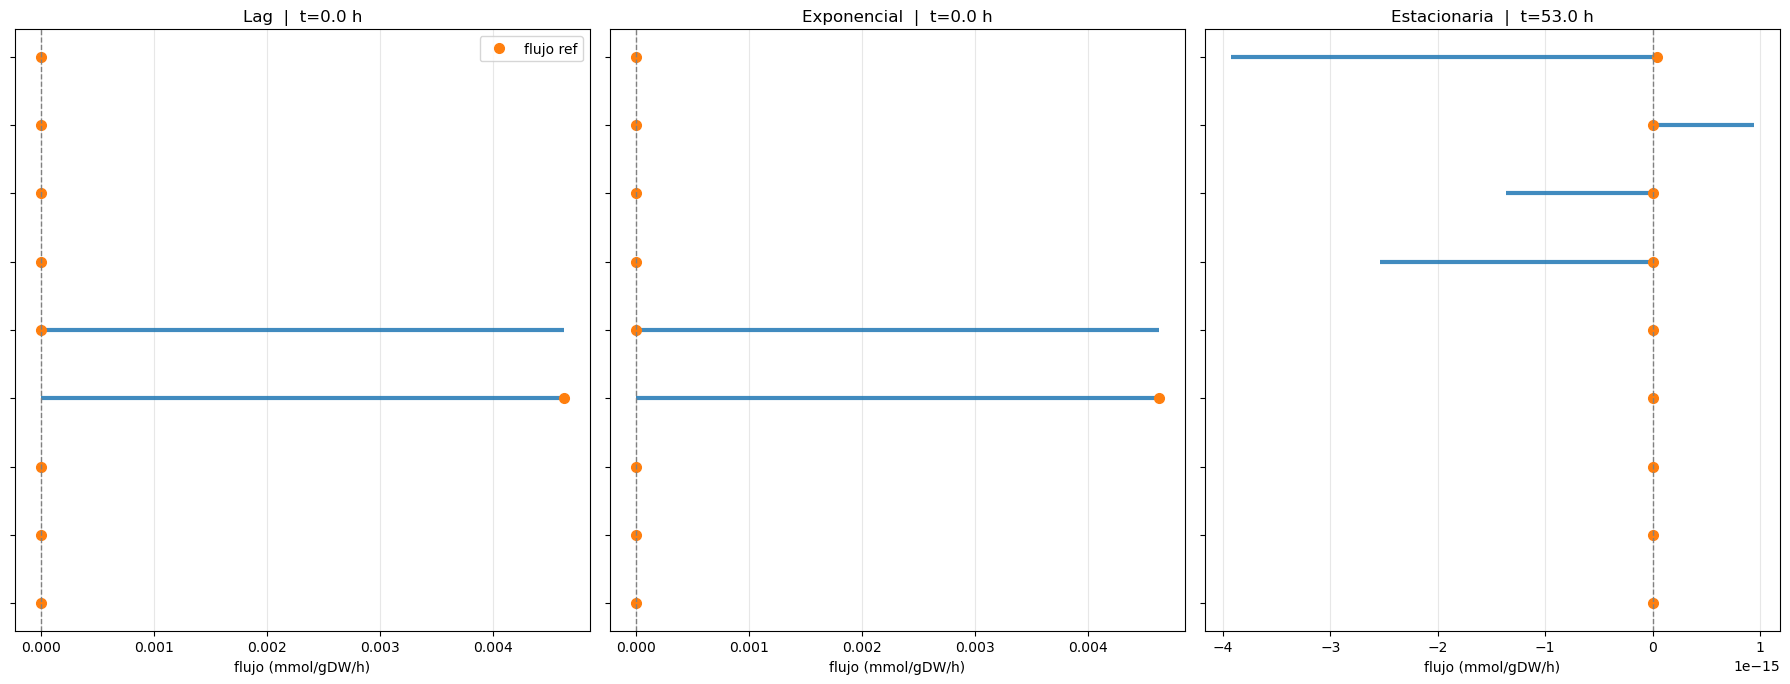

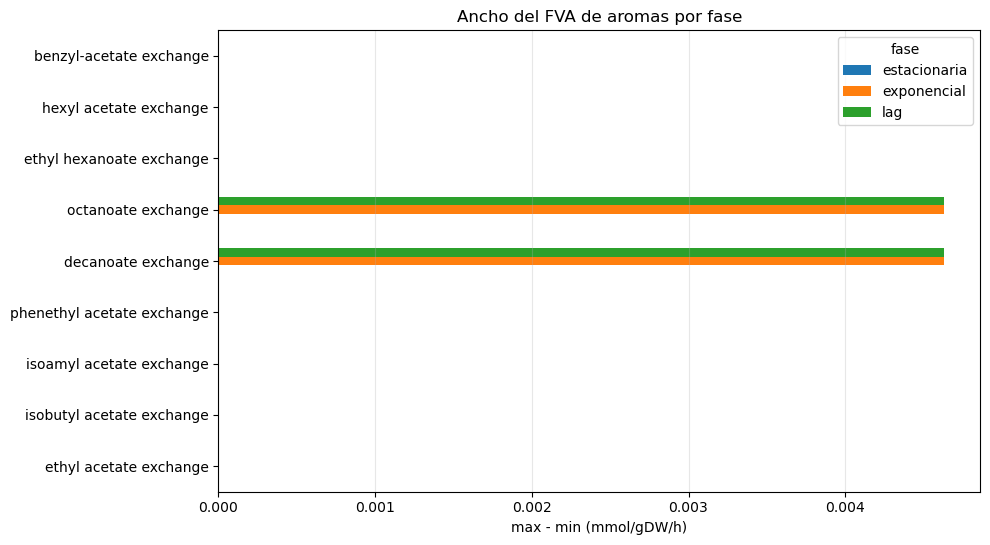


Archivos guardados:
- Estados: out\dfba_vargam_replica_states_cell23.csv
- Flujos : out\dfba_vargam_replica_flux_cell23.csv
- FVA    : out\dfba_vargam_aroma_fva_phases_cell23.csv
- Fases  : out\dfba_vargam_phase_points_cell23.csv

OK: simulación replicada y FVA de aromas calculado por fases.


In [ ]:
# Réplica de la simulación anterior + FVA de aromas relevantes en fases clave
print("\n" + "=" * 100)
print("Réplica dFBA + FVA de aromas en fase lag, exponencial y estacionaria")
print("=" * 100)

required_symbols = [
    "model",
    "_run_dfba_variable_gam",
    "_compute_full_gam",
    "_apply_variable_gam",
    "OBJ_ID", "GLU_ID", "FRU_ID", "ETH_ID", "O2_ID", "ATPM_ID",
    "KINETIC_N_SOURCE_IDS",
    "_required_ids", "_base_lb", "_base_ub",
    "_found_precursors",
    "Pbase_global", "Cbase_global", "Rbase_global",
    "RNA_FRAC",
    "O2_VMAX_UPTAKE", "O2_KO_G_L", "O2_DEPLETION_THRESHOLD",
    "APPLY_PRODUCT_CAPS",
    "K_AA_UPTAKE_GROWTH", "TURNOVER_LAMBDA", "AA_ALPHA",
    "N_TOTAL_DEPLETION_THRESHOLD", "XA_FRACTION",
    "ATPM_LB_NO_GROWTH", "ATPM_UB_NO_GROWTH",
    "EPS_LOC",
    "MW_N", "MW_GLU", "MW_FRU", "MW_ETH", "MW_O2",
    "OUT_DIR",
]
missing_symbols = [s for s in required_symbols if s not in globals()]
if missing_symbols:
    raise RuntimeError(f"Faltan símbolos requeridos en sesión: {missing_symbols}")

_kinetic_limits_fn_local = globals().get("_kinetic_limits_fn", globals().get("_kinetic_limits"))
if _kinetic_limits_fn_local is None:
    raise RuntimeError("No se encontró _kinetic_limits ni _kinetic_limits_fn en sesión.")

N_VITAMIN_EX_IDS_LOCAL = globals().get("N_VITAMIN_EX_IDS_LOC", globals().get("N_VITAMIN_EX_IDS", []))

AROMA_TARGETS = {
    "r_1765": "ethyl acetate exchange",
    "r_1867": "isobutyl acetate exchange",
    "r_1862": "isoamyl acetate exchange",
    "r_2000": "phenethyl acetate exchange",
    "r_1727": "decanoate exchange",
    "r_1984": "octanoate exchange",
    "r_4644": "ethyl hexanoate exchange",
    "r_4647": "hexyl acetate exchange",
    "r_4739": "benzyl-acetate exchange",
}

available_aroma_targets = {
    rid: label for rid, label in AROMA_TARGETS.items()
    if rid in {r.id for r in model.reactions}
}
missing_aroma_targets = [rid for rid in AROMA_TARGETS if rid not in available_aroma_targets]

print(f"Aromas objetivo disponibles: {len(available_aroma_targets)}/{len(AROMA_TARGETS)}")
if missing_aroma_targets:
    print("IDs no encontrados en el modelo:", missing_aroma_targets)

# ------------------------------------------------------------------
# 1) Réplica de la simulación anterior
#    Usa la misma configuración que la celda previa
# ------------------------------------------------------------------
res_vargam_aroma_fva = _run_dfba_variable_gam(
    scenario_name="Replica + FVA aromas por fases",
    aerobic_mode=True,
    o2_init_g_l=0.008,
    dfba_dt=1.0,
    t_end=72.0,
)

states_df_phase = res_vargam_aroma_fva["states_df"].copy()
flux_df_phase = res_vargam_aroma_fva["flux_df"].copy()

# ------------------------------------------------------------------
# 2) Selección automática de fases
# ------------------------------------------------------------------
mu_series = flux_df_phase["mu_h_inv"].to_numpy(dtype=float)
t_series = flux_df_phase["t_h"].to_numpy(dtype=float)
mu_max = float(np.nanmax(mu_series)) if len(mu_series) else 0.0

lag_idx = 0

if len(mu_series) == 0:
    raise RuntimeError("flux_df vacío; no se puede seleccionar fases.")

exp_idx = int(np.nanargmax(mu_series))

stationary_mask = flux_df_phase["mode"].astype(str).eq("TURNOVER_ATPM").to_numpy()
if stationary_mask.any():
    stat_idx = int(np.where(stationary_mask)[0][0])
    stationary_label = "estacionaria"
else:
    late_mask = (t_series >= 0.75 * float(t_series.max())) & (mu_series <= max(1e-12, 0.10 * mu_max))
    if late_mask.any():
        stat_idx = int(np.where(late_mask)[0][0])
    else:
        stat_idx = len(flux_df_phase) - 1
    stationary_label = "estacionaria_aprox"

phase_points = {
    "lag": float(t_series[lag_idx]),
    "exponencial": float(t_series[exp_idx]),
    stationary_label: float(t_series[stat_idx]),
}

phase_rows = []
for phase_name, t_phase in phase_points.items():
    row_flux = flux_df_phase.loc[flux_df_phase["t_h"] == t_phase].iloc[0]
    row_state = states_df_phase.loc[states_df_phase["t_h"] == t_phase].iloc[0]
    phase_rows.append({
        "fase": phase_name,
        "t_h": t_phase,
        "mode": row_flux["mode"],
        "mu_h_inv": row_flux["mu_h_inv"],
        "X_gDW_L": row_state["X_gDW_L"],
        "N_gN_L": row_state["N_gN_L"],
        "E_g_L": row_state["E_g_L"],
        "O2_g_L": row_state["O2_g_L"],
    })

phase_meta_df = pd.DataFrame(phase_rows)
print("\nFases seleccionadas:")
display(phase_meta_df)

# ------------------------------------------------------------------
# 2b) Reconstrucción temporal de v y concentración macroscópica
#     para aromas objetivo del bloque FVA
# ------------------------------------------------------------------
def _get_exchange_mw_g_per_mmol(mdl, rid):
    rxn = mdl.reactions.get_by_id(rid)
    mets = list(rxn.metabolites.keys())
    if len(mets) != 1:
        return np.nan
    met = mets[0]
    try:
        return float(met.formula_weight) / 1000.0
    except Exception:
        return np.nan


target_ids_resolved = list(available_aroma_targets.keys())
t_macro = states_df_phase["t_h"].to_numpy(dtype=float)
n_steps_macro = len(t_macro) - 1

flux_rows = []
aroma_macro = {rid: np.zeros(len(t_macro), dtype=float) for rid in target_ids_resolved}
aroma_meta = {
    rid: {
        "label": available_aroma_targets[rid],
        "mw_g_per_mmol": _get_exchange_mw_g_per_mmol(model, rid),
    }
    for rid in target_ids_resolved
}

for k in range(n_steps_macro):
    t_k = float(t_macro[k])
    Xk = float(states_df_phase.loc[states_df_phase["t_h"] == t_k, "X_gDW_L"].iloc[0])
    snapshot = _build_phase_snapshot_model(t_k)
    sol_k = snapshot["solution"]

    row_flux = {"t_h": t_k, "mode": snapshot["mode"], "X_gDW_L": Xk}
    dt_k = float(t_macro[k + 1] - t_macro[k])

    for rid in target_ids_resolved:
        v_k = max(0.0, float(sol_k.fluxes.get(rid, 0.0)))
        label = available_aroma_targets[rid]
        mw_g_per_mmol = aroma_meta[rid]["mw_g_per_mmol"]
        row_flux[f"v_{rid}_mmol_gDW_h"] = v_k
        row_flux[f"v_{label}"] = v_k

        dC_g_L = 0.0 if not np.isfinite(mw_g_per_mmol) else mw_g_per_mmol * v_k * Xk * dt_k
        aroma_macro[rid][k + 1] = aroma_macro[rid][k] + 1000.0 * dC_g_L

    flux_rows.append(row_flux)

flux_df_macro = pd.DataFrame(flux_rows)
aroma_macro_df = pd.DataFrame({"t_h": t_macro})
for rid in target_ids_resolved:
    label = available_aroma_targets[rid]
    aroma_macro_df[f"{label}_mg_L"] = aroma_macro[rid]

summary_rows = []
for rid in target_ids_resolved:
    label = available_aroma_targets[rid]
    summary_rows.append({
        "rid": rid,
        "label": label,
        "final_mg_L": float(aroma_macro[rid][-1]),
        "max_v_mmol_gDW_h": float(flux_df_macro[f"v_{rid}_mmol_gDW_h"].max()) if not flux_df_macro.empty else np.nan,
    })
aroma_macro_summary_df = pd.DataFrame(summary_rows)

print("\nConcentración macroscópica y v de aromas objetivo:")
display(aroma_macro_summary_df)

if target_ids_resolved:
    n_targets = len(target_ids_resolved)
    ncols = min(3, n_targets)
    nrows = math.ceil(n_targets / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 3.8 * nrows), sharex=True, dpi=120)
    axes = np.atleast_1d(axes).ravel()

    for i, rid in enumerate(target_ids_resolved):
        label = available_aroma_targets[rid]
        conc = aroma_macro_df[f"{label}_mg_L"].to_numpy(dtype=float)
        vvals = flux_df_macro[f"v_{rid}_mmol_gDW_h"].to_numpy(dtype=float)

        axes[i].plot(t_macro, conc, lw=2, color="tab:blue")
        axes[i].set_title(f"{label} (mg/L)", fontsize=9)
        axes[i].grid(alpha=0.3)
        axes[i].set_xlabel("t (h)", fontsize=8)

        for phase_name, t_phase in phase_points.items():
            axes[i].axvline(float(t_phase), ls=":", lw=1, color="gray", alpha=0.5)

        ax2 = axes[i].twinx()
        ax2.step(flux_df_macro["t_h"], vvals, where="post", lw=1.4, ls="--", color="tab:orange", alpha=0.85)
        ax2.set_ylabel("v (mmol/gDW/h)", color="tab:orange", fontsize=7)
        ax2.tick_params(axis="y", labelcolor="tab:orange", labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Aromas objetivo: concentración macroscópica y flujo de solución v", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# 3) Reconstrucción del snapshot del modelo para FVA en cada fase
# ------------------------------------------------------------------
def _build_phase_snapshot_model(t_phase):
    row = states_df_phase.loc[states_df_phase["t_h"] == float(t_phase)]
    if row.empty:
        raise RuntimeError(f"No se encontró estado para t={t_phase}")
    row = row.iloc[0]

    cX = max(0.0, float(row["X_gDW_L"]))
    cN_free = max(0.0, float(row["N_free_gN_L"])) if "N_free_gN_L" in row else max(0.0, float(row["N_gN_L"]))
    cG = max(0.0, float(row["G_g_L"]))
    cF = max(0.0, float(row["F_g_L"]))
    cE = max(0.0, float(row["E_g_L"]))
    cO2 = max(0.0, float(row["O2_g_L"]))
    cProt = max(0.0, float(row["Prot_g_L"])) if "Prot_g_L" in row else 0.0
    cCarb = max(0.0, float(row["Carb_g_L"])) if "Carb_g_L" in row else 0.0

    aa_state = {}
    for aa_key in _found_precursors:
        col = f"AA_{aa_key}_mmol_L"
        aa_state[aa_key] = max(0.0, float(row[col])) if col in row else 0.0

    aa_n_sum = MW_N * sum(aa_state.values())
    cN_total = cN_free + aa_n_sum

    P_frac = cProt / max(cX, EPS_LOC)
    C_frac = cCarb / max(cX, EPS_LOC)
    full_gam = _compute_full_gam(
        P_frac, RNA_FRAC, C_frac,
        Pbase_global, Rbase_global, Cbase_global,
    )

    lim_glu, lim_fru, lim_eth, lim_obj, lim_n_map = _kinetic_limits_fn_local(
        cX, cN_free, cG, cF, cE, cO2
    )

    mtmp = model.copy()
    rb = {r.id: r for r in mtmp.reactions}

    for rid in _required_ids:
        if rid in rb:
            rb[rid].lower_bound = float(_base_lb[rid])
            rb[rid].upper_bound = float(_base_ub[rid])

    if GLU_ID in rb:
        rb[GLU_ID].lower_bound = max(float(rb[GLU_ID].lower_bound), -float(lim_glu))
        rb[GLU_ID].upper_bound = min(float(rb[GLU_ID].upper_bound), 0.0)

    if FRU_ID in rb:
        rb[FRU_ID].lower_bound = max(float(rb[FRU_ID].lower_bound), -float(lim_fru))
        rb[FRU_ID].upper_bound = min(float(rb[FRU_ID].upper_bound), 0.0)

    for rid in KINETIC_N_SOURCE_IDS:
        if rid in rb:
            Li = float(lim_n_map.get(rid, 0.0))
            rb[rid].lower_bound = max(float(rb[rid].lower_bound), -Li)
            rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

    if cN_total <= N_TOTAL_DEPLETION_THRESHOLD:
        for rid in N_VITAMIN_EX_IDS_LOCAL:
            if rid in rb:
                rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

    if O2_ID in rb:
        lim_o2 = O2_VMAX_UPTAKE * (cO2 / (cO2 + O2_KO_G_L + EPS_LOC))
        lim_o2 = 0.0 if cO2 <= O2_DEPLETION_THRESHOLD else max(0.0, float(lim_o2))
        rb[O2_ID].lower_bound = -lim_o2
        rb[O2_ID].upper_bound = 0.0

    if APPLY_PRODUCT_CAPS:
        if ETH_ID in rb:
            rb[ETH_ID].upper_bound = min(float(rb[ETH_ID].upper_bound), float(lim_eth))
        if OBJ_ID in rb:
            rb[OBJ_ID].upper_bound = min(float(rb[OBJ_ID].upper_bound), float(lim_obj))
    else:
        if ETH_ID in rb:
            rb[ETH_ID].upper_bound = max(float(rb[ETH_ID].upper_bound), 1000.0)
        if OBJ_ID in rb:
            rb[OBJ_ID].upper_bound = max(float(rb[OBJ_ID].upper_bound), 1000.0)

    _apply_variable_gam(mtmp, full_gam)

    if cN_total > N_TOTAL_DEPLETION_THRESHOLD:
        mode = "BIOMASS"
        for aa_key, rid in _found_precursors.items():
            if rid in rb:
                q_i = K_AA_UPTAKE_GROWTH * aa_state[aa_key] / max(cX, EPS_LOC)
                q_i = max(0.0, float(q_i))
                rb[rid].lower_bound = -q_i
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        mtmp.objective = OBJ_ID
        mtmp.objective_direction = "max"
        objective_id = OBJ_ID
    else:
        mode = "TURNOVER_ATPM"
        if OBJ_ID in rb:
            rb[OBJ_ID].lower_bound = 0.0
            rb[OBJ_ID].upper_bound = 0.0

        if ATPM_ID in rb:
            rb[ATPM_ID].lower_bound = max(float(rb[ATPM_ID].lower_bound), float(ATPM_LB_NO_GROWTH))
            rb[ATPM_ID].upper_bound = float(ATPM_UB_NO_GROWTH)

        for rid in KINETIC_N_SOURCE_IDS:
            if rid in rb:
                rb[rid].lower_bound = max(float(rb[rid].lower_bound), 0.0)
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        Xa = XA_FRACTION * cX
        for aa_key, rid in _found_precursors.items():
            if rid in rb:
                q_i = TURNOVER_LAMBDA * cProt * AA_ALPHA[aa_key] / max(Xa, EPS_LOC)
                q_i = max(0.0, float(q_i))
                rb[rid].lower_bound = -q_i
                rb[rid].upper_bound = min(float(rb[rid].upper_bound), 0.0)

        mtmp.objective = ATPM_ID
        mtmp.objective_direction = "max"
        objective_id = ATPM_ID

    sol_ref_phase = mtmp.optimize()

    return {
        "model": mtmp,
        "solution": sol_ref_phase,
        "mode": mode,
        "objective_id": objective_id,
        "full_gam": full_gam,
        "state_row": row,
    }

# ------------------------------------------------------------------
# 4) FVA de aromas en snapshots de fase
# ------------------------------------------------------------------
fva_rows = []

for phase_name, t_phase in phase_points.items():
    snap = _build_phase_snapshot_model(t_phase)
    m_phase = snap["model"]
    sol_phase = snap["solution"]

    if getattr(sol_phase, "status", "") != "optimal":
        print(f"[WARN] Snapshot no óptimo en fase {phase_name} (t={t_phase} h)")
        continue

    aroma_ids_phase = [rid for rid in available_aroma_targets if rid in {r.id for r in m_phase.reactions}]
    if not aroma_ids_phase:
        continue

    fva_phase_df = cobra.flux_analysis.flux_variability_analysis(
        m_phase,
        reaction_list=aroma_ids_phase,
        fraction_of_optimum=1.00,
    )

    for rid in aroma_ids_phase:
        rxn = m_phase.reactions.get_by_id(rid)
        v_ref = float(sol_phase.fluxes.get(rid, np.nan))
        mn = float(fva_phase_df.loc[rid, "minimum"])
        mx = float(fva_phase_df.loc[rid, "maximum"])
        fva_rows.append({
            "fase": phase_name,
            "t_h": float(t_phase),
            "mode": snap["mode"],
            "objective_id": snap["objective_id"],
            "objective_value_ref": float(sol_phase.fluxes.get(snap["objective_id"], np.nan)),
            "GAM_mmol_gDW": float(snap["full_gam"]),
            "X_gDW_L": float(snap["state_row"]["X_gDW_L"]),
            "N_gN_L": float(snap["state_row"]["N_gN_L"]),
            "E_g_L": float(snap["state_row"]["E_g_L"]),
            "O2_g_L": float(snap["state_row"]["O2_g_L"]),
            "rid": rid,
            "label": available_aroma_targets[rid],
            "rxn_name": rxn.name,
            "flux_ref": v_ref,
            "minimum": mn,
            "maximum": mx,
            "range": mx - mn,
        })

aroma_fva_phase_df = pd.DataFrame(fva_rows)

if aroma_fva_phase_df.empty:
    print("[WARN] No se pudo construir la tabla de FVA de aromas.")
else:
    aroma_fva_phase_df = aroma_fva_phase_df.sort_values(
        ["fase", "rid"], kind="stable"
    ).reset_index(drop=True)

    print("\nResumen FVA de aromas por fase:")
    display(aroma_fva_phase_df)

    summary_flux = aroma_fva_phase_df.pivot(index="label", columns="fase", values="flux_ref")
    summary_min = aroma_fva_phase_df.pivot(index="label", columns="fase", values="minimum")
    summary_max = aroma_fva_phase_df.pivot(index="label", columns="fase", values="maximum")

    print("\nFlujo de referencia por aroma y fase:")
    display(summary_flux)

    print("\nFVA mínimo por aroma y fase:")
    display(summary_min)

    print("\nFVA máximo por aroma y fase:")
    display(summary_max)

    # --------------------------------------------------------------
    # 5) Gráfico FVA por fase: intervalo [min, max] + punto flujo ref
    # --------------------------------------------------------------
    phase_order = list(phase_points.keys())
    aroma_order = [available_aroma_targets[rid] for rid in AROMA_TARGETS if rid in available_aroma_targets]

    fig, axes = plt.subplots(
        1, len(phase_order),
        figsize=(6.0 * len(phase_order), max(4.5, 0.55 * len(aroma_order) + 2.0)),
        sharey=True,
    )

    if len(phase_order) == 1:
        axes = [axes]

    for ax, phase_name in zip(axes, phase_order):
        sub = aroma_fva_phase_df[aroma_fva_phase_df["fase"] == phase_name].copy()
        sub["label"] = pd.Categorical(sub["label"], categories=aroma_order, ordered=True)
        sub = sub.sort_values("label").reset_index(drop=True)

        y = np.arange(len(sub))
        ax.hlines(y, sub["minimum"], sub["maximum"], color="tab:blue", lw=3, alpha=0.85)
        ax.plot(sub["flux_ref"], y, "o", color="tab:orange", ms=7, label="flujo ref")
        ax.axvline(0.0, color="gray", ls="--", lw=1)

        ax.set_title(f"{phase_name.capitalize()}  |  t={sub['t_h'].iloc[0]:.1f} h")
        ax.set_xlabel("flujo (mmol/gDW/h)")
        ax.grid(alpha=0.3, axis="x")

        if ax is axes[0]:
            ax.set_yticks(y)
            ax.set_yticklabels(sub["label"])
        else:
            ax.set_yticks(y)
            ax.set_yticklabels([])

    axes[0].invert_yaxis()
    axes[0].legend(loc="best")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------
    # 6) Gráfico adicional: ancho del FVA por aroma y fase
    # --------------------------------------------------------------
    width_df = aroma_fva_phase_df.pivot(index="label", columns="fase", values="range").reindex(aroma_order)

    fig, ax = plt.subplots(figsize=(10, max(4.5, 0.45 * len(width_df) + 1.5)))
    width_df.plot(kind="barh", ax=ax)
    ax.set_title("Ancho del FVA de aromas por fase")
    ax.set_xlabel("max - min (mmol/gDW/h)")
    ax.set_ylabel("")
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------
    # 7) Guardado
    # --------------------------------------------------------------
    states_file = OUT_DIR / "dfba_vargam_replica_states_cell23.csv"
    flux_file = OUT_DIR / "dfba_vargam_replica_flux_cell23.csv"
    fva_file = OUT_DIR / "dfba_vargam_aroma_fva_phases_cell23.csv"
    phase_file = OUT_DIR / "dfba_vargam_phase_points_cell23.csv"

    states_df_phase.to_csv(states_file, index=False)
    flux_df_phase.to_csv(flux_file, index=False)
    aroma_fva_phase_df.to_csv(fva_file, index=False)
    phase_meta_df.to_csv(phase_file, index=False)

    print("\nArchivos guardados:")
    print(f"- Estados: {states_file}")
    print(f"- Flujos : {flux_file}")
    print(f"- FVA    : {fva_file}")
    print(f"- Fases  : {phase_file}")

print("\nOK: simulación replicada y FVA de aromas calculado por fases.")

In [21]:
# Normalizar tipos de bounds para exportacion SBML segura
for r in model.reactions:
    r.lower_bound = float(r.lower_bound)
    r.upper_bound = float(r.upper_bound)

cobra.io.write_sbml_model(model, str(MODEL_READY_SBML))

S = create_stoichiometric_matrix(model, array_type="dense")
lb = np.array([r.lower_bound for r in model.reactions], dtype=float)
ub = np.array([r.upper_bound for r in model.reactions], dtype=float)
rxn_ids = [r.id for r in model.reactions]
met_ids = [m.id for m in model.metabolites]

np.savetxt(S_FILE, S, delimiter=",")
np.savetxt(LB_FILE, lb, delimiter=",")
np.savetxt(UB_FILE, ub, delimiter=",")
newline = chr(10)
RXN_FILE.write_text(newline.join(rxn_ids), encoding="utf-8")
MET_FILE.write_text(newline.join(met_ids), encoding="utf-8")

print("Export completado")
print(f"- model_ready: {MODEL_READY_SBML}")
print(f"- S shape: {S.shape}")
print(f"- lb shape: {lb.shape}")
print(f"- ub shape: {ub.shape}")
print(f"- rxn ids: {len(rxn_ids)}")
print(f"- met ids: {len(met_ids)}")


Export completado
- model_ready: out\model_ready.xml
- S shape: (2806, 4131)
- lb shape: (4131,)
- ub shape: (4131,)
- rxn ids: 4131
- met ids: 2806


In [22]:
S_chk = np.loadtxt(S_FILE, delimiter=",")
lb_chk = np.loadtxt(LB_FILE, delimiter=",")
ub_chk = np.loadtxt(UB_FILE, delimiter=",")

assert S_chk.shape == (len(met_ids), len(rxn_ids))
assert lb_chk.shape[0] == len(rxn_ids)
assert ub_chk.shape[0] == len(rxn_ids)

print("Validacion final OK")
print(f"- S.csv : {S_FILE.resolve()}")
print(f"- lb.csv: {LB_FILE.resolve()}")
print(f"- ub.csv: {UB_FILE.resolve()}")


Validacion final OK
- S.csv : C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out\S.csv
- lb.csv: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out\lb.csv
- ub.csv: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\DC_dFBA_Zenteno\out\ub.csv
